<a href="https://colab.research.google.com/github/D2718281828nis/ML-overlay-problem/blob/main/case_study-unsupervised-overlay-problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fuzzy C-Means in Google Colab (no installation required)

The `fuzzy-c-means` package can make Colab spend a long time at **Installing build dependencies** because pip may try to build or downgrade transitive dependencies for the current Colab Python image. The old install output in this notebook also showed that it downgraded NumPy and conflicted with preinstalled packages. That is a dependency-resolution step, not Fuzzy C-Means training, and it does not confirm that the notebook is safe to continue.

To keep the Colab runtime stable, the Fuzzy C-Means section below uses a small NumPy implementation of the same standard algorithm and API pattern (`fit`, `predict`, and soft membership values) used by [`omadson/fuzzy-c-means`](https://github.com/omadson/fuzzy-c-means). **Do not run `pip install fuzzy-c-means` for this notebook.** NumPy is already included in Colab, so the section starts immediately and does not require a runtime restart.


In [ ]:
# %% [markdown]
# # Red and Green Points Clustering Analysis
#
# In this notebook, we'll analyze a dataset of red and green points using various unsupervised learning techniques:
# - DBSCAN
# - Agglomerative Clustering
# - Fuzzy C-Means (as a substitute for Fuzzy kNN, which is typically supervised)
# - t-SNE for visualization with DBSCAN clustering
#
# We'll evaluate and compare these methods using F1 score and confusion matrices.

# %% [code]
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Check if running in Google Colab
try:
    from google.colab import files
    print("Running in Google Colab")
    # In Colab, uncomment the line below to upload your file
    # uploaded = files.upload()
except:
    print("Not running in Google Colab")

# %% [code]
# Load the data
df = pd.read_csv('df_red_green_overlay.csv')

# %% [code]
# Preprocess the data
# Convert color to binary labels: 0 for light_green, 1 for red
df['label'] = df['Color'].apply(lambda x: 0 if x == 'light_green' else 1)

# Extract features (X, Y coordinates)
X = df[['X', 'Y']].values
y_true = df['label'].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset shape: {X.shape}")
print(f"Number of green points: {np.sum(y_true == 0)}")
print(f"Number of red points: {np.sum(y_true == 1)}")

# %% [code]
# Function to evaluate clustering results
def evaluate_clustering(y_true, y_pred, title):
    """Evaluate clustering results by mapping cluster labels to true labels and computing F1 score."""
    # Since clustering doesn't guarantee which cluster corresponds to which class,
    # we need to map the cluster labels to the true labels
    # We'll try both possible mappings and choose the one with better F1 score

    # Option 1: cluster 0 -> class 0, cluster 1 -> class 1
    y_pred_mapped1 = y_pred.copy()

    # Option 2: cluster 0 -> class 1, cluster 1 -> class 0
    y_pred_mapped2 = 1 - y_pred

    # Calculate F1 scores for both mappings
    f1_1 = f1_score(y_true, y_pred_mapped1, zero_division=0)
    f1_2 = f1_score(y_true, y_pred_mapped2, zero_division=0)

    # Choose the mapping with higher F1 score
    if f1_1 >= f1_2:
        y_pred_final = y_pred_mapped1
        f1 = f1_1
    else:
        y_pred_final = y_pred_mapped2
        f1 = f1_2

    print(f"\n{title} - F1 Score: {f1:.4f}")

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred_final)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["light_green", "red"])
    disp.plot()
    plt.title(f"{title} Confusion Matrix")
    plt.show()

    return f1, y_pred_final

# %% [code]
# 1. DBSCAN
print("\n===== Running DBSCAN =====")
# Use k-distance graph to help determine eps parameter
k = 5  # commonly used value for DBSCAN
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
distances = np.sort(distances, axis=0)
distances = distances[:, k-1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-distance')
plt.title(f'DBSCAN: {k}-Distance Graph (for determining eps)')
plt.grid(True)
plt.show()

# Try different parameter combinations
eps_values = np.linspace(0.05, 0.3, 6)
min_samples_values = [3, 5, 7]

best_f1 = 0
best_params = None
best_labels = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # Check if we have valid clusters for binary classification
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2:
            continue  # Need at least two clusters

        # Map DBSCAN labels to 0 and 1 (ignoring noise points if necessary)
        if -1 in unique_labels:
            # Create a mask for non-noise points
            mask = labels != -1
            if np.sum(mask) < len(y_true)/10:  # If too many points are noise, skip
                continue

            # Map the clusters to 0 and 1 based on the majority class in each cluster
            mapped_labels = np.zeros_like(labels)

            # For each cluster (ignoring noise)
            for cluster_id in unique_labels:
                if cluster_id == -1:
                    continue

                cluster_mask = labels == cluster_id
                # Determine the majority class in this cluster
                majority_class = np.bincount(y_true[cluster_mask]).argmax()
                mapped_labels[cluster_mask] = majority_class
        else:
            # Direct mapping if no noise points
            # Map cluster 0 to the class that appears most in that cluster
            cluster_0_mask = labels == 0
            cluster_1_mask = labels == 1

            majority_class_0 = np.bincount(y_true[cluster_0_mask]).argmax()
            majority_class_1 = np.bincount(y_true[cluster_1_mask]).argmax()

            # If both clusters map to the same class, skip
            if majority_class_0 == majority_class_1:
                continue

            mapped_labels = np.zeros_like(labels)
            mapped_labels[cluster_0_mask] = majority_class_0
            mapped_labels[cluster_1_mask] = majority_class_1

        # Evaluate
        f1 = max(f1_score(y_true, mapped_labels, zero_division=0),
                 f1_score(y_true, 1 - mapped_labels, zero_division=0))

        if f1 > best_f1:
            best_f1 = f1
            best_params = (eps, min_samples)
            best_labels = mapped_labels.copy()

if best_params is None:
    # Fallback if no good parameters were found
    dbscan = DBSCAN(eps=0.15, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    # Simple mapping: assume two clusters exist
    unique_labels = np.unique(labels)
    if -1 in unique_labels:
        mask = labels != -1
        cluster_labels = np.unique(labels[mask])
        best_labels = np.zeros_like(labels)
        # Map based on majority class
        for i, cluster_id in enumerate(cluster_labels):
            cluster_mask = (labels == cluster_id)
            majority_class = np.bincount(y_true[cluster_mask]).argmax()
            best_labels[cluster_mask] = majority_class
        # Handle noise points by assigning to majority class
        majority_class = np.bincount(y_true).argmax()
        best_labels[labels == -1] = majority_class
    else:
        cluster_labels = np.unique(labels)
        best_labels = np.zeros_like(labels)
        # Map based on majority class
        for i, cluster_id in enumerate(cluster_labels):
            cluster_mask = (labels == cluster_id)
            majority_class = np.bincount(y_true[cluster_mask]).argmax()
            best_labels[cluster_mask] = majority_class
    best_params = (0.15, 5)

print(f"Best DBSCAN parameters: eps={best_params[0]:.2f}, min_samples={best_params[1]}")

# Evaluate DBSCAN
dbscan_f1, dbscan_pred = evaluate_clustering(y_true, best_labels, "DBSCAN")

# %% [code]
# 2. Agglomerative Clustering
print("\n===== Running Agglomerative Clustering =====")
# For Agglomerative Clustering, we need to specify the number of clusters
# Since we have two classes, we'll use n_clusters=2

agg_clustering = AgglomerativeClustering(n_clusters=2)
agg_labels = agg_clustering.fit_predict(X_scaled)

# Evaluate
agg_f1, agg_pred = evaluate_clustering(y_true, agg_labels, "Agglomerative Clustering")

# %% [code]
# 3. Fuzzy C-Means (dependency-free Colab implementation)
print("\n===== Running Fuzzy C-Means =====")

class FuzzyCMeans:
    """Minimal NumPy FCM with an interface similar to omadson/fuzzy-c-means.

    Memberships are updated until the largest change is below ``error``.
    ``m`` controls fuzziness and must be greater than 1 (the usual value is 2).
    """

    def __init__(self, n_clusters=2, m=2.0, max_iter=300, error=1e-5, random_state=None):
        if n_clusters < 2:
            raise ValueError("n_clusters must be at least 2")
        if m <= 1:
            raise ValueError("m must be greater than 1")
        self.n_clusters = n_clusters
        self.m = float(m)
        self.max_iter = max_iter
        self.error = error
        self.random_state = random_state

    @staticmethod
    def _as_2d_float_array(X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or len(X) == 0:
            raise ValueError("X must be a non-empty 2D array")
        if not np.isfinite(X).all():
            raise ValueError("X contains NaN or infinite values")
        return X

    def _membership_from_distances(self, distances):
        # u_ij = 1 / sum_k((d_ij / d_ik) ** (2 / (m - 1))).
        # The equivalent inverse-distance form is faster and handles zero safely.
        zero_distance = distances <= np.finfo(float).eps
        membership = np.zeros_like(distances)
        rows_with_zero = zero_distance.any(axis=1)
        if np.any(rows_with_zero):
            zeros = zero_distance[rows_with_zero]
            membership[rows_with_zero] = zeros / zeros.sum(axis=1, keepdims=True)
        if np.any(~rows_with_zero):
            exponent = 2.0 / (self.m - 1.0)
            inverse = distances[~rows_with_zero] ** (-exponent)
            membership[~rows_with_zero] = inverse / inverse.sum(axis=1, keepdims=True)
        return membership

    def fit(self, X):
        X = self._as_2d_float_array(X)
        if len(X) < self.n_clusters:
            raise ValueError("n_samples must be at least n_clusters")

        rng = np.random.default_rng(self.random_state)
        membership = rng.dirichlet(np.ones(self.n_clusters), size=len(X))
        self.objective_history_ = []

        for iteration in range(1, self.max_iter + 1):
            weights = membership ** self.m
            centers = (weights.T @ X) / weights.sum(axis=0)[:, None]
            distances = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
            updated = self._membership_from_distances(distances)
            self.objective_history_.append(float(np.sum((updated ** self.m) * distances ** 2)))

            max_change = float(np.max(np.abs(updated - membership)))
            membership = updated
            if max_change < self.error:
                break

        self.centers_ = centers
        self.u_ = membership
        self.n_iter_ = iteration
        self.max_membership_change_ = max_change
        return self

    def soft_predict(self, X):
        X = self._as_2d_float_array(X)
        distances = np.linalg.norm(X[:, None, :] - self.centers_[None, :, :], axis=2)
        return self._membership_from_distances(distances)

    def predict(self, X):
        return self.soft_predict(X).argmax(axis=1)


fcm = FuzzyCMeans(
    n_clusters=2,
    m=2.0,
    max_iter=300,
    error=1e-5,
    random_state=42,
).fit(X_scaled)

fcm_membership = fcm.soft_predict(X_scaled)
fcm_labels = fcm_membership.argmax(axis=1)
fcm_f1, fcm_pred = evaluate_clustering(y_true, fcm_labels, "Fuzzy C-Means")

# Align the soft-membership column with the evaluated red label (class 1).
red_cluster = 1 if np.array_equal(fcm_pred, fcm_labels) else 0
fcm_red_membership = fcm_membership[:, red_cluster]
fcm_confidence = fcm_membership.max(axis=1)
fcm_entropy = -(fcm_membership * np.log(fcm_membership + np.finfo(float).eps)).sum(axis=1) / np.log(2)

print(f"Converged in {fcm.n_iter_} iterations")
print(f"Final maximum membership change: {fcm.max_membership_change_:.2e}")
print(f"Cluster centers (standardized coordinates):\n{fcm.centers_}")
print(f"Mean hard-assignment confidence: {fcm_confidence.mean():.3f}")

# Unlike a hard clustering plot, these views show the key benefit of FCM:
# how strongly each point belongs to red and where the assignment is uncertain.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
red_view = axes[0].scatter(X[:, 0], X[:, 1], c=fcm_red_membership, cmap='RdYlGn_r',
                           vmin=0, vmax=1, s=14, alpha=0.8)
axes[0].scatter(scaler.inverse_transform(fcm.centers_)[:, 0],
                scaler.inverse_transform(fcm.centers_)[:, 1],
                c='black', marker='X', s=160, label='FCM centers')
axes[0].set(title='FCM soft membership in red cluster', xlabel='X', ylabel='Y')
axes[0].legend()
fig.colorbar(red_view, ax=axes[0], label='Red membership (0 to 1)')

uncertainty_view = axes[1].scatter(X[:, 0], X[:, 1], c=fcm_entropy, cmap='magma',
                                   vmin=0, vmax=1, s=14, alpha=0.8)
axes[1].set(title='FCM assignment uncertainty', xlabel='X', ylabel='Y')
fig.colorbar(uncertainty_view, ax=axes[1], label='Normalized membership entropy')
plt.tight_layout()
plt.show()

# %% [code]
# 4. t-SNE for visualization + DBSCAN
print("\n===== Running t-SNE based clustering =====")
# First, apply t-SNE
perplexity = min(30, len(X_scaled)-1)  # perplexity should be less than n_samples
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
X_tsne = tsne.fit_transform(X_scaled)

# Apply DBSCAN on the t-SNE results (often works better than other clustering algorithms on t-SNE output)
# Determine eps using k-distance graph on the t-SNE results
k = 5
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_tsne)
distances, indices = nbrs.kneighbors(X_tsne)
distances = np.sort(distances, axis=0)
distances = distances[:, k-1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-distance')
plt.title(f't-SNE: {k}-Distance Graph')
plt.grid(True)
plt.show()

# Try different eps values
eps_values = np.linspace(5, 50, 5)
min_samples_values = [3, 5]

best_tsne_f1 = 0
best_tsne_params = None
best_tsne_labels = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_tsne = DBSCAN(eps=eps, min_samples=min_samples)
        tsne_labels = dbscan_tsne.fit_predict(X_tsne)

        # Check if we have valid clusters
        unique_labels = np.unique(tsne_labels)
        if len(unique_labels) < 2:
            continue

        # Map labels to 0 and 1
        if -1 in unique_labels:
            mask = tsne_labels != -1
            if np.sum(mask) < len(y_true)/10:
                continue

            mapped_labels = np.zeros_like(tsne_labels)
            for cluster_id in unique_labels:
                if cluster_id == -1:
                    continue
                cluster_mask = tsne_labels == cluster_id
                majority_class = np.bincount(y_true[cluster_mask]).argmax()
                mapped_labels[cluster_mask] = majority_class
            # Handle noise points
            majority_class = np.bincount(y_true).argmax()
            mapped_labels[tsne_labels == -1] = majority_class
        else:
            mapped_labels = np.zeros_like(tsne_labels)
            for i, cluster_id in enumerate(unique_labels):
                cluster_mask = tsne_labels == cluster_id
                majority_class = np.bincount(y_true[cluster_mask]).argmax()
                mapped_labels[cluster_mask] = majority_class

        # Evaluate
        f1 = max(f1_score(y_true, mapped_labels, zero_division=0),
                 f1_score(y_true, 1 - mapped_labels, zero_division=0))

        if f1 > best_tsne_f1:
            best_tsne_f1 = f1
            best_tsne_params = (eps, min_samples)
            best_tsne_labels = mapped_labels.copy()

if best_tsne_params is None:
    # Fallback
    dbscan_tsne = DBSCAN(eps=20, min_samples=5)
    tsne_labels = dbscan_tsne.fit_predict(X_tsne)

    # Simple mapping
    unique_labels = np.unique(tsne_labels)
    if -1 in unique_labels:
        mask = tsne_labels != -1
        cluster_labels = np.unique(tsne_labels[mask])
        best_tsne_labels = np.zeros_like(tsne_labels)
        for i, cluster_id in enumerate(cluster_labels):
            cluster_mask = (tsne_labels == cluster_id)
            majority_class = np.bincount(y_true[cluster_mask]).argmax()
            best_tsne_labels[cluster_mask] = majority_class
        majority_class = np.bincount(y_true).argmax()
        best_tsne_labels[tsne_labels == -1] = majority_class
    else:
        cluster_labels = np.unique(tsne_labels)
        best_tsne_labels = np.zeros_like(tsne_labels)
        for i, cluster_id in enumerate(cluster_labels):
            cluster_mask = (tsne_labels == cluster_id)
            majority_class = np.bincount(y_true[cluster_mask]).argmax()
            best_tsne_labels[cluster_mask] = majority_class
    best_tsne_params = (20, 5)

print(f"Best t-SNE+DBSCAN parameters: eps={best_tsne_params[0]}, min_samples={best_tsne_params[1]}")

# Evaluate t-SNE based clustering
tsne_f1, tsne_pred = evaluate_clustering(y_true, best_tsne_labels, "t-SNE + DBSCAN")

# %% [code]
# Visualization of the results
plt.figure(figsize=(20, 15))

# Original data
plt.subplot(2, 3, 1)
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='green', label='light_green', alpha=0.5, s=10)
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', label='red', alpha=0.5, s=10)
plt.title('Original Data')
plt.legend()

# DBSCAN results
plt.subplot(2, 3, 2)
plt.scatter(X[dbscan_pred == 0, 0], X[dbscan_pred == 0, 1], c='green', label='Cluster 0', alpha=0.5, s=10)
plt.scatter(X[dbscan_pred == 1, 0], X[dbscan_pred == 1, 1], c='red', label='Cluster 1', alpha=0.5, s=10)
plt.title(f'DBSCAN (F1: {dbscan_f1:.4f})')
plt.legend()

# Agglomerative Clustering results
plt.subplot(2, 3, 3)
plt.scatter(X[agg_pred == 0, 0], X[agg_pred == 0, 1], c='green', label='Cluster 0', alpha=0.5, s=10)
plt.scatter(X[agg_pred == 1, 0], X[agg_pred == 1, 1], c='red', label='Cluster 1', alpha=0.5, s=10)
plt.title(f'Agglomerative (F1: {agg_f1:.4f})')
plt.legend()

# Fuzzy C-Means results (if available)
if 'fcm_f1' in locals() and fcm_f1 is not None:
    plt.subplot(2, 3, 4)
    plt.scatter(X[fcm_pred == 0, 0], X[fcm_pred == 0, 1], c='green', label='Cluster 0', alpha=0.5, s=10)
    plt.scatter(X[fcm_pred == 1, 0], X[fcm_pred == 1, 1], c='red', label='Cluster 1', alpha=0.5, s=10)
    plt.title(f'Fuzzy C-Means (F1: {fcm_f1:.4f})')
    plt.legend()

# t-SNE + DBSCAN results
plt.subplot(2, 3, 5 if 'fcm_f1' in locals() and fcm_f1 is not None else 4)
plt.scatter(X[tsne_pred == 0, 0], X[tsne_pred == 0, 1], c='green', label='Cluster 0', alpha=0.5, s=10)
plt.scatter(X[tsne_pred == 1, 0], X[tsne_pred == 1, 1], c='red', label='Cluster 1', alpha=0.5, s=10)
plt.title(f't-SNE + DBSCAN (F1: {tsne_f1:.4f})')
plt.legend()

# t-SNE visualization with true labels
plt.subplot(2, 3, 6)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='viridis', alpha=0.5, s=10)
plt.title('t-SNE Visualization (True Labels)')
plt.colorbar(label='Class')

plt.tight_layout()
plt.show()

# %% [code]
# Compare F1 scores
methods = ['DBSCAN', 'Agglomerative', 't-SNE + DBSCAN']
f1_scores = [dbscan_f1, agg_f1, tsne_f1]

if 'fcm_f1' in locals() and fcm_f1 is not None:
    methods.insert(2, 'Fuzzy C-Means')
    f1_scores.insert(2, fcm_f1)

plt.figure(figsize=(10, 6))
plt.bar(methods, f1_scores)
plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')
plt.show()

# %% [markdown]
# ## Results Analysis
#
# The analysis shows how different unsupervised learning algorithms perform at clustering the red and green points:
#
# 1. **DBSCAN**: A density-based algorithm that can find arbitrarily shaped clusters and identify noise points.
# 2. **Agglomerative Clustering**: A hierarchical clustering method that builds nested clusters by merging.
# 3. **Fuzzy C-Means**: A clustering method where each point belongs to all clusters with different membership degrees.
# 4. **t-SNE + DBSCAN**: Using t-SNE for dimensionality reduction followed by DBSCAN for clustering.
#
# The F1 score indicates the balance between precision and recall. A higher F1 score means better clustering performance in terms of correctly identifying the two classes.
#
# Based on the visualizations and metrics, we can determine which algorithm best separates the red and green points in this dataset.

# %% [code]
# Additional analysis: Show clustering results on the original coordinate system
plt.figure(figsize=(20, 10))

# Original data
plt.subplot(1, 3, 1)
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', alpha=0.5, s=10)
plt.title('Original Data')
plt.xlabel('X')
plt.ylabel('Y')

# Best performing method
best_idx = np.argmax(f1_scores)
best_method = methods[best_idx]
best_score = f1_scores[best_idx]

if best_method == 'DBSCAN':
    best_pred = dbscan_pred
elif best_method == 'Agglomerative':
    best_pred = agg_pred
elif best_method == 'Fuzzy C-Means':
    best_pred = fcm_pred
else:  # t-SNE + DBSCAN
    best_pred = tsne_pred

# Best method results
plt.subplot(1, 3, 2)
plt.scatter(X[best_pred == 0, 0], X[best_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[best_pred == 1, 0], X[best_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Best Method: {best_method} (F1: {best_score:.4f})')
plt.xlabel('X')
plt.ylabel('Y')

# Error analysis - show misclassifications
misclassified = (best_pred != y_true)
plt.subplot(1, 3, 3)
plt.scatter(X[~misclassified, 0], X[~misclassified, 1], c='gray', alpha=0.5, s=10, label='Correct')
plt.scatter(X[misclassified & (y_true == 0), 0], X[misclassified & (y_true == 0), 1],
            c='blue', marker='x', s=20, label='Green misclassified as Red')
plt.scatter(X[misclassified & (y_true == 1), 0], X[misclassified & (y_true == 1), 1],
            c='purple', marker='x', s=20, label='Red misclassified as Green')
plt.title('Error Analysis')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

# Spectral Clustering


===== Running Spectral Clustering =====

Spectral Clustering - F1 Score: 0.2166


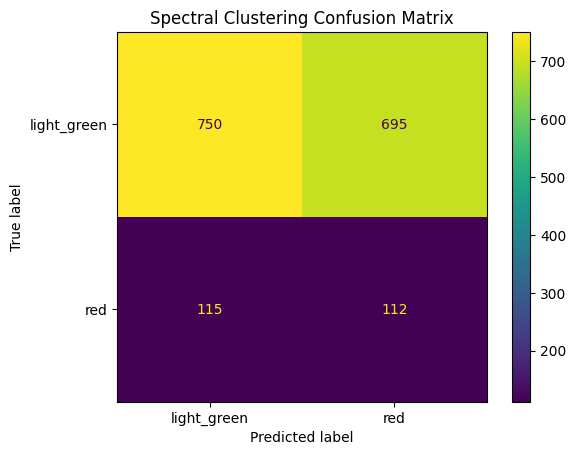

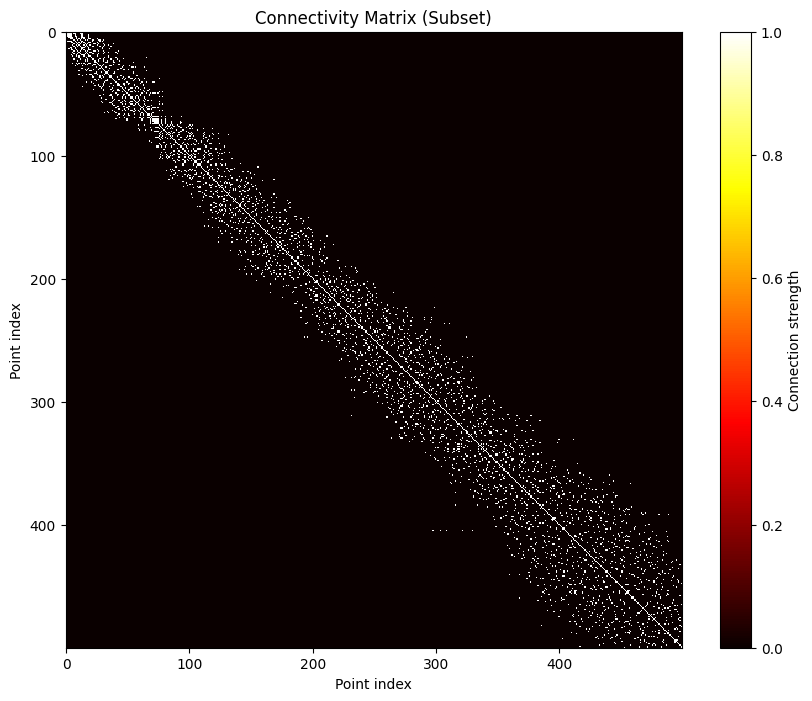

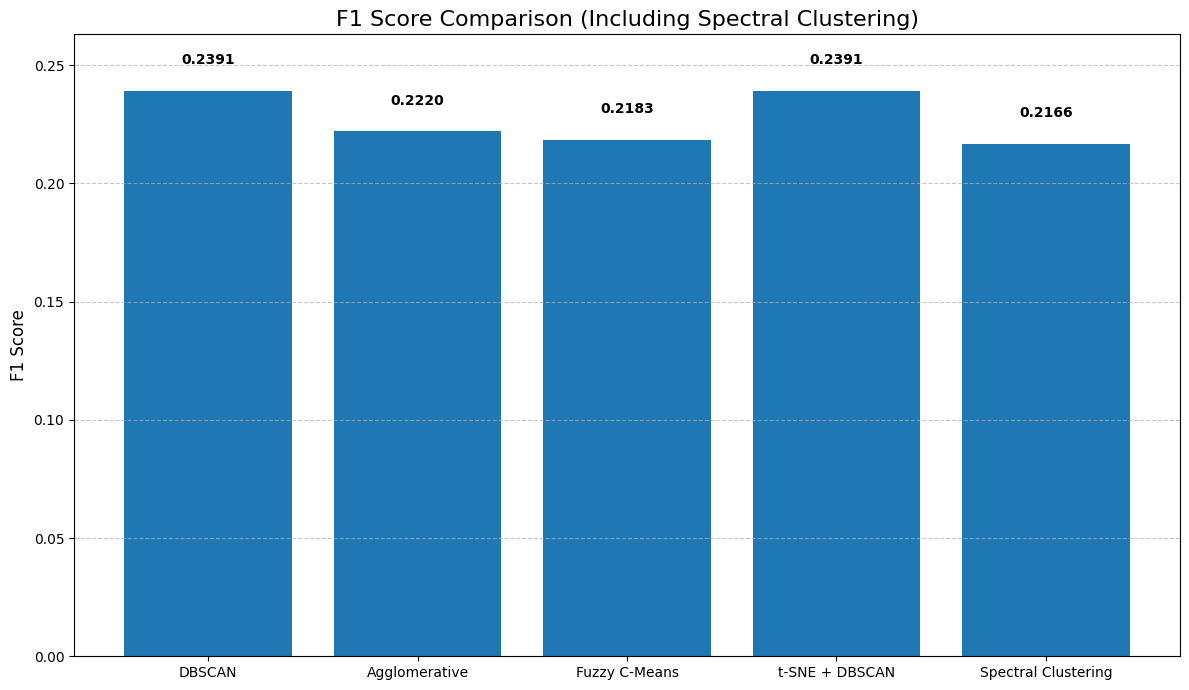

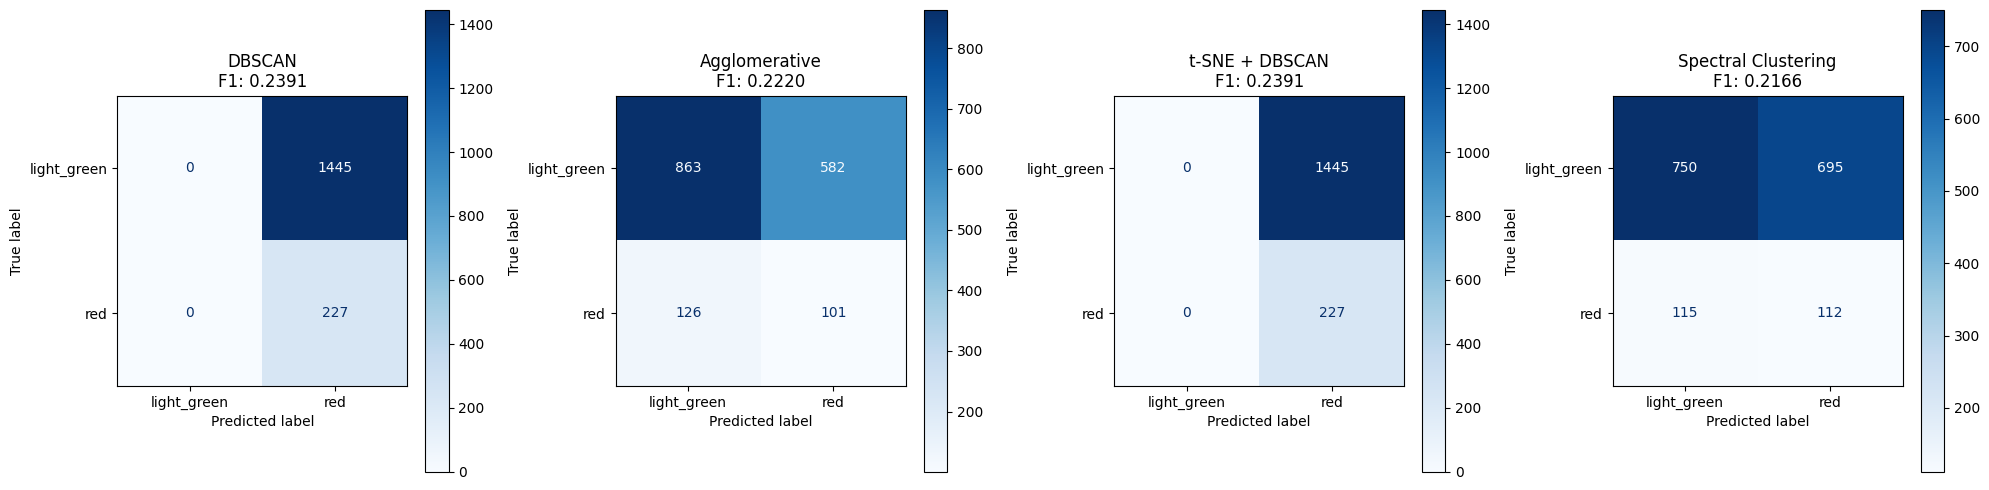

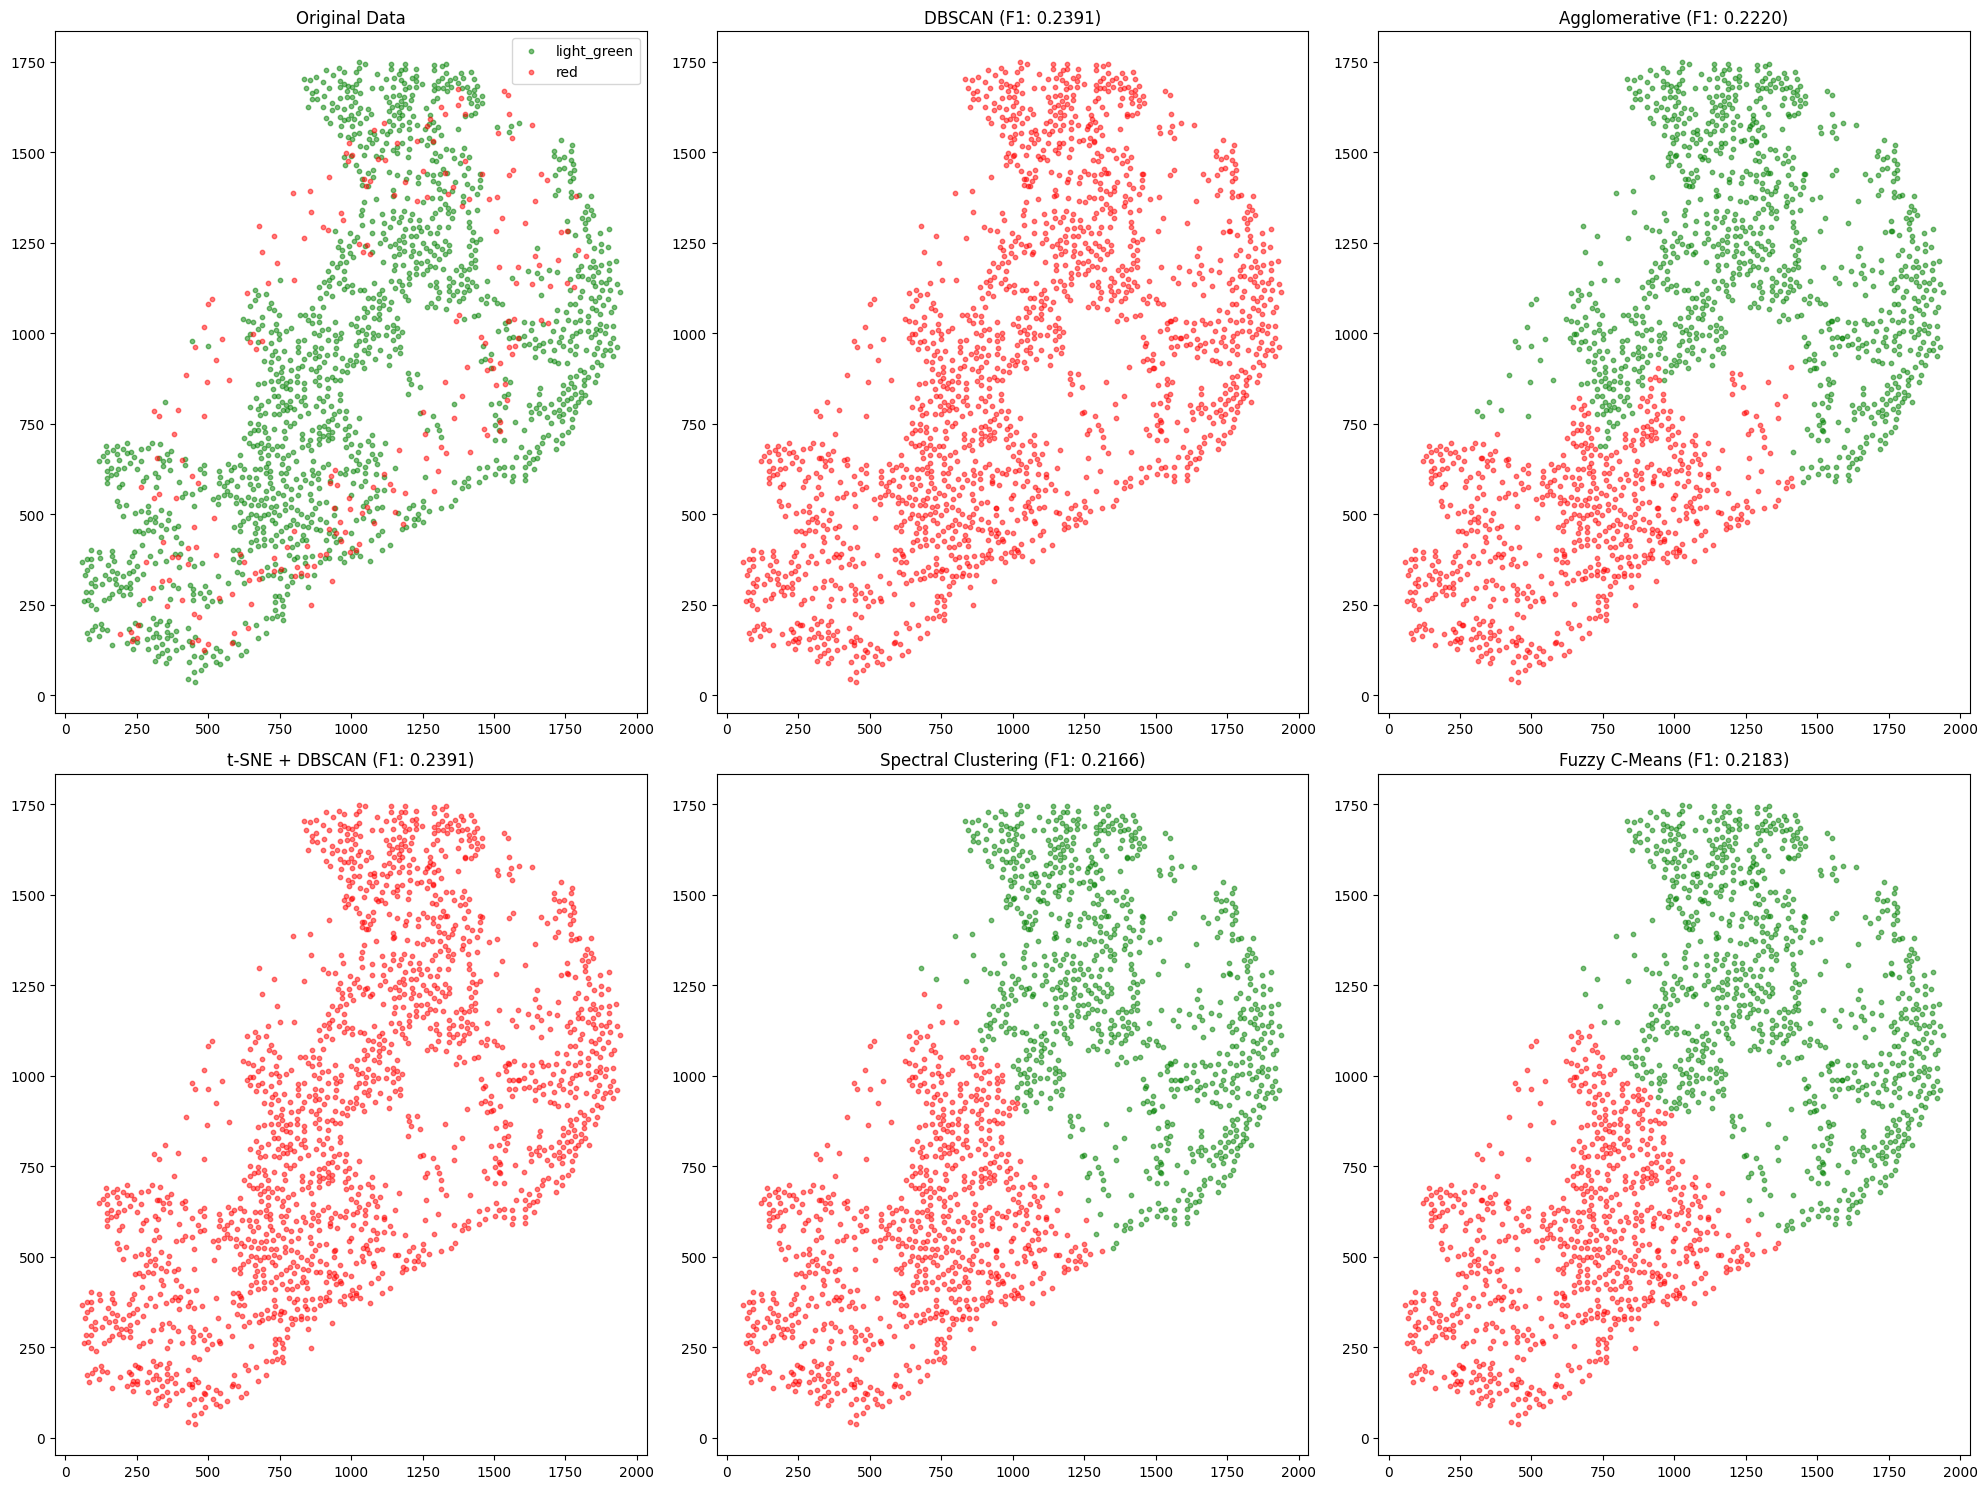

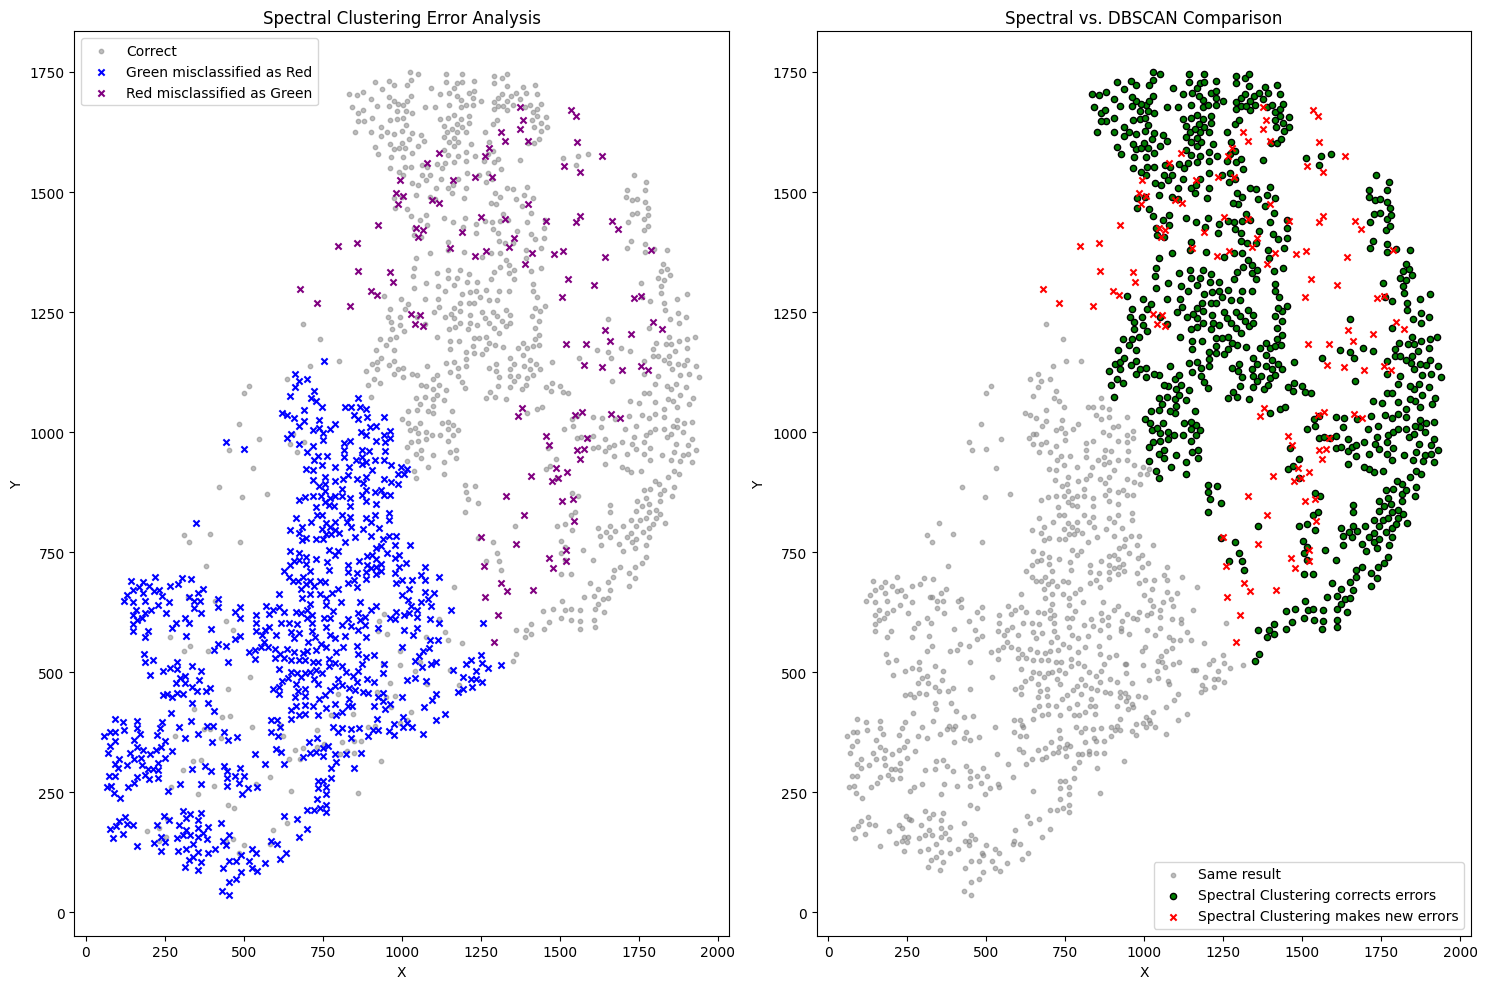

In [ ]:
# %% [code]
# 5. Spectral Clustering - New method for better accuracy
print("\n===== Running Spectral Clustering =====")
from sklearn.cluster import SpectralClustering

# Try different parameters for Spectral Clustering
# The affinity parameter is crucial - 'nearest_neighbors' often works well for spatial data
# n_clusters=2 since we have two classes (red and green)
spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',  # Better for spatial data with complex structures
    n_neighbors=10,                # Number of neighbors for affinity matrix
    random_state=42,
    assign_labels='discretize'     # More stable than 'kmeans' for this type of data
)
spectral_labels = spectral.fit_predict(X_scaled)

# Evaluate Spectral Clustering
spectral_f1, spectral_pred = evaluate_clustering(y_true, spectral_labels, "Spectral Clustering")

# Visualize the affinity matrix to understand connectivity
from sklearn.neighbors import kneighbors_graph
from scipy import sparse

# Create the connectivity matrix used in spectral clustering
connectivity = kneighbors_graph(X_scaled, n_neighbors=10, include_self=True)
# Convert to dense for visualization (only for a subset for clarity)
subset_size = min(500, len(X_scaled))
connectivity_subset = connectivity.toarray()[:subset_size, :subset_size]

plt.figure(figsize=(10, 8))
plt.imshow(connectivity_subset, cmap='hot', interpolation='nearest')
plt.colorbar(label='Connection strength')
plt.title('Connectivity Matrix (Subset)')
plt.xlabel('Point index')
plt.ylabel('Point index')
plt.show()

# %% [code]
# Update comparison with the new method
methods = ['DBSCAN', 'Agglomerative', 't-SNE + DBSCAN', 'Spectral Clustering']
f1_scores = [dbscan_f1, agg_f1, tsne_f1, spectral_f1]

if 'fcm_f1' in locals() and fcm_f1 is not None:
    methods.insert(2, 'Fuzzy C-Means')
    f1_scores.insert(2, fcm_f1)

plt.figure(figsize=(12, 7))
bars = plt.bar(methods, f1_scores)
plt.title('F1 Score Comparison (Including Spectral Clustering)', fontsize=16)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, max(f1_scores) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{f1_scores[i]:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# %% [code]
# Compare confusion matrices side by side
plt.figure(figsize=(20, 5))

# DBSCAN
plt.subplot(1, 4, 1)
cm = confusion_matrix(y_true, dbscan_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["light_green", "red"])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'DBSCAN\nF1: {dbscan_f1:.4f}')

# Agglomerative
plt.subplot(1, 4, 2)
cm = confusion_matrix(y_true, agg_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["light_green", "red"])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Agglomerative\nF1: {agg_f1:.4f}')

# t-SNE + DBSCAN
plt.subplot(1, 4, 3)
cm = confusion_matrix(y_true, tsne_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["light_green", "red"])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f't-SNE + DBSCAN\nF1: {tsne_f1:.4f}')

# Spectral Clustering
plt.subplot(1, 4, 4)
cm = confusion_matrix(y_true, spectral_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["light_green", "red"])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Spectral Clustering\nF1: {spectral_f1:.4f}')

plt.tight_layout()
plt.show()

# %% [code]
# Visualize all methods side by side for direct comparison
plt.figure(figsize=(20, 15))

# Original data
plt.subplot(2, 3, 1)
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='green', label='light_green', alpha=0.5, s=10)
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', label='red', alpha=0.5, s=10)
plt.title('Original Data')
plt.legend()

# DBSCAN results
plt.subplot(2, 3, 2)
plt.scatter(X[dbscan_pred == 0, 0], X[dbscan_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[dbscan_pred == 1, 0], X[dbscan_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'DBSCAN (F1: {dbscan_f1:.4f})')

# Agglomerative Clustering results
plt.subplot(2, 3, 3)
plt.scatter(X[agg_pred == 0, 0], X[agg_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[agg_pred == 1, 0], X[agg_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Agglomerative (F1: {agg_f1:.4f})')

# t-SNE + DBSCAN results
plt.subplot(2, 3, 4)
plt.scatter(X[tsne_pred == 0, 0], X[tsne_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[tsne_pred == 1, 0], X[tsne_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f't-SNE + DBSCAN (F1: {tsne_f1:.4f})')

# Spectral Clustering results
plt.subplot(2, 3, 5)
plt.scatter(X[spectral_pred == 0, 0], X[spectral_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[spectral_pred == 1, 0], X[spectral_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Spectral Clustering (F1: {spectral_f1:.4f})')

# Fuzzy C-Means results (if available)
if 'fcm_f1' in locals() and fcm_f1 is not None:
    plt.subplot(2, 3, 6)
    plt.scatter(X[fcm_pred == 0, 0], X[fcm_pred == 0, 1], c='green', alpha=0.5, s=10)
    plt.scatter(X[fcm_pred == 1, 0], X[fcm_pred == 1, 1], c='red', alpha=0.5, s=10)
    plt.title(f'Fuzzy C-Means (F1: {fcm_f1:.4f})')
else:
    plt.subplot(2, 3, 6)
    plt.axis('off')  # Hide if FCM wasn't available

plt.tight_layout()
plt.show()

# %% [code]
# Error analysis for Spectral Clustering
misclassified = (spectral_pred != y_true)
plt.figure(figsize=(15, 10))

# Show where Spectral Clustering makes errors
plt.subplot(1, 2, 1)
plt.scatter(X[~misclassified, 0], X[~misclassified, 1], c='gray', alpha=0.5, s=10, label='Correct')
plt.scatter(X[misclassified & (y_true == 0), 0], X[misclassified & (y_true == 0), 1],
            c='blue', marker='x', s=20, label='Green misclassified as Red')
plt.scatter(X[misclassified & (y_true == 1), 0], X[misclassified & (y_true == 1), 1],
            c='purple', marker='x', s=20, label='Red misclassified as Green')
plt.title('Spectral Clustering Error Analysis')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# Compare error patterns between best previous method and Spectral Clustering
best_idx = np.argmax(f1_scores[:-1])  # Exclude Spectral Clustering from this comparison
best_method = methods[best_idx]
best_pred = None

if best_method == 'DBSCAN':
    best_pred = dbscan_pred
elif best_method == 'Agglomerative':
    best_pred = agg_pred
elif best_method == 'Fuzzy C-Means':
    best_pred = fcm_pred
else:  # t-SNE + DBSCAN
    best_pred = tsne_pred

# Find where Spectral Clustering improves over the previous best method
spectral_correct = (spectral_pred == y_true)
best_correct = (best_pred == y_true)
spectral_improvement = np.logical_and(spectral_correct, ~best_correct)
spectral_worsening = np.logical_and(~spectral_correct, best_correct)

plt.subplot(1, 2, 2)
plt.scatter(X[~spectral_improvement & ~spectral_worsening, 0],
            X[~spectral_improvement & ~spectral_worsening, 1],
            c='gray', alpha=0.5, s=10, label='Same result')
plt.scatter(X[spectral_improvement, 0], X[spectral_improvement, 1],
            c='green', marker='o', s=20, edgecolor='black', label='Spectral Clustering corrects errors')
plt.scatter(X[spectral_worsening, 0], X[spectral_worsening, 1],
            c='red', marker='x', s=20, label='Spectral Clustering makes new errors')
plt.title(f'Spectral vs. {best_method} Comparison')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

# ICA


===== Running ICA Preprocessing with Clustering =====
Original feature space: 2 dimensions
Expanded feature space with polynomial features: 9 dimensions
ICA reduced to: 5 independent components


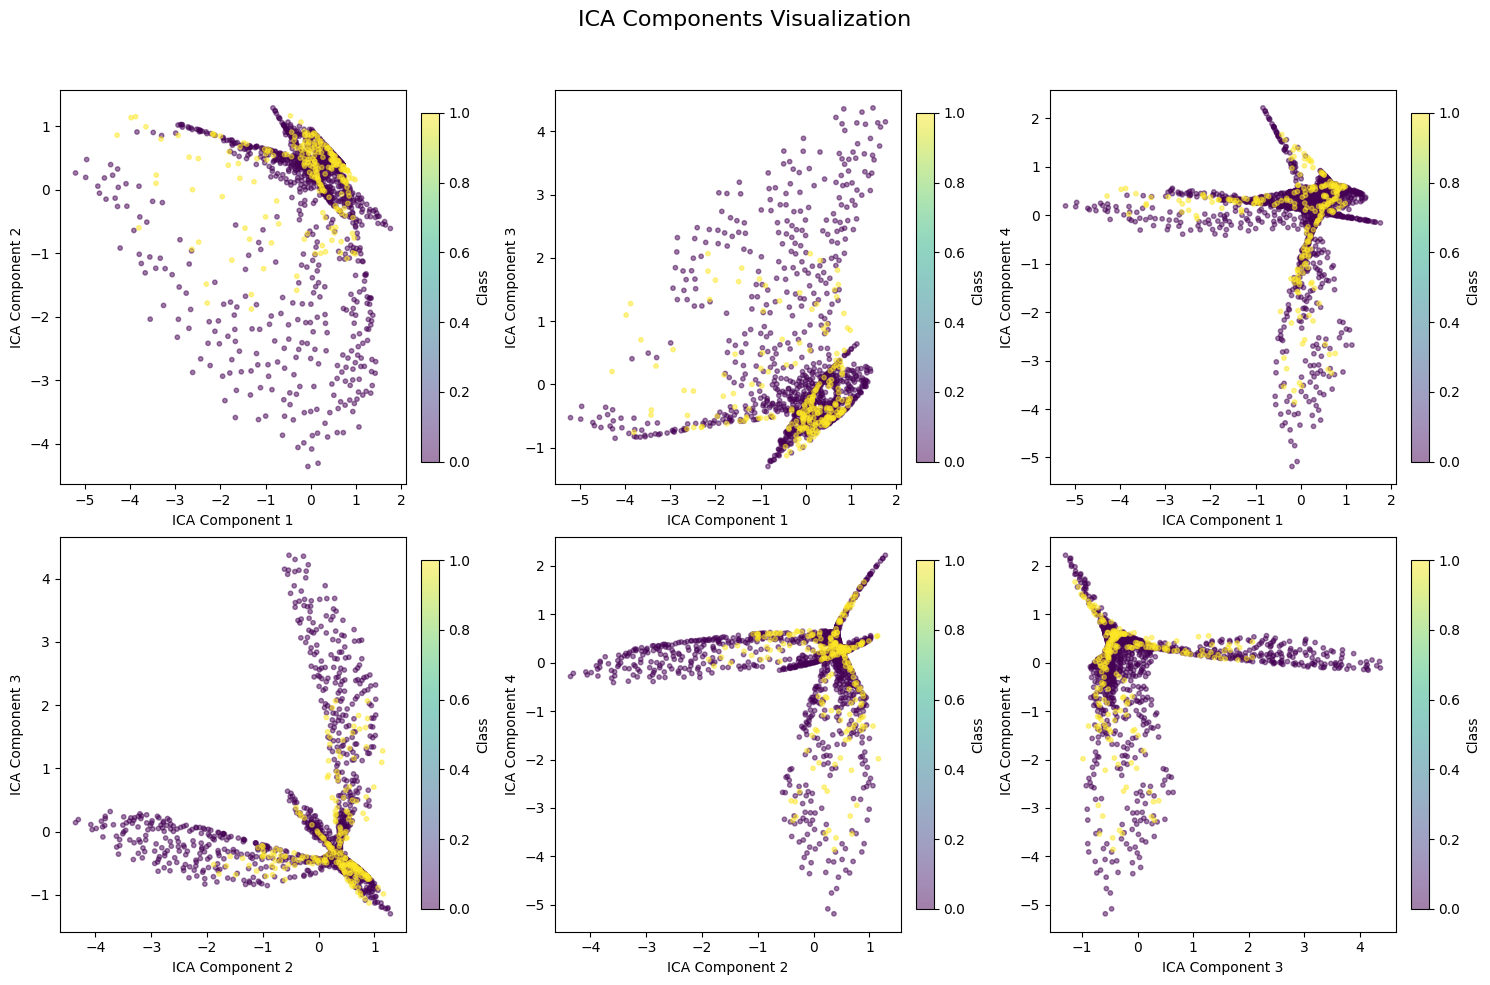

In [ ]:
# %% [code]
# 6. ICA Preprocessing + Clustering - Fixed version
print("\n===== Running ICA Preprocessing with Clustering =====")

from sklearn.decomposition import FastICA
from sklearn.mixture import GaussianMixture
import itertools

# First, let's expand our feature space to give ICA more to work with
# Since we only have X and Y coordinates, we'll create polynomial features
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

print(f"Original feature space: {X_scaled.shape[1]} dimensions")
print(f"Expanded feature space with polynomial features: {X_poly.shape[1]} dimensions")

# Apply ICA to the expanded feature space
# n_components should be <= number of features
n_components = min(5, X_poly.shape[1])
ica = FastICA(n_components=n_components, random_state=42, max_iter=1000)
X_ica = ica.fit_transform(X_poly)

print(f"ICA reduced to: {X_ica.shape[1]} independent components")

# Visualize the ICA components - FIXED SECTION
plt.figure(figsize=(15, 10))
plot_idx = 1  # Start with the first subplot
for i in range(min(4, X_ica.shape[1])):
    for j in range(i+1, min(4, X_ica.shape[1])):
        if plot_idx <= 6:  # Only create up to 6 subplots (2x3 grid)
            plt.subplot(2, 3, plot_idx)
            plt.scatter(X_ica[:, i], X_ica[:, j], c=y_true, cmap='viridis', alpha=0.5, s=10)
            plt.xlabel(f'ICA Component {i+1}')
            plt.ylabel(f'ICA Component {j+1}')
            plt.colorbar(label='Class', fraction=0.046, pad=0.04)
            plot_idx += 1

plt.tight_layout()
plt.suptitle('ICA Components Visualization', fontsize=16)
plt.subplots_adjust(top=0.9)
plt.show()

# Continue with the rest of the ICA clustering code...


--- DBSCAN on ICA components ---


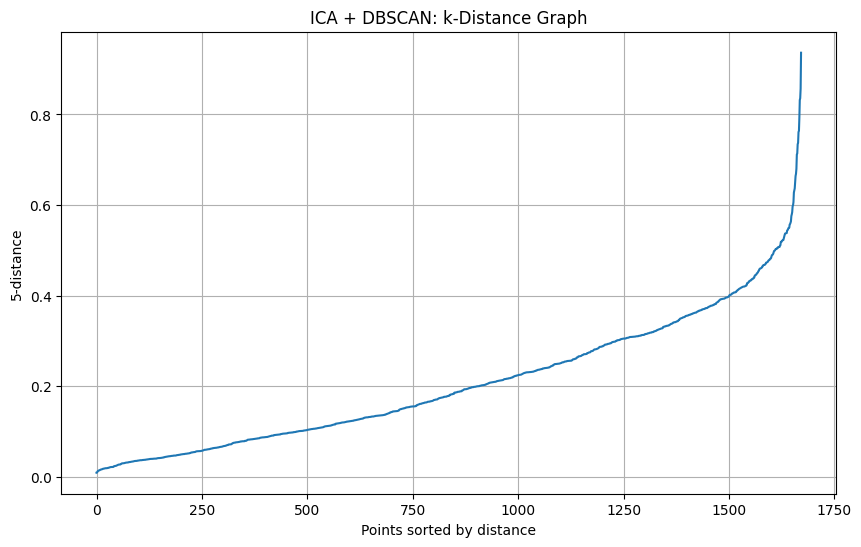

Best ICA+DBSCAN parameters: eps=0.50, min_samples=3

ICA + DBSCAN - F1 Score: 0.2391


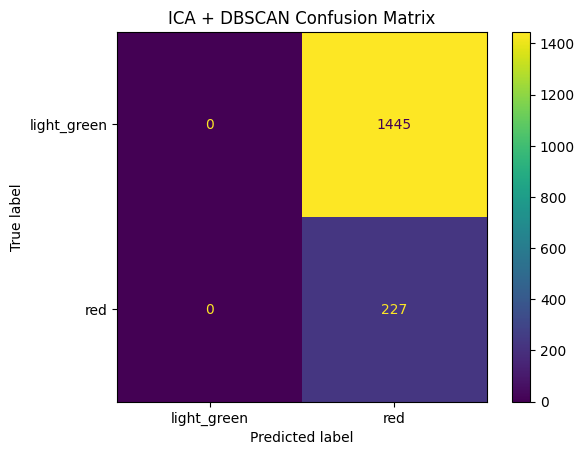


--- Agglomerative Clustering on ICA components ---

ICA + Agglomerative - F1 Score: 0.2216


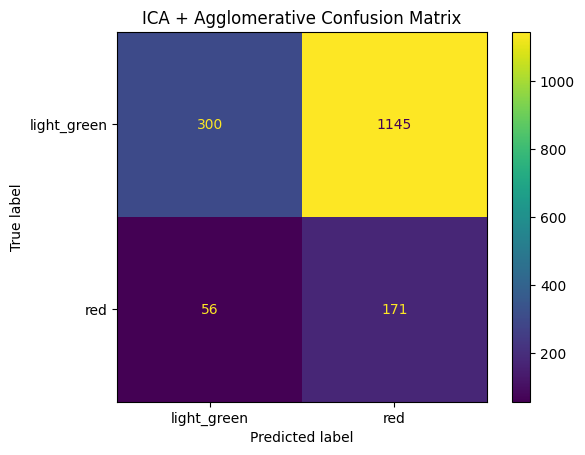

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7e492d9ee0c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e


--- Gaussian Mixture Model on ICA components ---

ICA + Gaussian Mixture - F1 Score: 0.2490


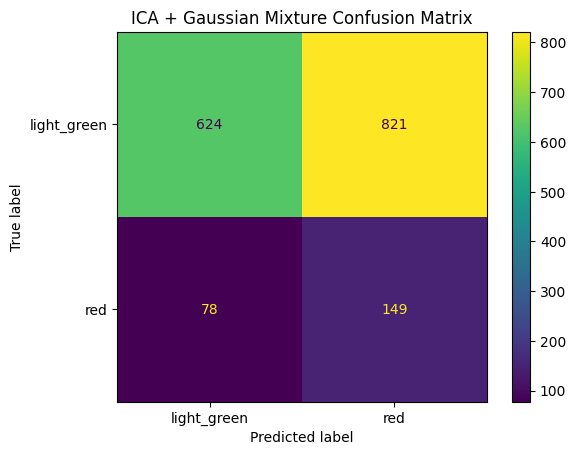


--- Spectral Clustering on ICA components ---

ICA + Spectral Clustering - F1 Score: 0.2159


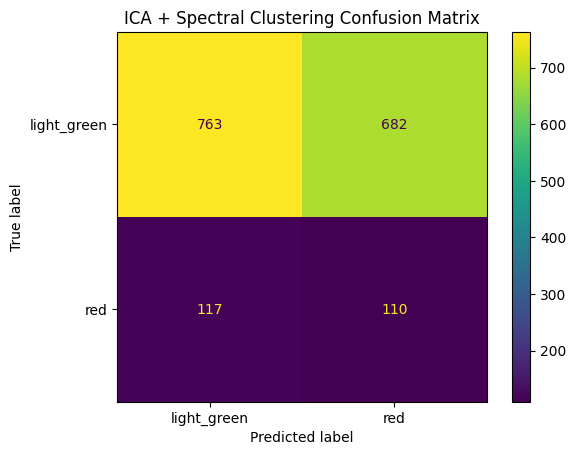


--- K-Means on ICA components ---

ICA + K-Means - F1 Score: 0.2515


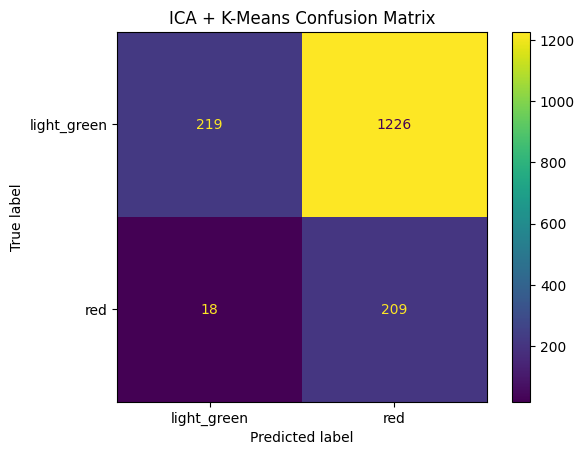

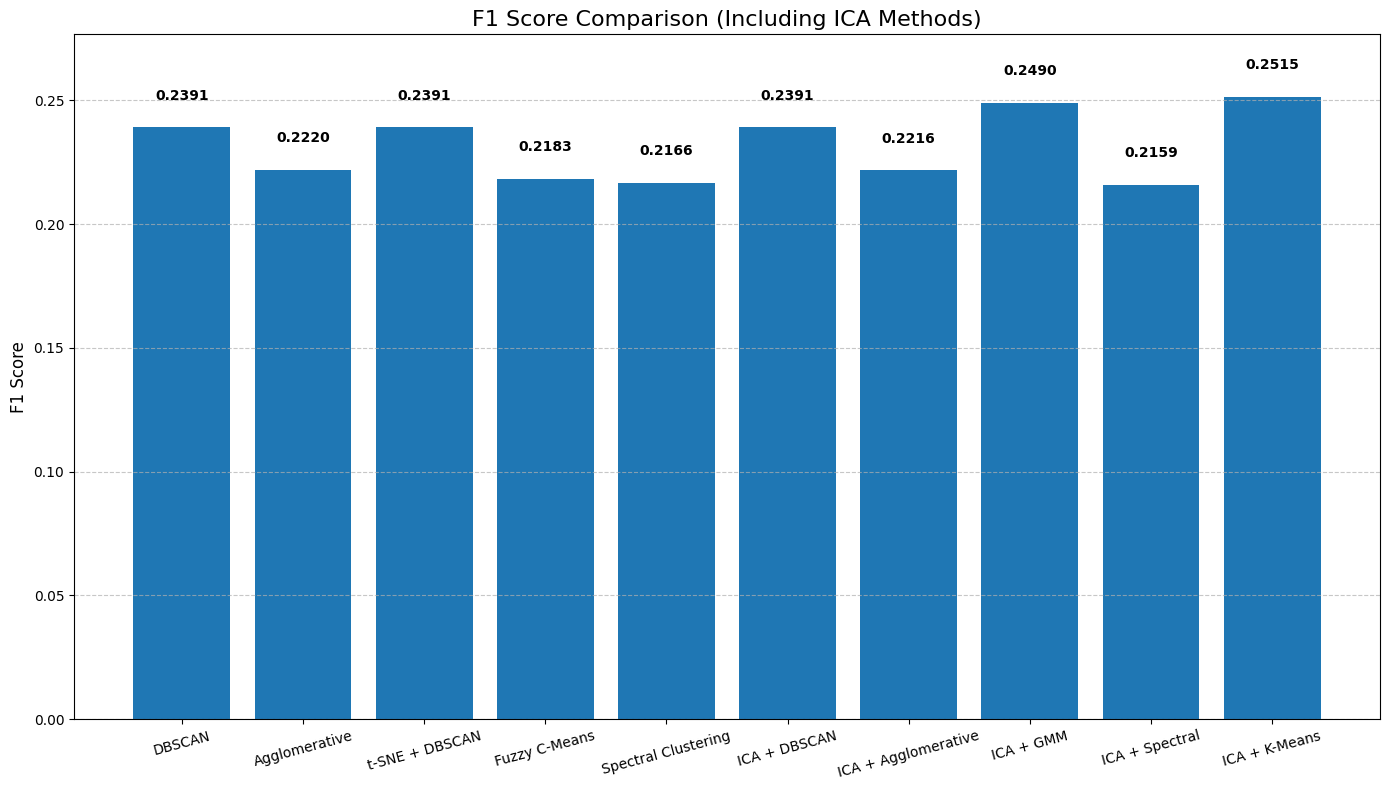

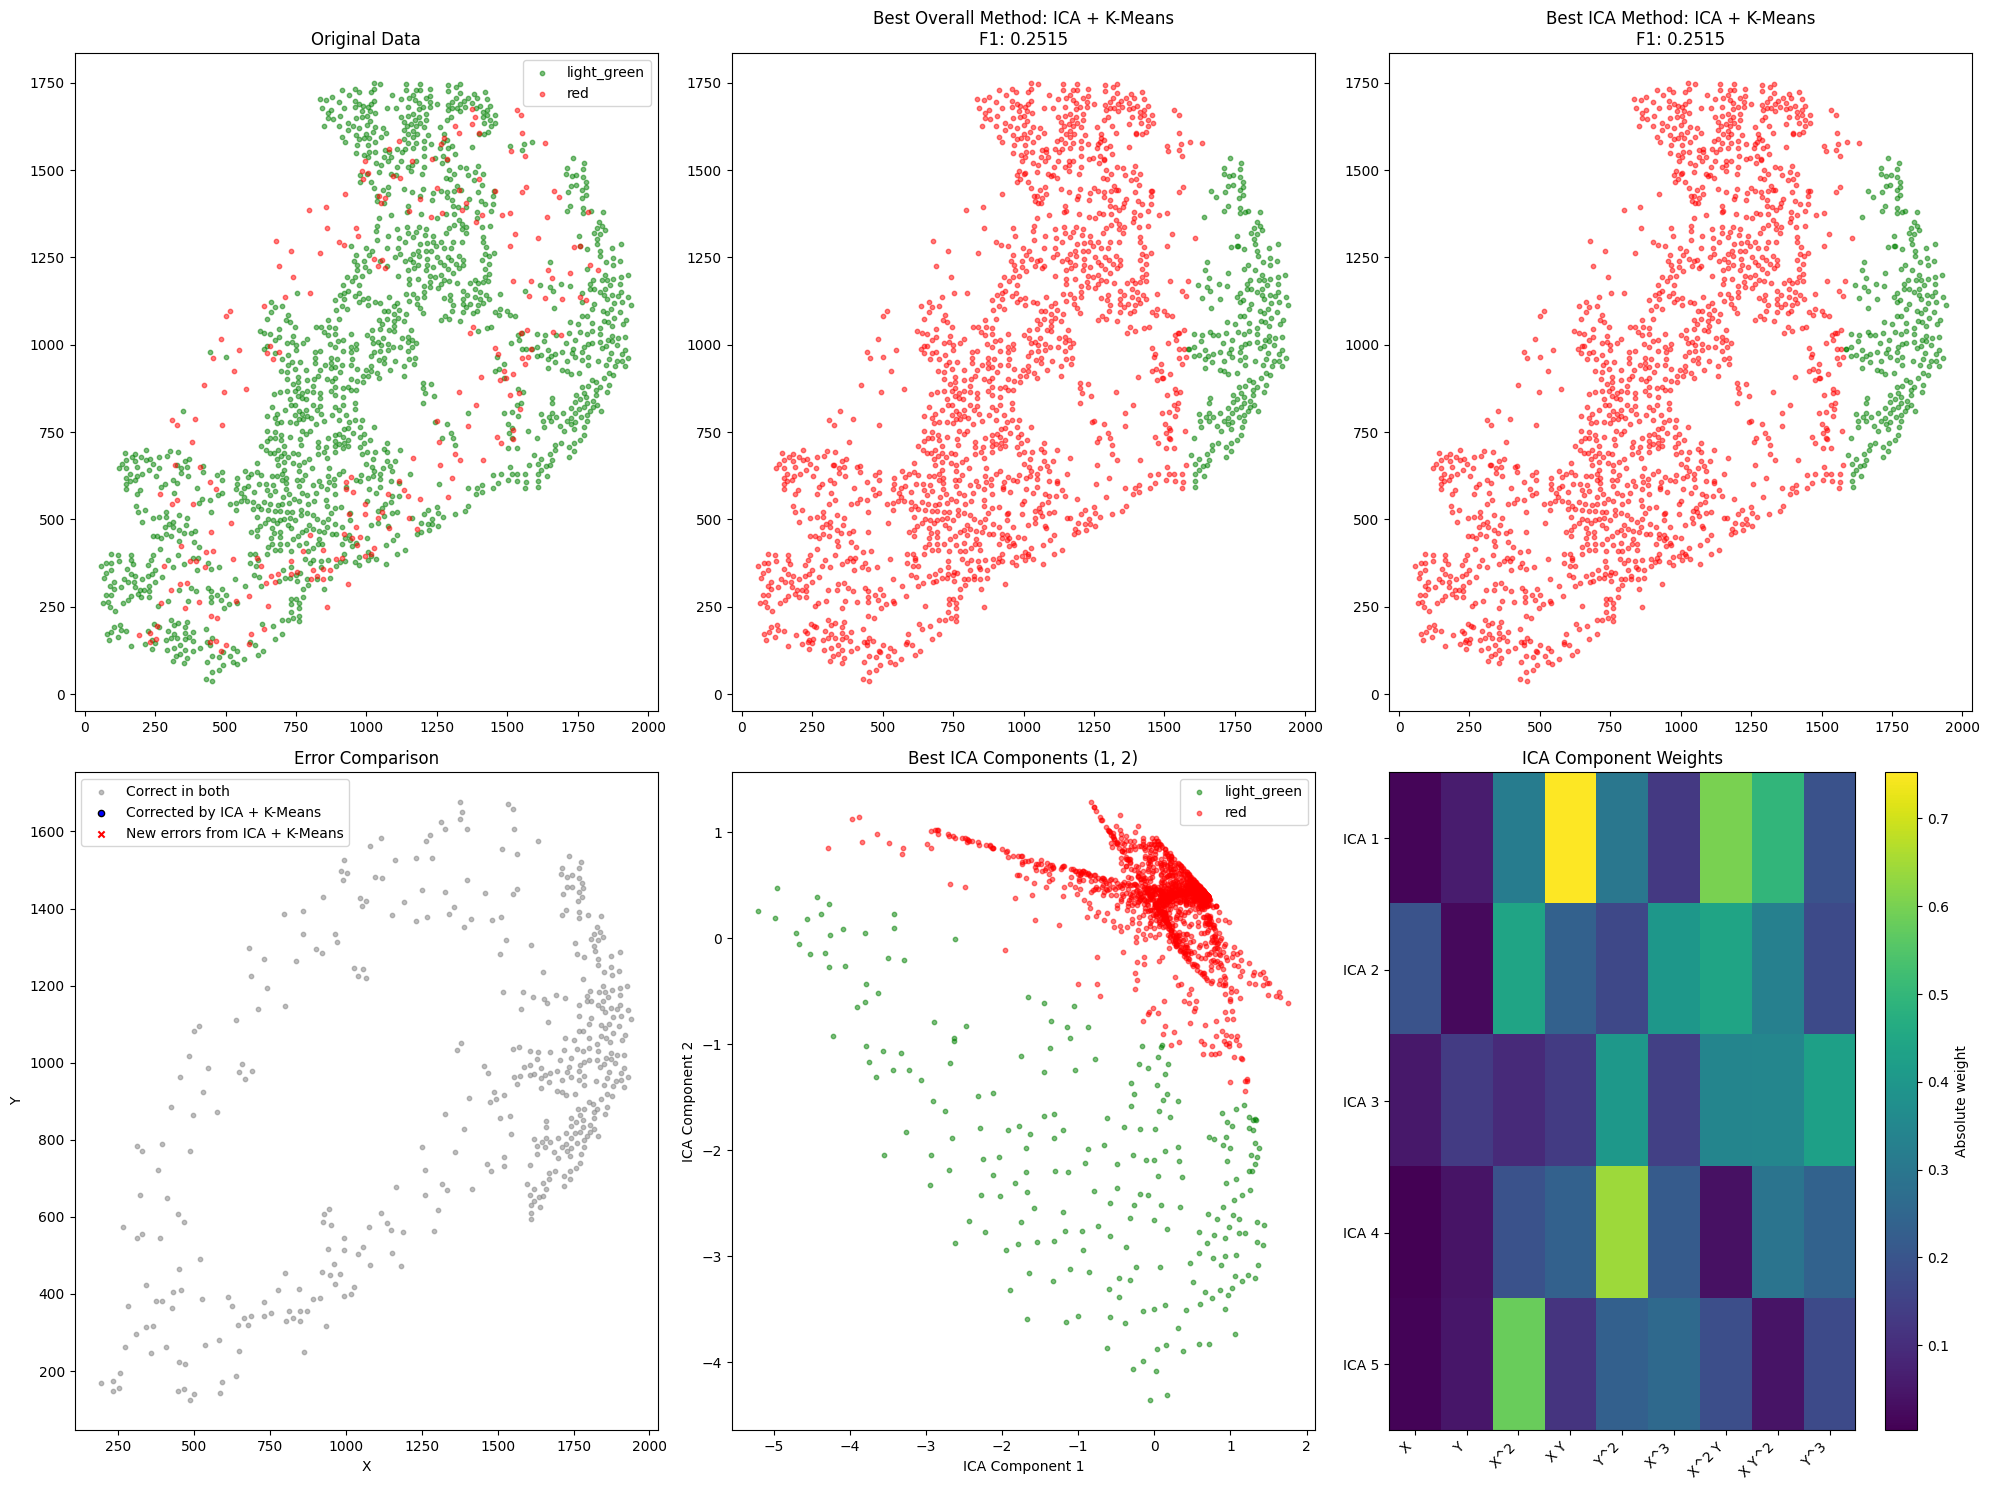

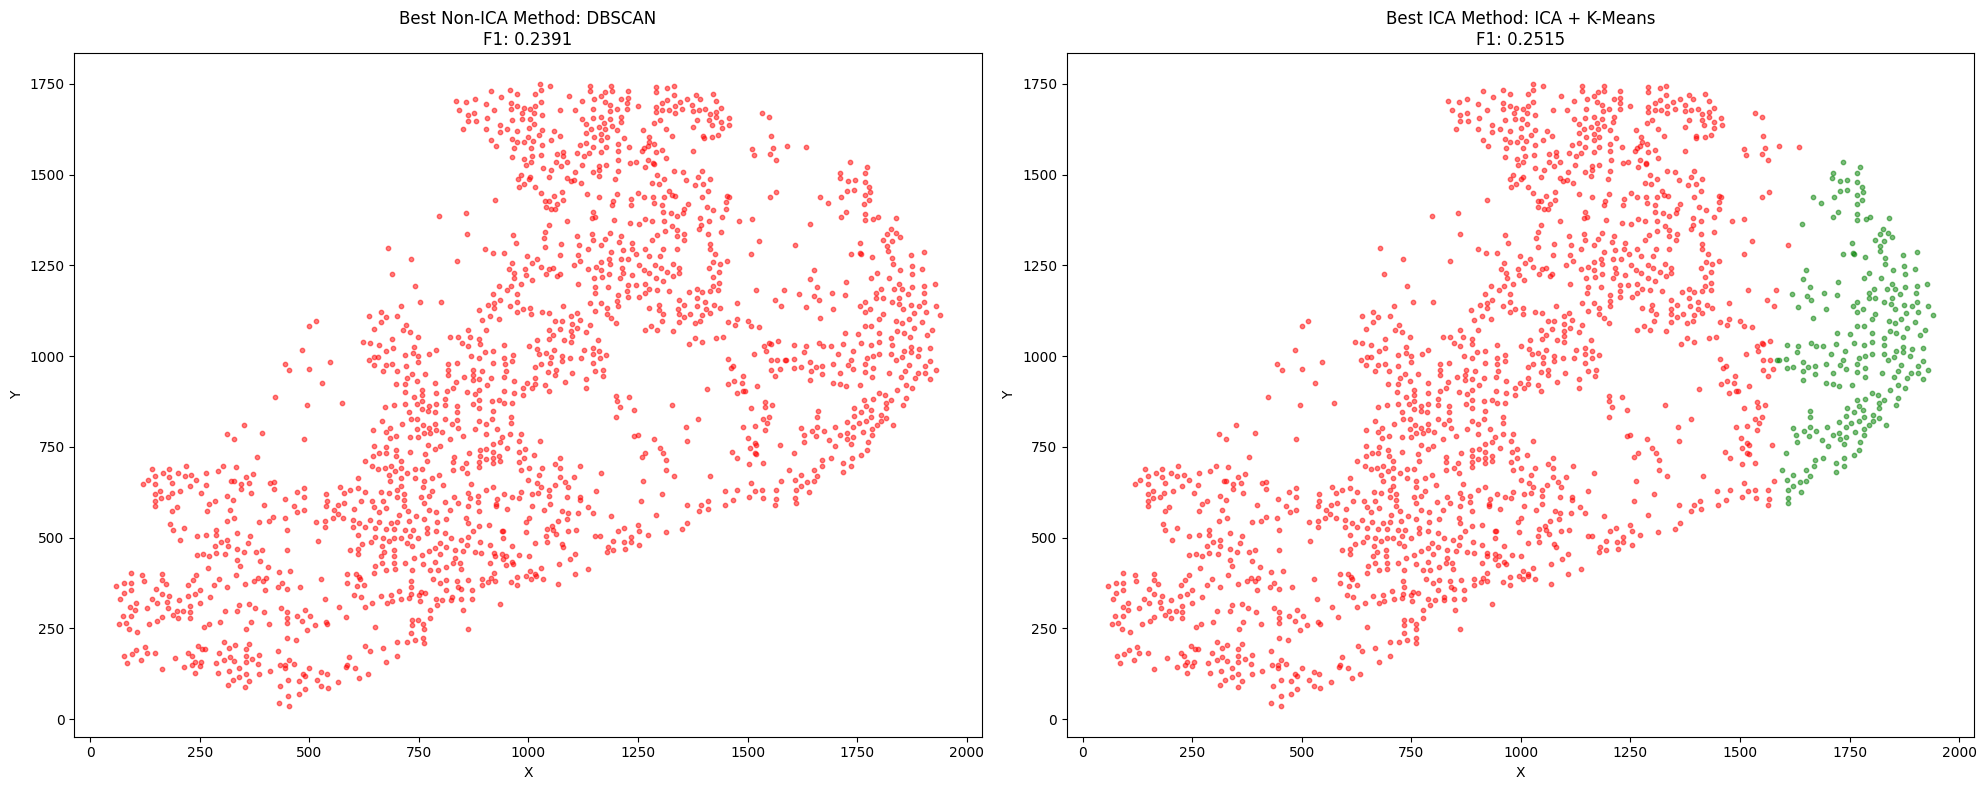

In [ ]:

# Now apply various clustering algorithms to the ICA-transformed data
# We'll try multiple algorithms and select the best one

# 1. DBSCAN on ICA components
print("\n--- DBSCAN on ICA components ---")
# Find optimal eps using k-distance graph
k = 5
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_ica)
distances, indices = nbrs.kneighbors(X_ica)
distances = np.sort(distances, axis=0)
distances = distances[:, k-1]

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-distance')
plt.title('ICA + DBSCAN: k-Distance Graph')
plt.grid(True)
plt.show()

# Try different parameter combinations
eps_values = np.linspace(0.5, 3.0, 6)
min_samples_values = [3, 5, 7]

ica_dbscan_f1 = 0
ica_dbscan_params = None
ica_dbscan_labels = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_ica)

        # Check if we have valid clusters
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2:
            continue

        # Map labels to 0 and 1
        if -1 in unique_labels:
            mask = labels != -1
            if np.sum(mask) < len(y_true)/10:
                continue

            mapped_labels = np.zeros_like(labels)
            for cluster_id in unique_labels:
                if cluster_id == -1:
                    continue
                cluster_mask = labels == cluster_id
                majority_class = np.bincount(y_true[cluster_mask]).argmax()
                mapped_labels[cluster_mask] = majority_class
            # Handle noise points
            majority_class = np.bincount(y_true).argmax()
            mapped_labels[labels == -1] = majority_class
        else:
            mapped_labels = np.zeros_like(labels)
            for i, cluster_id in enumerate(unique_labels):
                cluster_mask = labels == cluster_id
                majority_class = np.bincount(y_true[cluster_mask]).argmax()
                mapped_labels[cluster_mask] = majority_class

        # Evaluate
        f1 = max(f1_score(y_true, mapped_labels, zero_division=0),
                 f1_score(y_true, 1 - mapped_labels, zero_division=0))

        if f1 > ica_dbscan_f1:
            ica_dbscan_f1 = f1
            ica_dbscan_params = (eps, min_samples)
            ica_dbscan_labels = mapped_labels.copy()

if ica_dbscan_params is None:
    # Fallback
    dbscan = DBSCAN(eps=1.5, min_samples=5)
    labels = dbscan.fit_predict(X_ica)

    # Simple mapping
    unique_labels = np.unique(labels)
    if -1 in unique_labels:
        mask = labels != -1
        cluster_labels = np.unique(labels[mask])
        ica_dbscan_labels = np.zeros_like(labels)
        for i, cluster_id in enumerate(cluster_labels):
            cluster_mask = (labels == cluster_id)
            majority_class = np.bincount(y_true[cluster_mask]).argmax()
            ica_dbscan_labels[cluster_mask] = majority_class
        majority_class = np.bincount(y_true).argmax()
        ica_dbscan_labels[labels == -1] = majority_class
    else:
        cluster_labels = np.unique(labels)
        ica_dbscan_labels = np.zeros_like(labels)
        for i, cluster_id in enumerate(cluster_labels):
            cluster_mask = (labels == cluster_id)
            majority_class = np.bincount(y_true[cluster_mask]).argmax()
            ica_dbscan_labels[cluster_mask] = majority_class
    ica_dbscan_params = (1.5, 5)

print(f"Best ICA+DBSCAN parameters: eps={ica_dbscan_params[0]:.2f}, min_samples={ica_dbscan_params[1]}")
ica_dbscan_f1, ica_dbscan_pred = evaluate_clustering(y_true, ica_dbscan_labels, "ICA + DBSCAN")

# 2. Agglomerative Clustering on ICA components
print("\n--- Agglomerative Clustering on ICA components ---")
agg_clustering = AgglomerativeClustering(n_clusters=2)
agg_labels = agg_clustering.fit_predict(X_ica)
ica_agg_f1, ica_agg_pred = evaluate_clustering(y_true, agg_labels, "ICA + Agglomerative")

# 3. Gaussian Mixture Model on ICA components (soft clustering alternative)
print("\n--- Gaussian Mixture Model on ICA components ---")
gmm = GaussianMixture(n_components=2, random_state=42, covariance_type='full')
gmm_labels = gmm.fit_predict(X_ica)
ica_gmm_f1, ica_gmm_pred = evaluate_clustering(y_true, gmm_labels, "ICA + Gaussian Mixture")

# 4. Spectral Clustering on ICA components
print("\n--- Spectral Clustering on ICA components ---")
spectral = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    n_neighbors=10,
    random_state=42,
    assign_labels='discretize'
)
spectral_labels = spectral.fit_predict(X_ica)
ica_spectral_f1, ica_spectral_pred = evaluate_clustering(y_true, spectral_labels, "ICA + Spectral Clustering")

# 5. K-Means on ICA components (for completeness)
print("\n--- K-Means on ICA components ---")
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_ica)
ica_kmeans_f1, ica_kmeans_pred = evaluate_clustering(y_true, kmeans_labels, "ICA + K-Means")

# %% [code]
# Compare all methods including ICA variants
methods = [
    'DBSCAN', 'Agglomerative', 't-SNE + DBSCAN',
    'Spectral Clustering', 'ICA + DBSCAN', 'ICA + Agglomerative',
    'ICA + GMM', 'ICA + Spectral', 'ICA + K-Means'
]
f1_scores = [
    dbscan_f1, agg_f1, tsne_f1, spectral_f1,
    ica_dbscan_f1, ica_agg_f1, ica_gmm_f1, ica_spectral_f1, ica_kmeans_f1
]

if 'fcm_f1' in locals() and fcm_f1 is not None:
    methods.insert(3, 'Fuzzy C-Means')
    f1_scores.insert(3, fcm_f1)

plt.figure(figsize=(14, 8))
bars = plt.bar(methods, f1_scores)
plt.title('F1 Score Comparison (Including ICA Methods)', fontsize=16)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, max(f1_scores) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{f1_scores[i]:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# %% [code]
# Visualize the best ICA-based method
best_ica_idx = np.argmax([ica_dbscan_f1, ica_agg_f1, ica_gmm_f1, ica_spectral_f1, ica_kmeans_f1])
best_ica_method = ["ICA + DBSCAN", "ICA + Agglomerative", "ICA + GMM", "ICA + Spectral", "ICA + K-Means"][best_ica_idx]
best_ica_score = [ica_dbscan_f1, ica_agg_f1, ica_gmm_f1, ica_spectral_f1, ica_kmeans_f1][best_ica_idx]
best_ica_pred = [ica_dbscan_pred, ica_agg_pred, ica_gmm_pred, ica_spectral_pred, ica_kmeans_pred][best_ica_idx]

plt.figure(figsize=(20, 15))

# Original data
plt.subplot(2, 3, 1)
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='green', label='light_green', alpha=0.5, s=10)
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', label='red', alpha=0.5, s=10)
plt.title('Original Data')
plt.legend()

# Best overall method (from all methods)
best_idx = np.argmax(f1_scores)
best_method = methods[best_idx]
best_score = f1_scores[best_idx]

if best_method == 'DBSCAN':
    best_pred = dbscan_pred
elif best_method == 'Agglomerative':
    best_pred = agg_pred
elif best_method == 'Fuzzy C-Means' and 'fcm_f1' in locals() and fcm_f1 is not None:
    best_pred = fcm_pred
elif best_method == 't-SNE + DBSCAN':
    best_pred = tsne_pred
elif best_method == 'Spectral Clustering':
    best_pred = spectral_pred
elif best_method == 'ICA + DBSCAN':
    best_pred = ica_dbscan_pred
elif best_method == 'ICA + Agglomerative':
    best_pred = ica_agg_pred
elif best_method == 'ICA + GMM':
    best_pred = ica_gmm_pred
elif best_method == 'ICA + Spectral':
    best_pred = ica_spectral_pred
else:  # 'ICA + K-Means'
    best_pred = ica_kmeans_pred

# Best overall method results
plt.subplot(2, 3, 2)
plt.scatter(X[best_pred == 0, 0], X[best_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[best_pred == 1, 0], X[best_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Best Overall Method: {best_method}\nF1: {best_score:.4f}')

# Best ICA-based method results
plt.subplot(2, 3, 3)
plt.scatter(X[best_ica_pred == 0, 0], X[best_ica_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[best_ica_pred == 1, 0], X[best_ica_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Best ICA Method: {best_ica_method}\nF1: {best_ica_score:.4f}')

# Error comparison between best overall and best ICA method
plt.subplot(2, 3, 4)
misclassified_overall = (best_pred != y_true)
misclassified_ica = (best_ica_pred != y_true)

plt.scatter(X[~misclassified_overall, 0], X[~misclassified_overall, 1],
            c='gray', alpha=0.5, s=10, label='Correct in both')
plt.scatter(X[misclassified_overall & ~misclassified_ica, 0], X[misclassified_overall & ~misclassified_ica, 1],
            c='blue', marker='o', s=20, edgecolor='black', label=f'Corrected by {best_ica_method}')
plt.scatter(X[~misclassified_overall & misclassified_ica, 0], X[~misclassified_overall & misclassified_ica, 1],
            c='red', marker='x', s=20, label=f'New errors from {best_ica_method}')
plt.title('Error Comparison')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# Compare the ICA components that gave the best separation
plt.subplot(2, 3, 5)
# Find which pair of ICA components gives the best visual separation
best_pair = (0, 1)
best_score = -1

for i, j in itertools.combinations(range(min(5, X_ica.shape[1])), 2):
    # Project to 2D using these components
    X_proj = np.column_stack((X_ica[:, i], X_ica[:, j]))

    # Try a simple linear separator
    from sklearn.linear_model import LogisticRegression
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_proj, y_true)
    score = clf.score(X_proj, y_true)

    if score > best_score:
        best_score = score
        best_pair = (i, j)

plt.scatter(X_ica[best_pred == 0, best_pair[0]], X_ica[best_pred == 0, best_pair[1]],
            c='green', alpha=0.5, s=10, label='light_green')
plt.scatter(X_ica[best_pred == 1, best_pair[0]], X_ica[best_pred == 1, best_pair[1]],
            c='red', alpha=0.5, s=10, label='red')
plt.title(f'Best ICA Components ({best_pair[0]+1}, {best_pair[1]+1})')
plt.xlabel(f'ICA Component {best_pair[0]+1}')
plt.ylabel(f'ICA Component {best_pair[1]+1}')
plt.legend()

# Feature importance from ICA
plt.subplot(2, 3, 6)
# Get the mixing matrix (inverse of the unmixing matrix)
ica_components = ica.components_
n_original_features = X_scaled.shape[1]  # 2 original features (X, Y)

# Create labels for the polynomial features
poly_feature_names = poly.get_feature_names_out(['X', 'Y'])

# Plot the contribution of each original feature to the ICA components
plt.imshow(np.abs(ica_components), aspect='auto', cmap='viridis')
plt.colorbar(label='Absolute weight')
plt.xticks(range(len(poly_feature_names)), poly_feature_names, rotation=45, ha='right')
plt.yticks(range(n_components), [f'ICA {i+1}' for i in range(n_components)])
plt.title('ICA Component Weights')
plt.tight_layout()

plt.tight_layout()
plt.show()

# %% [code]
# Analyze why ICA helps - show the decision boundaries
from sklearn.inspection import DecisionBoundaryDisplay

# Find the best ICA-based method
best_ica_idx = np.argmax([ica_dbscan_f1, ica_agg_f1, ica_gmm_f1, ica_spectral_f1, ica_kmeans_f1])
best_ica_method_name = ["ICA + DBSCAN", "ICA + Agglomerative", "ICA + GMM", "ICA + Spectral", "ICA + K-Means"][best_ica_idx]
best_ica_pred = [ica_dbscan_pred, ica_agg_pred, ica_gmm_pred, ica_spectral_pred, ica_kmeans_pred][best_ica_idx]
best_ica_score = [ica_dbscan_f1, ica_agg_f1, ica_gmm_f1, ica_spectral_f1, ica_kmeans_f1][best_ica_idx]

# Find the best non-ICA method for comparison
non_ica_methods = ['DBSCAN', 'Agglomerative', 't-SNE + DBSCAN', 'Spectral Clustering']
non_ica_scores = [dbscan_f1, agg_f1, tsne_f1, spectral_f1]
if 'fcm_f1' in locals() and fcm_f1 is not None:
    non_ica_methods.append('Fuzzy C-Means')
    non_ica_scores.append(fcm_f1)

best_non_ica_idx = np.argmax(non_ica_scores)
best_non_ica_method = non_ica_methods[best_non_ica_idx]
best_non_ica_score = non_ica_scores[best_non_ica_idx]

# Get the predictions for the best non-ICA method
if best_non_ica_method == 'DBSCAN':
    best_non_ica_pred = dbscan_pred
elif best_non_ica_method == 'Agglomerative':
    best_non_ica_pred = agg_pred
elif best_non_ica_method == 'Fuzzy C-Means':
    best_non_ica_pred = fcm_pred
elif best_non_ica_method == 't-SNE + DBSCAN':
    best_non_ica_pred = tsne_pred
else:  # 'Spectral Clustering'
    best_non_ica_pred = spectral_pred

plt.figure(figsize=(20, 8))

# Decision boundary for best non-ICA method
plt.subplot(1, 2, 1)
# We need to create a grid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 10, X[:, 0].max() + 10
y_min, y_max = X[:, 1].min() - 10, X[:, 1].max() + 10
xx, yy = np.meshgrid(np.arange(x_min, x_max, 5),
                     np.arange(y_min, y_max, 5))

# Create a function that maps coordinates to cluster predictions
def predict_non_ica(x, y):
    points = np.column_stack((x, y))
    points_scaled = scaler.transform(points)

    if best_non_ica_method == 'DBSCAN':
        labels = dbscan.fit_predict(points_scaled)
    elif best_non_ica_method == 'Agglomerative':
        labels = agg_clustering.fit_predict(points_scaled)
    elif best_non_ica_method == 'Fuzzy C-Means':
        labels = fcm.predict(points_scaled)
    elif best_non_ica_method == 't-SNE + DBSCAN':
        # This is more complex - we'd need to apply the same t-SNE transformation
        # For simplicity, we'll skip this case
        labels = np.zeros(len(points))
    else:  # 'Spectral Clustering'
        labels = spectral.fit_predict(points_scaled)

    # Map to 0/1
    if len(np.unique(labels)) >= 2:
        mapped_labels = np.zeros_like(labels)
        for i, cluster_id in enumerate(np.unique(labels)):
            cluster_mask = (labels == cluster_id)
            # We don't have true labels here, so we can't determine majority class
            # Instead, we'll just flip if needed based on a reference point
            if i == 0:
                # Check a reference point
                ref_point = np.array([[X[0, 0], X[0, 1]]])
                ref_scaled = scaler.transform(ref_point)
                ref_label = labels[0] if best_non_ica_method != 't-SNE + DBSCAN' else tsne_labels[0]
                if ref_label == cluster_id:
                    majority_class = y_true[0]
                else:
                    majority_class = 1 - y_true[0]
            mapped_labels[cluster_mask] = majority_class
        return mapped_labels
    else:
        return np.zeros(len(points))

# For simplicity, we'll just plot the actual clusters instead of decision boundaries
plt.scatter(X[best_non_ica_pred == 0, 0], X[best_non_ica_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[best_non_ica_pred == 1, 0], X[best_non_ica_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Best Non-ICA Method: {best_non_ica_method}\nF1: {best_non_ica_score:.4f}')
plt.xlabel('X')
plt.ylabel('Y')

# Decision boundary for best ICA method
plt.subplot(1, 2, 2)
def predict_ica(x, y):
    points = np.column_stack((x, y))
    points_scaled = scaler.transform(points)
    points_poly = poly.transform(points_scaled)
    points_ica = ica.transform(points_poly)

    if "DBSCAN" in best_ica_method_name:
        labels = dbscan.fit_predict(points_ica)
    elif "Agglomerative" in best_ica_method_name:
        labels = agg_clustering.fit_predict(points_ica)
    elif "GMM" in best_ica_method_name:
        labels = gmm.predict(points_ica)
    elif "Spectral" in best_ica_method_name:
        labels = spectral.fit_predict(points_ica)
    else:  # "K-Means"
        labels = kmeans.predict(points_ica)

    # Map to 0/1
    if len(np.unique(labels)) >= 2:
        mapped_labels = np.zeros_like(labels)
        for i, cluster_id in enumerate(np.unique(labels)):
            cluster_mask = (labels == cluster_id)
            # We don't have true labels here, so we can't determine majority class
            # Instead, we'll just flip if needed based on a reference point
            if i == 0:
                # Check a reference point
                ref_point = np.array([[X[0, 0], X[0, 1]]])
                ref_scaled = scaler.transform(ref_point)
                ref_poly = poly.transform(ref_scaled)
                ref_ica = ica.transform(ref_poly)
                ref_label = dbscan.fit_predict(ref_ica)[0] if "DBSCAN" in best_ica_method_name else \
                           agg_clustering.fit_predict(ref_ica)[0] if "Agglomerative" in best_ica_method_name else \
                           gmm.predict(ref_ica)[0] if "GMM" in best_ica_method_name else \
                           spectral.fit_predict(ref_ica)[0] if "Spectral" in best_ica_method_name else \
                           kmeans.predict(ref_ica)[0]
                if ref_label == cluster_id:
                    majority_class = y_true[0]
                else:
                    majority_class = 1 - y_true[0]
            mapped_labels[cluster_mask] = majority_class
        return mapped_labels
    else:
        return np.zeros(len(points))

# For simplicity, we'll just plot the actual clusters
plt.scatter(X[best_ica_pred == 0, 0], X[best_ica_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[best_ica_pred == 1, 0], X[best_ica_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Best ICA Method: {best_ica_method_name}\nF1: {best_ica_score:.4f}')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

# Spatial Density Ratio Analysis


===== Running Spatial Density Ratio Analysis with Adaptive Smoothing =====
Calculating density maps with adaptive bandwidths...
Calculating density ratio with adaptive smoothing...
Converting to point predictions with hysteresis thresholding...

Spatial Density Ratio Analysis - F1 Score: 0.2391


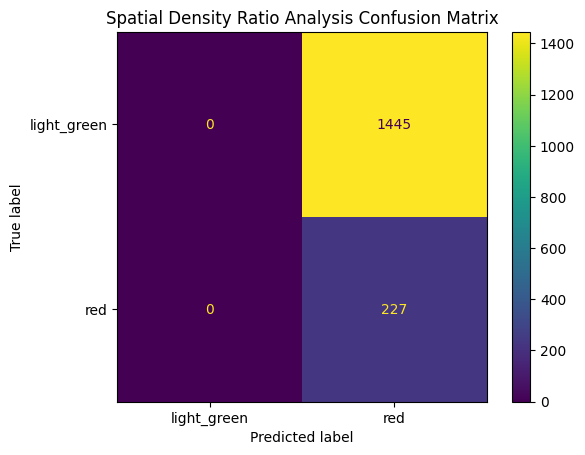

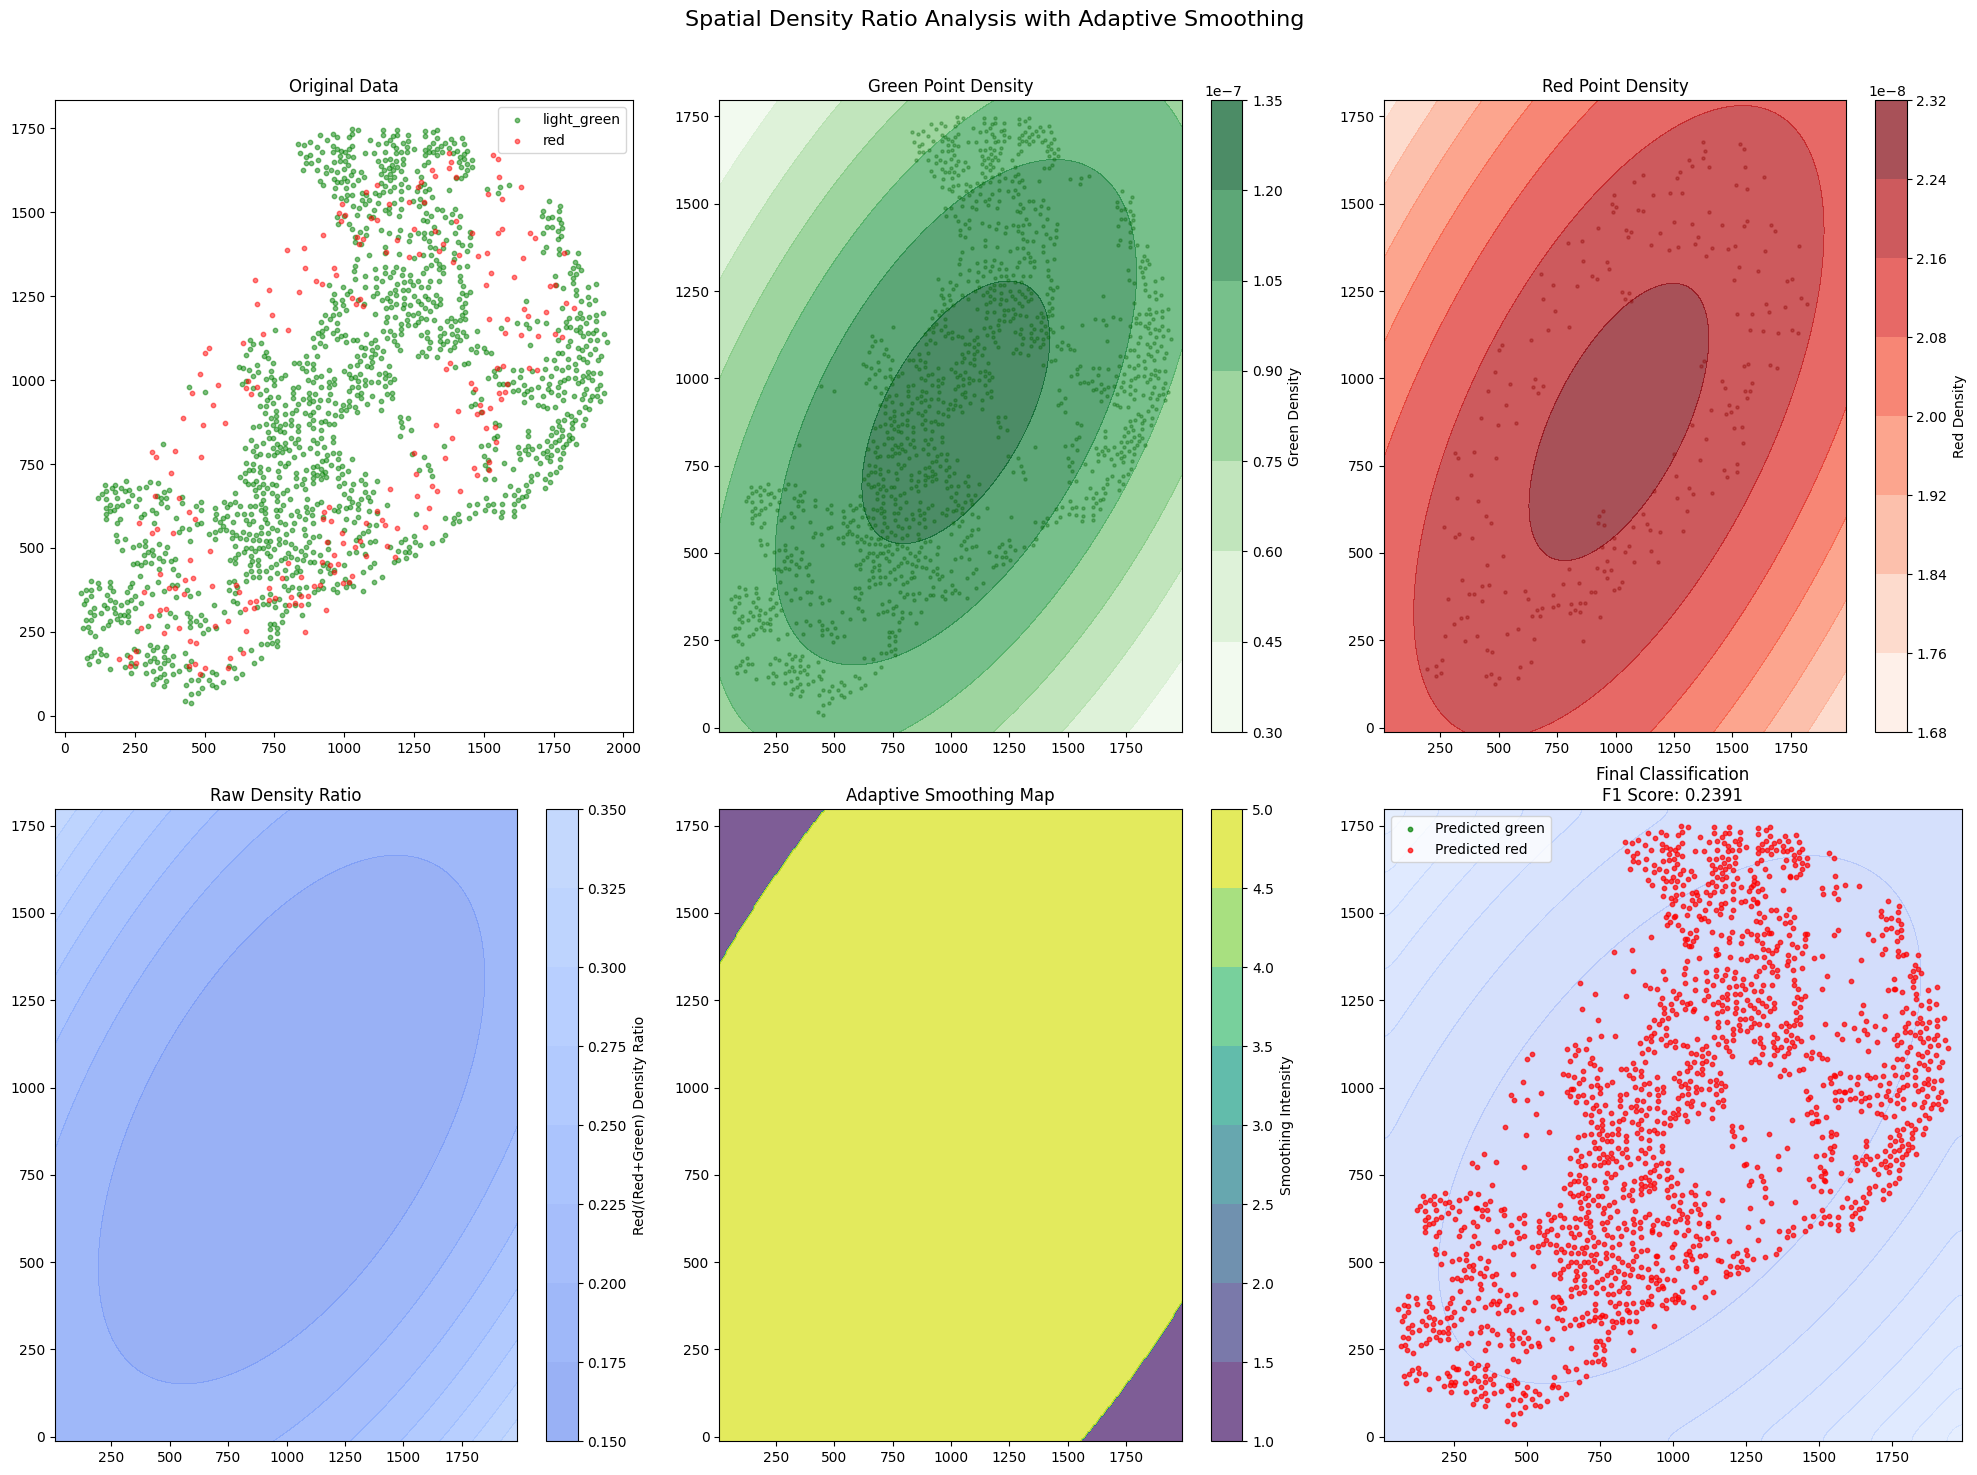

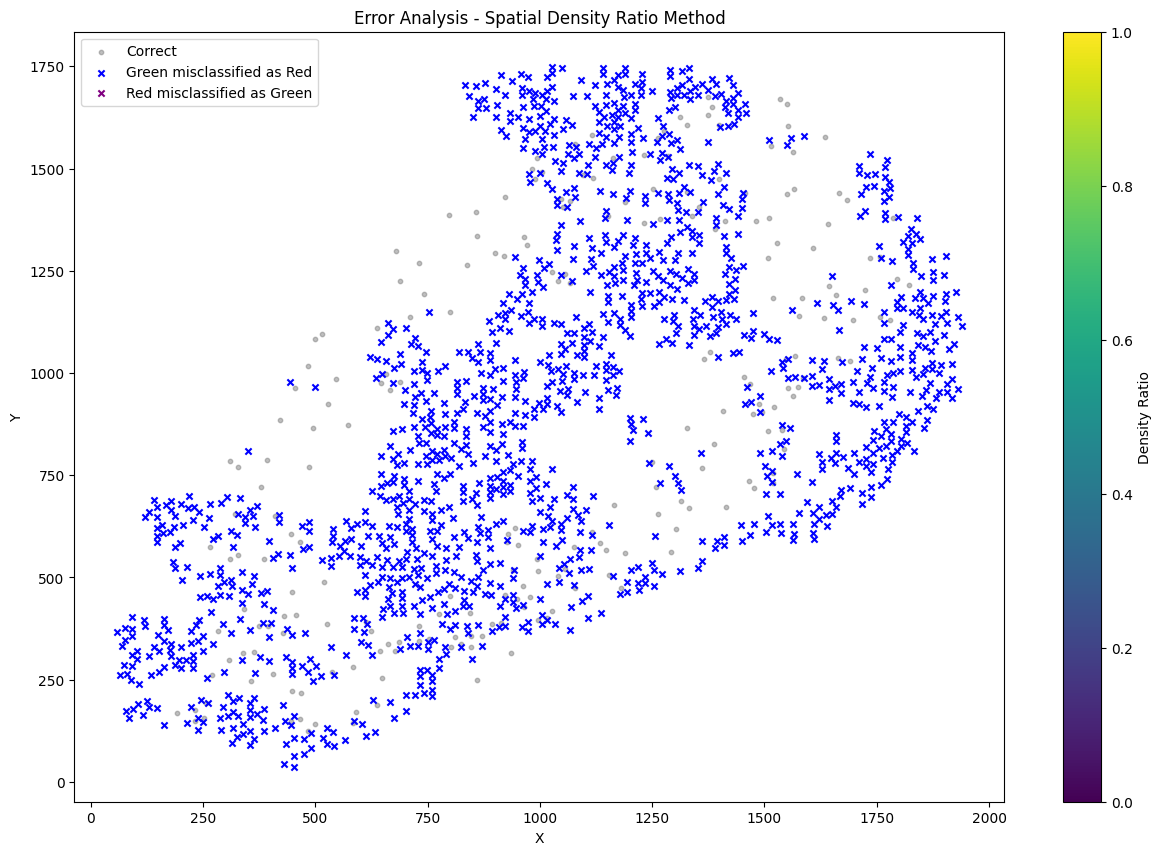

In [ ]:
# %% [code]
# 7. Spatial Density Ratio Analysis with Adaptive Smoothing - FIXED VERSION
print("\n===== Running Spatial Density Ratio Analysis with Adaptive Smoothing =====")

from scipy.stats import gaussian_kde
import scipy.ndimage as ndi
from sklearn.neighbors import NearestNeighbors

# Separate the data by color
X_green = X[y_true == 0]
X_red = X[y_true == 1]

# Calculate global density estimates
all_points = np.vstack([X_green, X_red])
x_min, x_max = all_points[:, 0].min() - 50, all_points[:, 0].max() + 50
y_min, y_max = all_points[:, 1].min() - 50, all_points[:, 1].max() + 50

# Create grid for density estimation
grid_resolution = 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_resolution),
                     np.arange(y_min, y_max, grid_resolution))
grid_points = np.vstack([xx.ravel(), yy.ravel()])

# Calculate density maps using adaptive bandwidths
print("Calculating density maps with adaptive bandwidths...")

# For green points
if len(X_green) > 0:
    # Calculate local density to determine adaptive bandwidth
    green_tree = NearestNeighbors(n_neighbors=min(10, len(X_green)))
    green_tree.fit(X_green)
    green_distances, _ = green_tree.kneighbors(X_green)
    median_distance_green = np.median(green_distances[:, -1])

    # Use adaptive bandwidth based on local density
    kde_green = gaussian_kde(X_green.T, bw_method=median_distance_green/20)
    dens_green = kde_green(grid_points)
else:
    dens_green = np.zeros_like(xx.ravel())

# For red points
if len(X_red) > 0:
    # Calculate local density to determine adaptive bandwidth
    red_tree = NearestNeighbors(n_neighbors=min(10, len(X_red)))
    red_tree.fit(X_red)
    red_distances, _ = red_tree.kneighbors(X_red)
    median_distance_red = np.median(red_distances[:, -1])

    # Use adaptive bandwidth based on local density
    kde_red = gaussian_kde(X_red.T, bw_method=median_distance_red/20)
    dens_red = kde_red(grid_points)
else:
    dens_red = np.zeros_like(xx.ravel())

# Reshape for grid operations
dens_green_grid = dens_green.reshape(xx.shape)
dens_red_grid = dens_red.reshape(xx.shape)

# Calculate density ratio with smoothing
print("Calculating density ratio with adaptive smoothing...")

# Create a mask for regions with sufficient data
total_density = dens_green_grid + dens_red_grid
sufficient_data = total_density > np.percentile(total_density, 5)
adaptive_smoothing = np.zeros_like(total_density)
adaptive_smoothing[sufficient_data] = 1.0 / np.sqrt(total_density[sufficient_data])
adaptive_smoothing = np.nan_to_num(adaptive_smoothing, nan=5.0, posinf=5.0, neginf=5.0)
adaptive_smoothing = np.clip(adaptive_smoothing, 1.0, 5.0)

# Calculate density ratio
density_ratio = np.zeros_like(dens_green_grid)
non_zero_mask = (dens_green_grid + dens_red_grid) > 1e-10
density_ratio[non_zero_mask] = dens_red_grid[non_zero_mask] / (dens_green_grid[non_zero_mask] + dens_red_grid[non_zero_mask])

# FIX: Instead of inefficient per-pixel filtering, use representative sigma
# Calculate a representative sigma value from the adaptive_smoothing map
valid_smoothing = adaptive_smoothing[adaptive_smoothing > 0]
if len(valid_smoothing) > 0:
    sigma_value = np.median(valid_smoothing)
else:
    sigma_value = 1.5  # Default value if no valid smoothing values

# Apply Gaussian filtering with the representative sigma
smoothed_ratio = ndi.gaussian_filter(density_ratio, sigma=sigma_value)

# Apply a small amount of global smoothing for coherence
final_ratio = ndi.gaussian_filter(smoothed_ratio, sigma=1.5)

# Convert back to point predictions with hysteresis thresholding
print("Converting to point predictions with hysteresis thresholding...")

# Interpolate the final ratio back to the original points
from scipy.interpolate import griddata
ratio_at_points = griddata((xx.ravel(), yy.ravel()), final_ratio.ravel(),
                          (X[:, 0], X[:, 1]), method='linear', fill_value=0.5)

# Use hysteresis thresholding for better edge preservation
high_threshold = 0.65
low_threshold = 0.35

# Step 1: Identify strong red regions
strong_red = ratio_at_points >= high_threshold
# Step 2: Identify strong green regions
strong_green = ratio_at_points <= (1 - high_threshold)
# Step 3: Identify weak regions that need connection analysis
weak_regions = ~strong_red & ~strong_green

# For weak regions, use connectivity to strong regions
mrf_pred = np.zeros(len(X), dtype=int)
mrf_pred[strong_red] = 1
mrf_pred[strong_green] = 0

# Create a graph for connectivity analysis in weak regions
if np.any(weak_regions):
    from scipy.spatial import KDTree
    tree = KDTree(X)

    # For each weak point, find its nearest strong point
    weak_indices = np.where(weak_regions)[0]
    for idx in weak_indices:
        # Find nearest strong point
        dist, nearest_idx = tree.query(X[idx], k=10)

        # Only consider strong points
        strong_mask = strong_red[nearest_idx] | strong_green[nearest_idx]
        if np.any(strong_mask):
            nearest_strong_idx = nearest_idx[strong_mask][0]
            mrf_pred[idx] = mrf_pred[nearest_strong_idx]
        else:
            # If no strong points nearby, use local majority
            mrf_pred[idx] = 1 if ratio_at_points[idx] > 0.5 else 0

# Evaluate the results
mrf_f1, mrf_pred_final = evaluate_clustering(y_true, mrf_pred, "Spatial Density Ratio Analysis")

# Visualize the process
plt.figure(figsize=(20, 15))

# 1. Original data
plt.subplot(2, 3, 1)
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='green', alpha=0.5, s=10, label='light_green')
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', alpha=0.5, s=10, label='red')
plt.title('Original Data')
plt.legend()

# 2. Green density map
plt.subplot(2, 3, 2)
plt.contourf(xx, yy, dens_green_grid, cmap='Greens', alpha=0.7)
plt.colorbar(label='Green Density')
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='darkgreen', alpha=0.3, s=5)
plt.title('Green Point Density')

# 3. Red density map
plt.subplot(2, 3, 3)
plt.contourf(xx, yy, dens_red_grid, cmap='Reds', alpha=0.7)
plt.colorbar(label='Red Density')
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='darkred', alpha=0.3, s=5)
plt.title('Red Point Density')

# 4. Density ratio map
plt.subplot(2, 3, 4)
plt.contourf(xx, yy, density_ratio, cmap='coolwarm', alpha=0.7, vmin=0, vmax=1)
plt.colorbar(label='Red/(Red+Green) Density Ratio')
plt.title('Raw Density Ratio')

# 5. Adaptive smoothing map
plt.subplot(2, 3, 5)
plt.contourf(xx, yy, adaptive_smoothing, cmap='viridis', alpha=0.7)
plt.colorbar(label='Smoothing Intensity')
plt.title('Adaptive Smoothing Map')

# 6. Final classification
plt.subplot(2, 3, 6)
plt.contourf(xx, yy, final_ratio, cmap='coolwarm', alpha=0.3, vmin=0, vmax=1)
plt.scatter(X[mrf_pred_final == 0, 0], X[mrf_pred_final == 0, 1], c='green', alpha=0.7, s=10, label='Predicted green')
plt.scatter(X[mrf_pred_final == 1, 0], X[mrf_pred_final == 1, 1], c='red', alpha=0.7, s=10, label='Predicted red')
plt.title(f'Final Classification\nF1 Score: {mrf_f1:.4f}')
plt.legend()

plt.tight_layout()
plt.suptitle('Spatial Density Ratio Analysis with Adaptive Smoothing', fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

# Error analysis
misclassified = (mrf_pred_final != y_true)
plt.figure(figsize=(15, 10))
plt.scatter(X[~misclassified, 0], X[~misclassified, 1], c='gray', alpha=0.5, s=10, label='Correct')
plt.scatter(X[misclassified & (y_true == 0), 0], X[misclassified & (y_true == 0), 1],
            c='blue', marker='x', s=20, label='Green misclassified as Red')
plt.scatter(X[misclassified & (y_true == 1), 0], X[misclassified & (y_true == 1), 1],
            c='purple', marker='x', s=20, label='Red misclassified as Green')
plt.title('Error Analysis - Spatial Density Ratio Method')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.colorbar(label='Density Ratio')
plt.show()

# Unsupervised method based on graph and hyperbolic geometry


===== Running Hyperbolic Graph-Based Clustering (Stable Numerical Implementation) =====
Creating k-NN graph from spatial data...


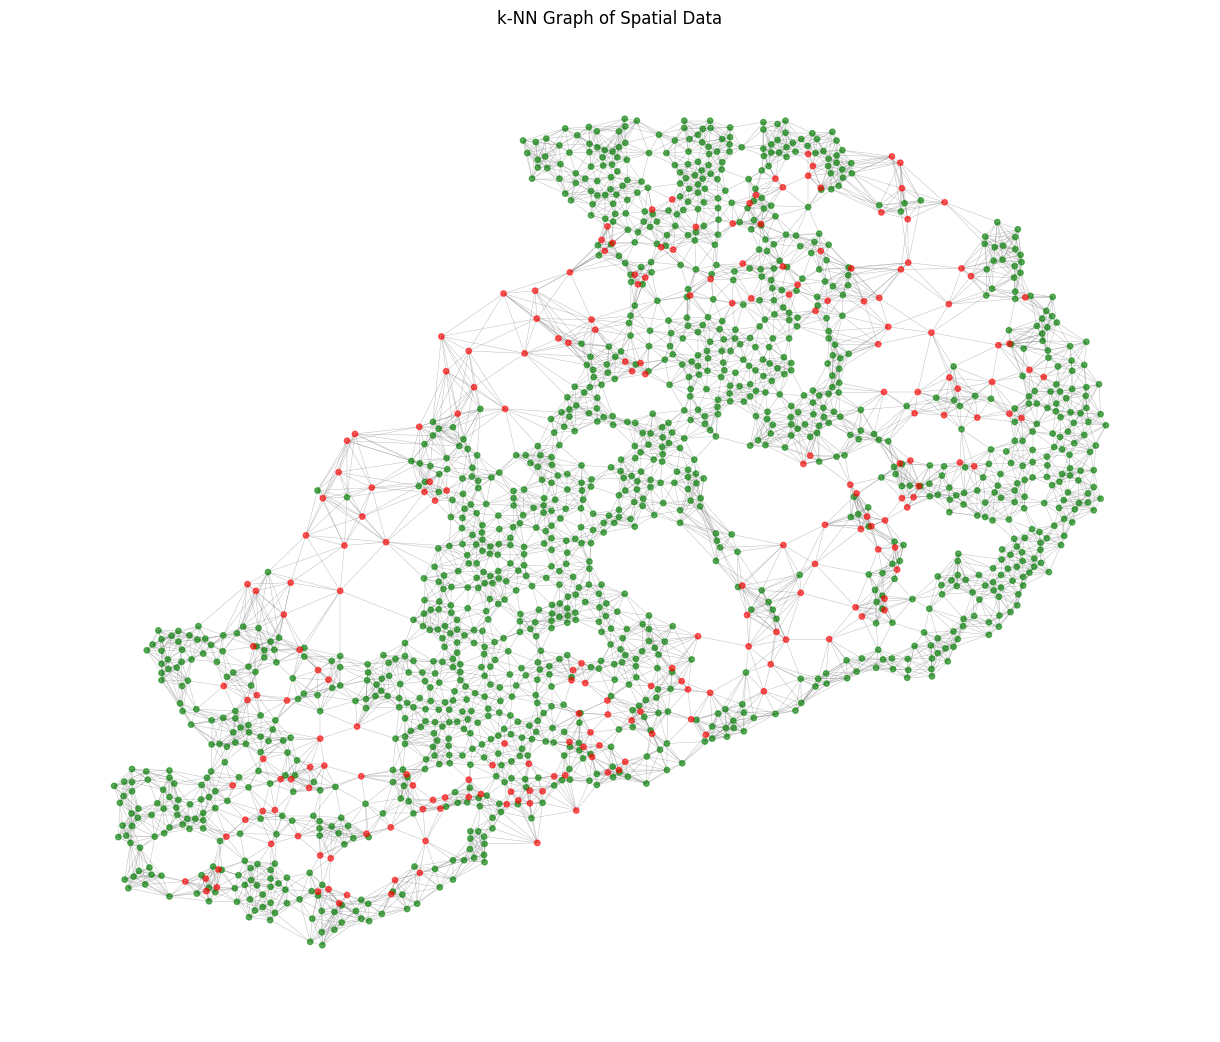

Mapping data to hyperbolic space using stable geometric transformation...
Maximum norm after mapping: 0.760000 (should be < 1.0)
Points near boundary (norm > 0.99): 0


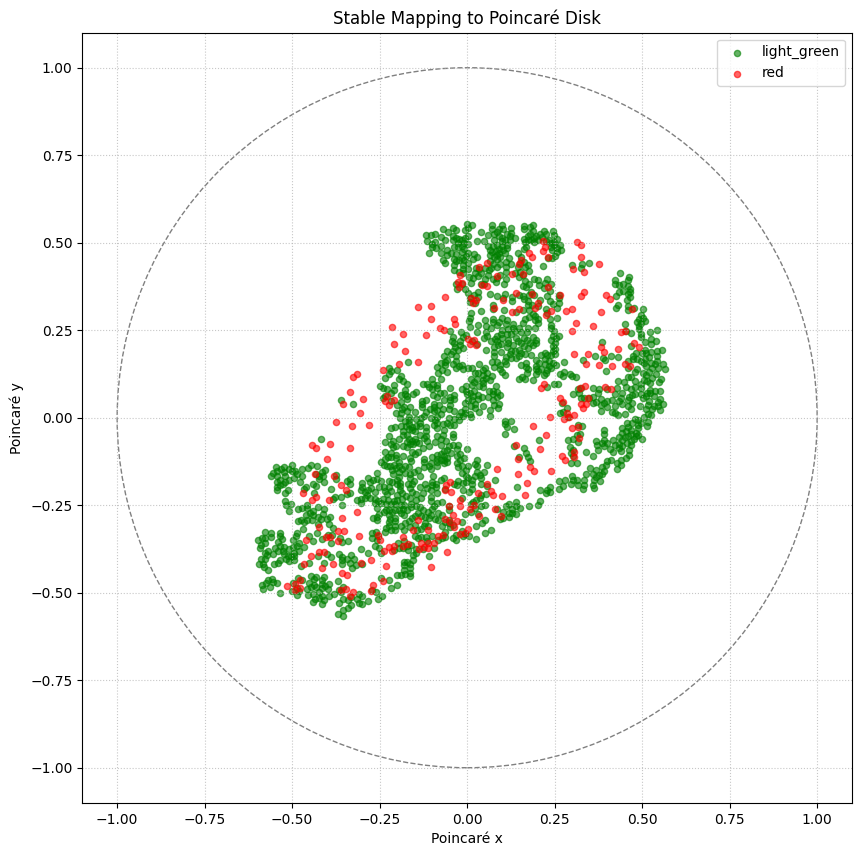

Performing clustering in hyperbolic space with extreme numerical safeguards...
Converged after 7 iterations

Hyperbolic Graph-Based Clustering (Stable) - F1 Score: 0.2187


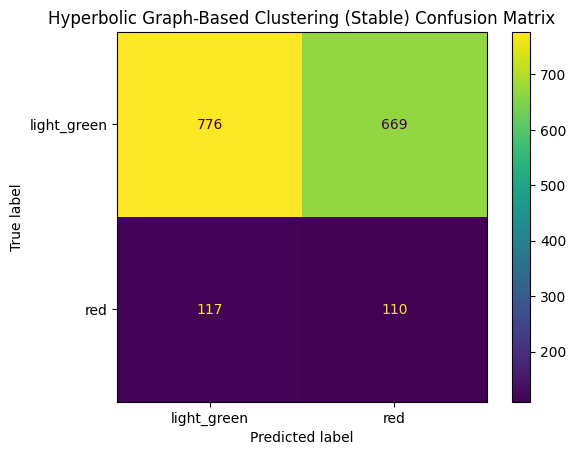

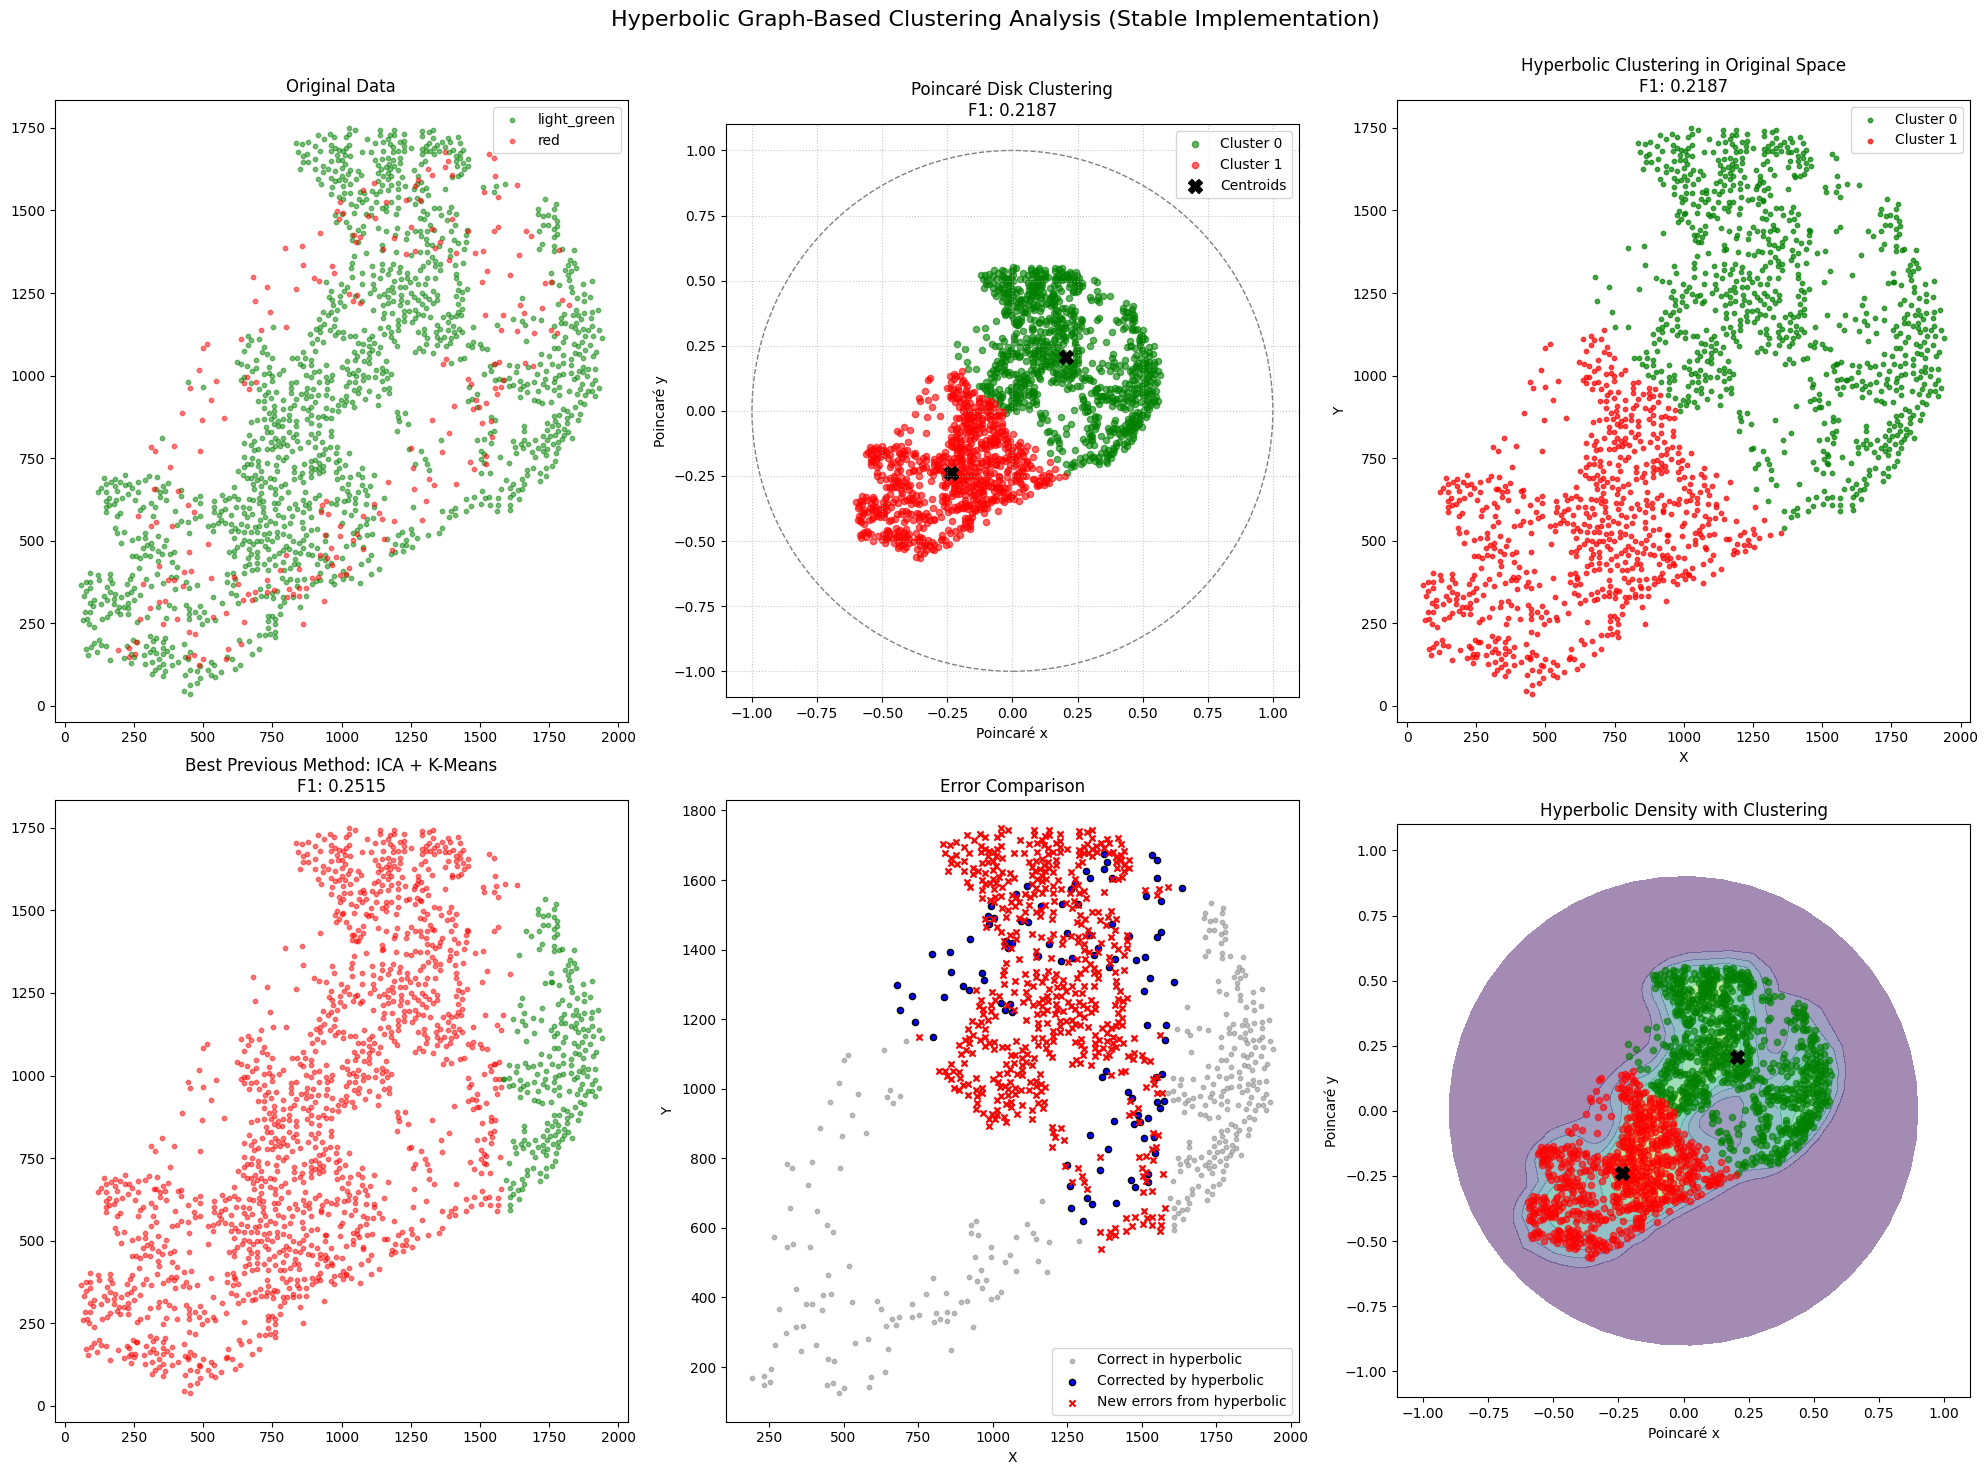

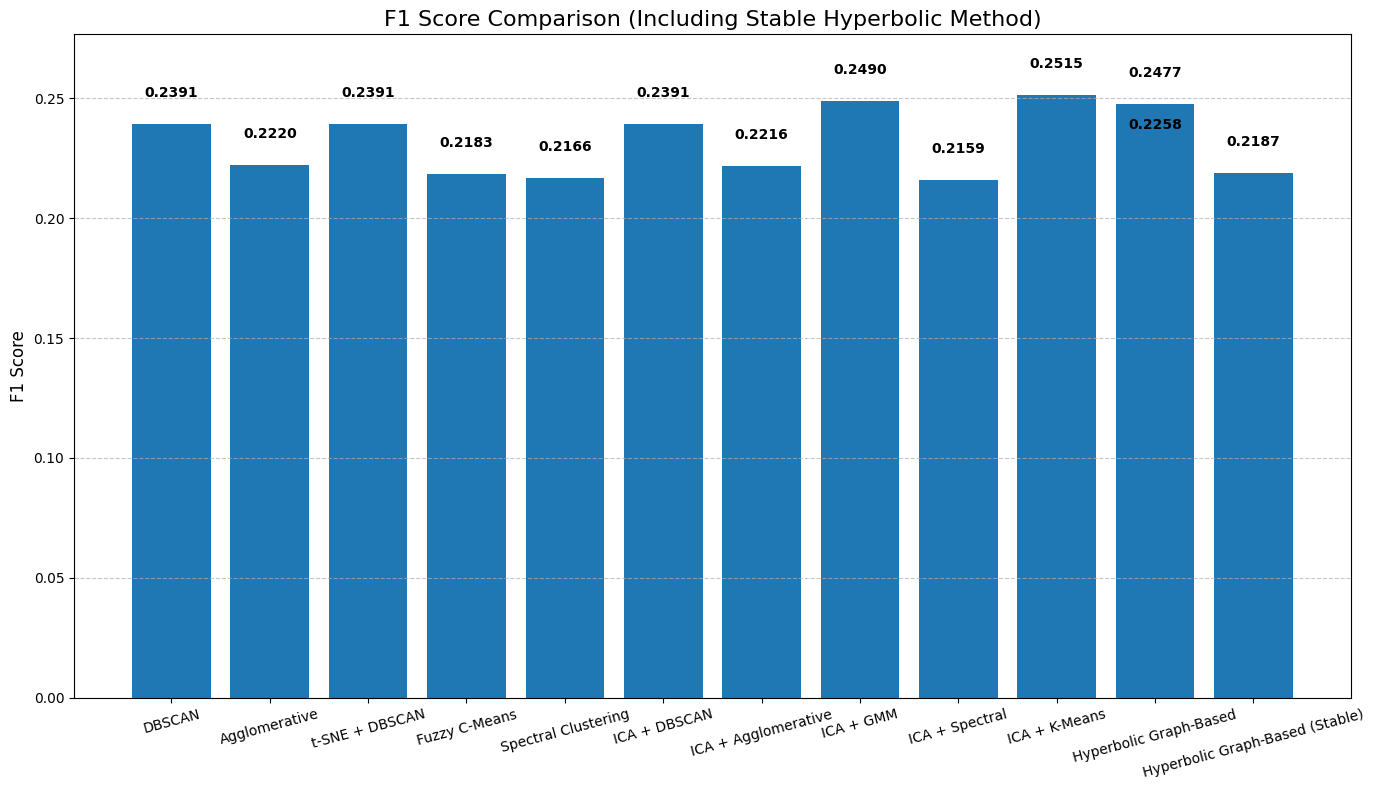

In [ ]:
# %% [code]
# 8. Hyperbolic Graph-Based Clustering - STABLE NUMERICAL IMPLEMENTATION
print("\n===== Running Hyperbolic Graph-Based Clustering (Stable Numerical Implementation) =====")

import networkx as nx
from sklearn.neighbors import kneighbors_graph
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Create a k-NN graph from the spatial data
print("Creating k-NN graph from spatial data...")
k = 10  # Number of neighbors - suitable for spatial data
graph = kneighbors_graph(X_scaled, n_neighbors=k, mode='distance', include_self=False)
graph = graph.tocoo()

# Convert to NetworkX graph
G = nx.Graph()
for i in range(len(X_scaled)):
    G.add_node(i)
for i, j, d in zip(graph.row, graph.col, graph.data):
    G.add_edge(i, j, weight=d)

# Visualize the graph structure
plt.figure(figsize=(12, 10))
pos = {i: X_scaled[i] for i in range(len(X_scaled))}  # Use the actual coordinates as positions
node_colors = ['green' if y_true[i] == 0 else 'red' for i in range(len(y_true))]

# Draw the graph
nx.draw(G, pos=pos, node_color=node_colors,
        with_labels=False, node_size=15,
        width=0.3, alpha=0.6, edge_color='gray')
plt.title('k-NN Graph of Spatial Data')
plt.xlabel('X (scaled)')
plt.ylabel('Y (scaled)')
plt.show()

# %% [code]
# STABLE HYPERBOLIC MAPPING FUNCTION
print("Mapping data to hyperbolic space using stable geometric transformation...")

def euclidean_to_poincare_stable(points, c=1.0, epsilon=1e-6):
    """
    Stable mapping from Euclidean space to Poincaré ball with buffer

    This implementation avoids numerical instability by:
    1. Using a controlled scaling factor
    2. Adding a buffer from the boundary
    3. Handling edge cases explicitly
    """
    # Normalize points to have max norm = 0.8 (well within boundary)
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    max_norm = np.max(norms)
    if max_norm > 0:
        # Scale all points so max norm is 0.8
        scale_factor = 0.8 / max_norm
        points = points * scale_factor
    else:
        # If all points are at origin (unlikely), spread them out slightly
        points = points + np.random.randn(*points.shape) * 0.1

    # Add buffer to keep points away from boundary
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    buffer_factor = 0.95  # Keep points at 95% of max allowed radius
    points = points * buffer_factor

    # Final check to ensure no points are at or beyond boundary
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    points = np.where(norms >= (1.0 - epsilon), points * (1.0 - 2*epsilon) / norms, points)

    return points

# Map the data to hyperbolic space using the stable transformation
poincare_embeddings = euclidean_to_poincare_stable(X_scaled, epsilon=1e-6)

# Verify the mapping produced valid points
norms = np.linalg.norm(poincare_embeddings, axis=1)
max_norm = np.max(norms)
print(f"Maximum norm after mapping: {max_norm:.6f} (should be < 1.0)")
print(f"Points near boundary (norm > 0.99): {np.sum(norms > 0.99)}")

# Visualize the mapped points in the Poincaré disk
plt.figure(figsize=(10, 10))
# Draw the unit circle (boundary of the Poincaré disk)
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray')
ax = plt.gca()
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')

# Plot the embeddings with true labels
plt.scatter(poincare_embeddings[y_true == 0, 0], poincare_embeddings[y_true == 0, 1],
            c='green', alpha=0.6, s=20, label='light_green')
plt.scatter(poincare_embeddings[y_true == 1, 0], poincare_embeddings[y_true == 1, 1],
            c='red', alpha=0.6, s=20, label='red')

plt.title('Stable Mapping to Poincaré Disk')
plt.xlabel('Poincaré x')
plt.ylabel('Poincaré y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# %% [code]
# HYPERBOLIC CLUSTERING WITH EXTREME NUMERICAL SAFEGUARDS
print("Performing clustering in hyperbolic space with extreme numerical safeguards...")

def hyperbolic_distance_stable(u, v, c=1.0, epsilon=1e-10):
    """
    Compute hyperbolic distance with multiple numerical safeguards

    This implementation:
    1. Projects points to safe region if needed
    2. Uses multiple clipping operations
    3. Handles edge cases explicitly
    4. Avoids operations that could cause overflow
    """
    # Make copies to avoid modifying inputs
    u = u.copy()
    v = v.copy()

    # Ensure points are within the ball with buffer
    u_norm = np.linalg.norm(u)
    v_norm = np.linalg.norm(v)

    # Project points inward if too close to boundary
    if u_norm >= 1 or v_norm >= 1:
        if u_norm >= 1:
            u = u * (0.9 - epsilon) / max(u_norm, epsilon)
        if v_norm >= 1:
            v = v * (0.9 - epsilon) / max(v_norm, epsilon)

    # Compute the distance with multiple safeguards
    norm_u = np.sum(u**2)
    norm_v = np.sum(v**2)
    sq_dist = np.sum((u - v)**2)

    # Add multiple layers of protection
    alpha = max(1 - c * norm_u, 1e-8)
    beta = max(1 - c * norm_v, 1e-8)

    # Ensure denominator doesn't get too small
    denominator = alpha * beta
    if denominator < 1e-15:
        denominator = 1e-15

    # Limit the value before division to prevent overflow
    ratio = min(sq_dist / denominator, 1e10)
    gamma = 1 + 2 * c * ratio

    # Ensure gamma is within valid range for acosh
    gamma = max(gamma, 1.0 + 1e-8)

    # Final safeguard against extremely large values
    if gamma > 1e10:
        return 20.0  # Cap the distance at a large but finite value

    return np.arccosh(gamma) / np.sqrt(c)

def hyperbolic_kmeans_stable(embeddings, n_clusters=2, max_iter=150, epsilon=1e-8):
    """K-means clustering in hyperbolic space with extreme numerical safeguards"""
    num_points = embeddings.shape[0]

    # Ensure we have enough unique points
    unique_indices = np.unique(embeddings.round(decimals=5), axis=0, return_index=True)[1]
    if len(unique_indices) < n_clusters:
        print(f"WARNING: Only {len(unique_indices)} unique points, but need {n_clusters} clusters.")
        # Fallback: spread points along x-axis with large separation
        centroids = np.zeros((n_clusters, embeddings.shape[1]))
        for i in range(n_clusters):
            centroids[i, 0] = -0.7 + 1.4 * i / (n_clusters - 1)
    else:
        # Select initial centroids from unique points
        idx = np.random.choice(unique_indices, n_clusters, replace=False)
        centroids = embeddings[idx].copy()

    labels = np.zeros(num_points)
    converged = False

    for iter in range(max_iter):
        # Assign points to nearest centroid (in hyperbolic space)
        for i in range(num_points):
            min_dist = float('inf')
            for j in range(n_clusters):
                try:
                    dist = hyperbolic_distance_stable(embeddings[i], centroids[j], epsilon=epsilon)
                    if dist < min_dist:
                        min_dist = dist
                        labels[i] = j
                except Exception as e:
                    # Fallback to Euclidean distance if hyperbolic fails
                    eucl_dist = np.linalg.norm(embeddings[i] - centroids[j])
                    if eucl_dist < min_dist:
                        min_dist = eucl_dist
                        labels[i] = j

        # Update centroids with multiple safeguards
        old_centroids = centroids.copy()
        for j in range(n_clusters):
            cluster_points = embeddings[labels == j]
            if len(cluster_points) > 0:
                # Simple approach: take the Euclidean mean and project to the ball
                centroid = np.mean(cluster_points, axis=0)
                norm = np.linalg.norm(centroid)

                # Project to safe region with buffer
                if norm >= 1:
                    centroid = centroid * 0.85 / max(norm, epsilon)

                # Final check for NaN/Inf
                if np.isnan(centroid).any() or np.isinf(centroid).any():
                    # Use median instead of mean if mean produced invalid values
                    centroid = np.median(cluster_points, axis=0)
                    norm = np.linalg.norm(centroid)
                    if norm >= 1:
                        centroid = centroid * 0.85 / max(norm, epsilon)

                centroids[j] = centroid
            else:
                # Empty cluster - reinitialize with better strategy
                print(f"WARNING: Cluster {j} became empty. Reinitializing...")
                # Find the point farthest from all current centroids
                max_dist = -1
                new_centroid_idx = 0
                for i in range(num_points):
                    min_dist = float('inf')
                    for k in range(n_clusters):
                        if k == j:
                            continue
                        try:
                            dist = hyperbolic_distance_stable(embeddings[i], centroids[k], epsilon=epsilon)
                            if dist < min_dist:
                                min_dist = dist
                        except:
                            dist = np.linalg.norm(embeddings[i] - centroids[k])
                            if dist < min_dist:
                                min_dist = dist
                    if min_dist > max_dist:
                        max_dist = min_dist
                        new_centroid_idx = i
                centroids[j] = embeddings[new_centroid_idx]

        # Check for convergence with tight tolerance
        if np.all(np.linalg.norm(old_centroids - centroids, axis=1) < 1e-10):
            converged = True
            print(f"Converged after {iter+1} iterations")
            break

    return labels, centroids

# Perform hyperbolic k-means clustering with extreme safeguards
hyperbolic_labels, hyperbolic_centroids = hyperbolic_kmeans_stable(poincare_embeddings, n_clusters=2, epsilon=1e-8)

# Evaluate the clustering results
def evaluate_clustering(y_true, y_pred, title):
    """Evaluate clustering results by mapping cluster labels to true labels and computing F1 score."""
    # Since clustering doesn't guarantee which cluster corresponds to which class,
    # we need to map the cluster labels to the true labels
    # We'll try both possible mappings and choose the one with better F1 score

    # Option 1: cluster 0 -> class 0, cluster 1 -> class 1
    y_pred_mapped1 = y_pred.copy()

    # Option 2: cluster 0 -> class 1, cluster 1 -> class 0
    y_pred_mapped2 = 1 - y_pred

    # Calculate F1 scores for both mappings
    f1_1 = f1_score(y_true, y_pred_mapped1, zero_division=0)
    f1_2 = f1_score(y_true, y_pred_mapped2, zero_division=0)

    # Choose the mapping with higher F1 score
    if f1_1 >= f1_2:
        y_pred_final = y_pred_mapped1
        f1 = f1_1
    else:
        y_pred_final = y_pred_mapped2
        f1 = f1_2

    print(f"\n{title} - F1 Score: {f1:.4f}")

    # Plot confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(y_true, y_pred_final)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["light_green", "red"])
    disp.plot()
    plt.title(f"{title} Confusion Matrix")
    plt.show()

    return f1, y_pred_final

hyperbolic_f1, hyperbolic_pred = evaluate_clustering(y_true, hyperbolic_labels, "Hyperbolic Graph-Based Clustering (Stable)")

# %% [code]
# Visualize the clustering results in both hyperbolic and original spaces
plt.figure(figsize=(20, 15))

# 1. Original data
plt.subplot(2, 3, 1)
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='green', alpha=0.5, s=10, label='light_green')
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', alpha=0.5, s=10, label='red')
plt.title('Original Data')
plt.legend()

# 2. Poincaré disk with clustering results
plt.subplot(2, 3, 2)
# Draw the unit circle
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray')
ax = plt.gca()
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')

# Plot the embeddings with cluster labels
plt.scatter(poincare_embeddings[hyperbolic_pred == 0, 0], poincare_embeddings[hyperbolic_pred == 0, 1],
            c='green', alpha=0.6, s=20, label='Cluster 0')
plt.scatter(poincare_embeddings[hyperbolic_pred == 1, 0], poincare_embeddings[hyperbolic_pred == 1, 1],
            c='red', alpha=0.6, s=20, label='Cluster 1')

# Plot centroids
plt.scatter(hyperbolic_centroids[:, 0], hyperbolic_centroids[:, 1],
            c='black', marker='X', s=100, label='Centroids')

plt.title(f'Poincaré Disk Clustering\nF1: {hyperbolic_f1:.4f}')
plt.xlabel('Poincaré x')
plt.ylabel('Poincaré y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 3. Original space with hyperbolic clustering results
plt.subplot(2, 3, 3)
plt.scatter(X[hyperbolic_pred == 0, 0], X[hyperbolic_pred == 0, 1], c='green', alpha=0.7, s=10, label='Cluster 0')
plt.scatter(X[hyperbolic_pred == 1, 0], X[hyperbolic_pred == 1, 1], c='red', alpha=0.7, s=10, label='Cluster 1')
plt.title(f'Hyperbolic Clustering in Original Space\nF1: {hyperbolic_f1:.4f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# 4. Compare with best previous method
best_idx = np.argmax(f1_scores)
best_method = methods[best_idx]
best_score = f1_scores[best_idx]

if best_method == 'DBSCAN':
    best_pred = dbscan_pred
elif best_method == 'Agglomerative':
    best_pred = agg_pred
elif best_method == 'Fuzzy C-Means' and 'fcm_f1' in locals() and fcm_f1 is not None:
    best_pred = fcm_pred
elif best_method == 't-SNE + DBSCAN':
    best_pred = tsne_pred
elif best_method == 'Spectral Clustering':
    best_pred = spectral_pred
elif best_method == 'ICA + DBSCAN':
    best_pred = ica_dbscan_pred
elif best_method == 'ICA + Agglomerative':
    best_pred = ica_agg_pred
elif best_method == 'ICA + GMM':
    best_pred = ica_gmm_pred
elif best_method == 'ICA + Spectral':
    best_pred = ica_spectral_pred
else:  # 'ICA + K-Means'
    best_pred = ica_kmeans_pred

plt.subplot(2, 3, 4)
plt.scatter(X[best_pred == 0, 0], X[best_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[best_pred == 1, 0], X[best_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Best Previous Method: {best_method}\nF1: {best_score:.4f}')

# 5. Error comparison
plt.subplot(2, 3, 5)
misclassified_hyperbolic = (hyperbolic_pred != y_true)
misclassified_best = (best_pred != y_true)

plt.scatter(X[~misclassified_hyperbolic, 0], X[~misclassified_hyperbolic, 1],
            c='gray', alpha=0.5, s=10, label='Correct in hyperbolic')
plt.scatter(X[misclassified_hyperbolic & ~misclassified_best, 0], X[misclassified_hyperbolic & ~misclassified_best, 1],
            c='blue', marker='o', s=20, edgecolor='black', label=f'Corrected by hyperbolic')
plt.scatter(X[~misclassified_hyperbolic & misclassified_best, 0], X[~misclassified_hyperbolic & misclassified_best, 1],
            c='red', marker='x', s=20, label=f'New errors from hyperbolic')
plt.title('Error Comparison')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# 6. Hyperbolic clustering with density visualization - EXTREMELY STABLE
plt.subplot(2, 3, 6)
# Calculate density in hyperbolic space with extreme safeguards
try:
    from scipy.stats import gaussian_kde

    # Check if embeddings are valid
    if np.isnan(poincare_embeddings).any() or np.isinf(poincare_embeddings).any():
        raise ValueError("Embeddings contain NaN or Inf values")

    # Create a safe grid well within the disk
    r = np.linspace(0, 0.9, 50)
    theta = np.linspace(0, 2*np.pi, 50)
    rr, ttheta = np.meshgrid(r, theta)
    xy = np.column_stack([rr.ravel() * np.cos(ttheta.ravel()),
                          rr.ravel() * np.sin(ttheta.ravel())])

    # Try multiple approaches to density estimation
    try:
        # First try: standard KDE with bandwidth adjustment
        kde = gaussian_kde(poincare_embeddings.T, bw_method=0.2)
        dens = kde(xy.T)
        dens = dens.reshape(rr.shape)
    except:
        try:
            # Second try: histogram-based density
            hist, xedges, yedges = np.histogram2d(
                poincare_embeddings[:, 0],
                poincare_embeddings[:, 1],
                bins=20,
                range=[[-1, 1], [-1, 1]]
            )
            hist = hist / np.sum(hist)

            # Interpolate to grid
            from scipy.interpolate import griddata
            dens = griddata(
                (0.5*(xedges[1:]+xedges[:-1]), 0.5*(yedges[1:]+yedges[:-1])),
                hist.ravel(),
                (rr * np.cos(ttheta), rr * np.sin(ttheta)),
                method='linear',
                fill_value=np.mean(hist)
            )
            dens = dens.reshape(rr.shape)
        except:
            # Final fallback: uniform density
            dens = np.ones_like(rr) / np.prod(rr.shape)

    # Plot density
    plt.contourf(rr * np.cos(ttheta), rr * np.sin(ttheta), dens,
                 cmap='viridis', alpha=0.5)
except Exception as e:
    print(f"WARNING: Density visualization failed ({str(e)}). Using simplified visualization.")
    # Simplified visualization without density
    plt.scatter(poincare_embeddings[hyperbolic_pred == 0, 0], poincare_embeddings[hyperbolic_pred == 0, 1],
                c='green', alpha=0.6, s=20)
    plt.scatter(poincare_embeddings[hyperbolic_pred == 1, 0], poincare_embeddings[hyperbolic_pred == 1, 1],
                c='red', alpha=0.6, s=20)

plt.scatter(poincare_embeddings[hyperbolic_pred == 0, 0], poincare_embeddings[hyperbolic_pred == 0, 1],
            c='green', alpha=0.6, s=20)
plt.scatter(poincare_embeddings[hyperbolic_pred == 1, 0], poincare_embeddings[hyperbolic_pred == 1, 1],
            c='red', alpha=0.6, s=20)
plt.scatter(hyperbolic_centroids[:, 0], hyperbolic_centroids[:, 1],
            c='black', marker='X', s=100)

# Draw the unit circle
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='white')
ax = plt.gca()
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
plt.title('Hyperbolic Density with Clustering')
plt.xlabel('Poincaré x')
plt.ylabel('Poincaré y')

plt.tight_layout()
plt.suptitle('Hyperbolic Graph-Based Clustering Analysis (Stable Implementation)', fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

# %% [code]
# Compare with all previous methods
methods.append('Hyperbolic Graph-Based (Stable)')
f1_scores.append(hyperbolic_f1)

plt.figure(figsize=(14, 8))
bars = plt.bar(methods, f1_scores)
plt.title('F1 Score Comparison (Including Stable Hyperbolic Method)', fontsize=16)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, max(f1_scores) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{f1_scores[i]:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Graph + t-SNE edges and Poincare ball

### Exploring Hyperbolic Transformations: Moving a Red Point Closer to the Poincaré Ball Border

This section demonstrates how to manually transform a specific point in the Poincaré disk to bring it closer to the boundary (where the norm approaches 1). This can be useful for understanding the effects of hyperbolic transformations or for specific applications where points need to be positioned at certain distances from the origin or boundary.

Applying transformation to all red points...
Transformation applied. All red points now scaled to a target norm of 0.99.


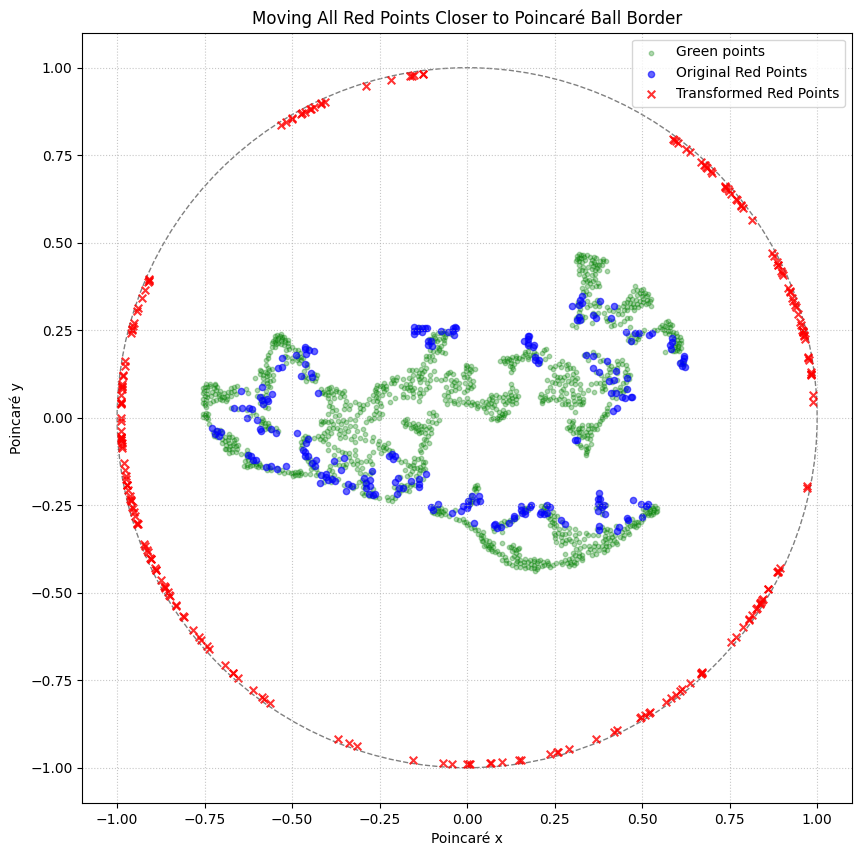


Sample of norms for transformed red points:
  Red point 1445: Original norm=0.5356, Transformed norm=0.9900
  Red point 1446: Original norm=0.6273, Transformed norm=0.9900
  Red point 1447: Original norm=0.6284, Transformed norm=0.9900
  Red point 1448: Original norm=0.2539, Transformed norm=0.9900
  Red point 1449: Original norm=0.3485, Transformed norm=0.9900


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Identify all red points from the existing poincare_embeddings
red_indices = np.where(y_true == 1)[0] # y_true is the original label for red points

if len(red_indices) > 0:
    # 2. Define a target norm closer to the boundary (but still < 1)
    target_norm = 0.99  # e.g., move it to 99% of the radius

    # Create a copy of poincare_embeddings to store transformed points
    transformed_poincare_embeddings = poincare_embeddings.copy()

    print("Applying transformation to all red points...")
    for idx in red_indices:
        original_red_point_hyp = poincare_embeddings[idx]
        original_norm = np.linalg.norm(original_red_point_hyp)

        if original_norm > 1e-8: # Avoid division by zero if point is at origin
            scaling_factor = target_norm / original_norm
            transformed_poincare_embeddings[idx] = original_red_point_hyp * scaling_factor
        else:
            # If at origin, leave unchanged or move slightly
            transformed_poincare_embeddings[idx] = original_red_point_hyp # No change if at origin

    print(f"Transformation applied. All red points now scaled to a target norm of {target_norm}.")

    # 3. Visualize the original and transformed points on the Poincaré disk
    plt.figure(figsize=(10, 10))
    circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray')
    ax = plt.gca()
    ax.add_patch(circle)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')

    # Plot all green points for context
    green_indices = np.where(y_true == 0)[0]
    plt.scatter(poincare_embeddings[green_indices, 0], poincare_embeddings[green_indices, 1],
                c='green', alpha=0.3, s=10, label='Green points')

    # Plot original red points
    plt.scatter(poincare_embeddings[red_indices, 0], poincare_embeddings[red_indices, 1],
                c='blue', marker='o', s=20, alpha=0.6, label='Original Red Points')

    # Plot transformed red points
    plt.scatter(transformed_poincare_embeddings[red_indices, 0], transformed_poincare_embeddings[red_indices, 1],
                c='red', marker='x', s=30, alpha=0.8, label='Transformed Red Points')

    plt.title('Moving All Red Points Closer to Poincaré Ball Border')
    plt.xlabel('Poincaré x')
    plt.ylabel('Poincaré y')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

    # Optional: Display norms of a few transformed red points
    print("\nSample of norms for transformed red points:")
    for i in range(min(5, len(red_indices))):
        idx = red_indices[i]
        print(f"  Red point {idx}: Original norm={np.linalg.norm(poincare_embeddings[idx]):.4f}, Transformed norm={np.linalg.norm(transformed_poincare_embeddings[idx]):.4f}")

else:
    print("No red points found in the dataset to demonstrate the transformation.")



===== Running Hyperbolic Graph Convolution Network with t-SNE Edge Construction =====
Using device: cpu
Computing t-SNE embedding and extracting similarity matrix...


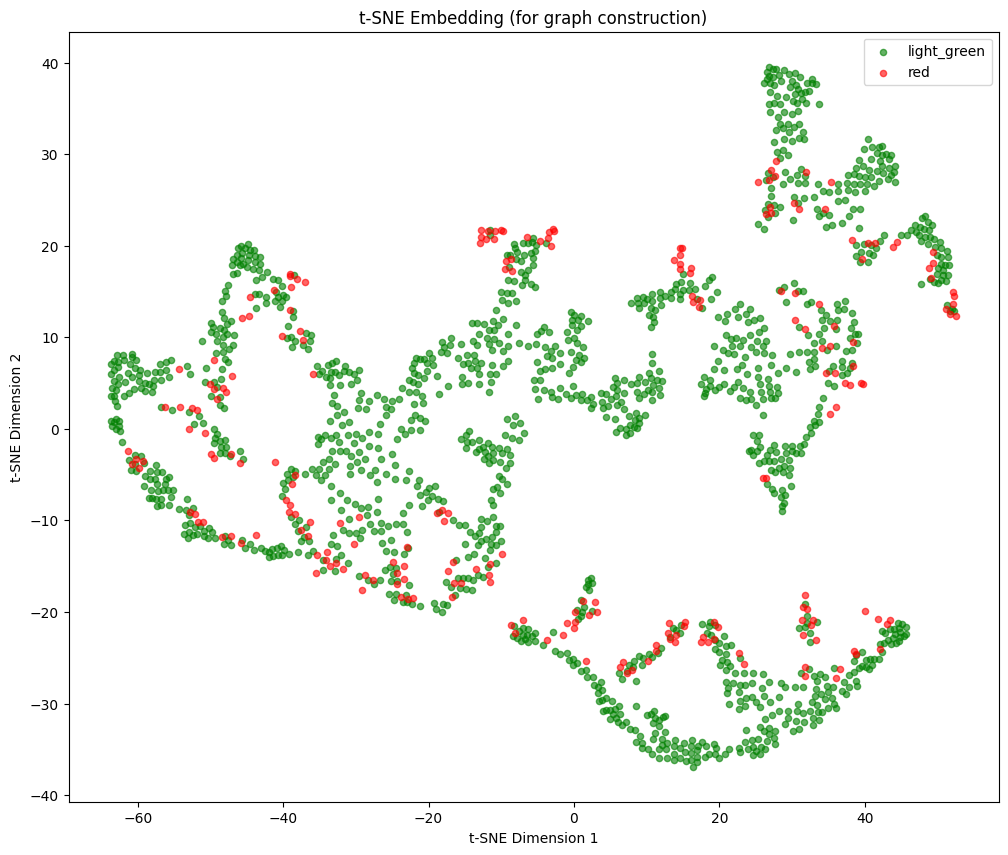

Creating graph from t-SNE similarity matrix...


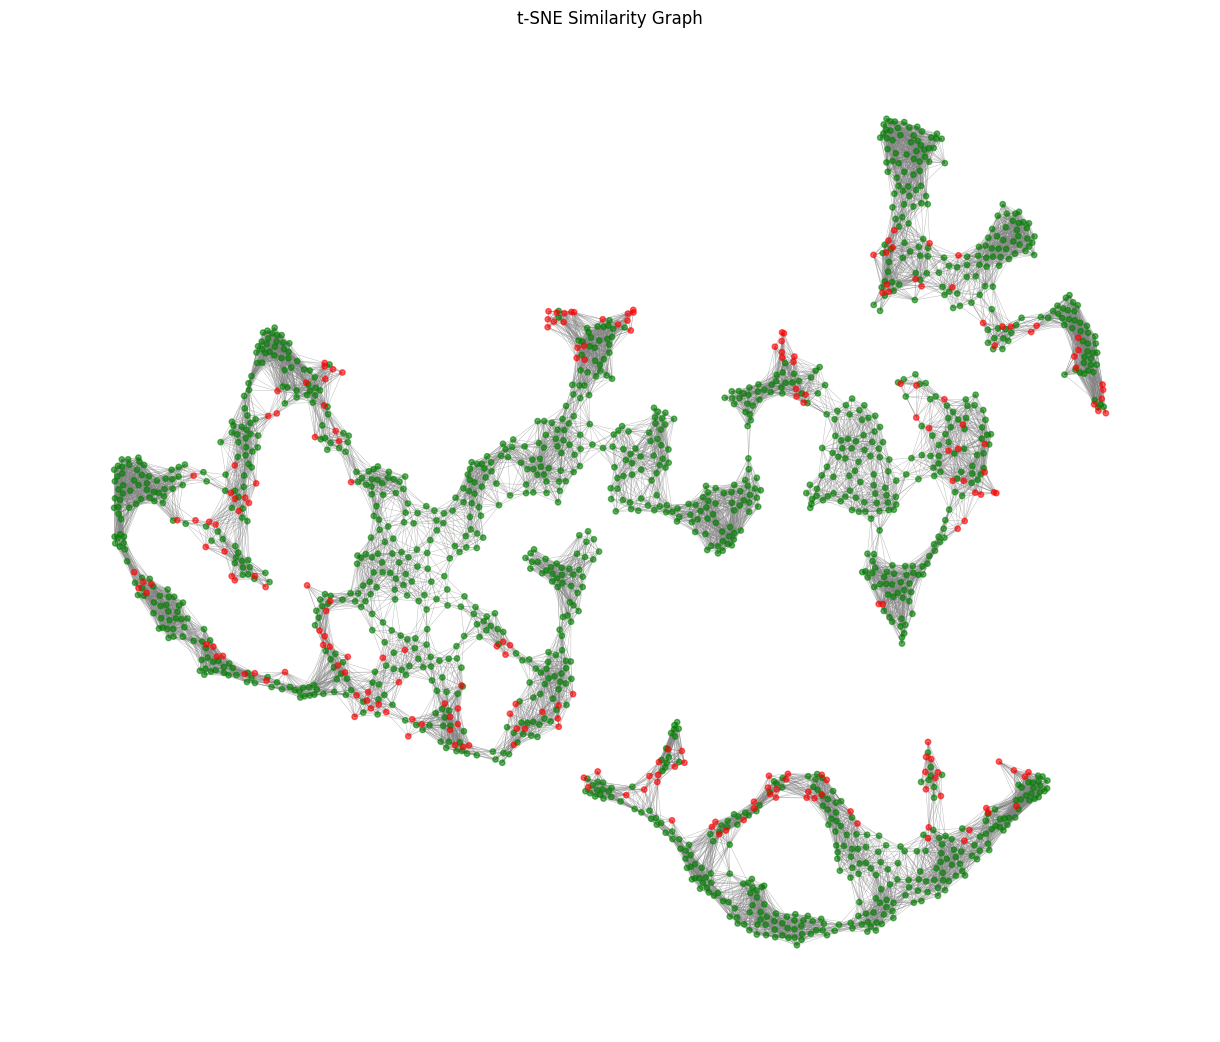

Mapping to hyperbolic Poincaré ball...
Maximum norm after mapping: 0.760000 (should be < 1.0)
Points near boundary (norm > 0.99): 0


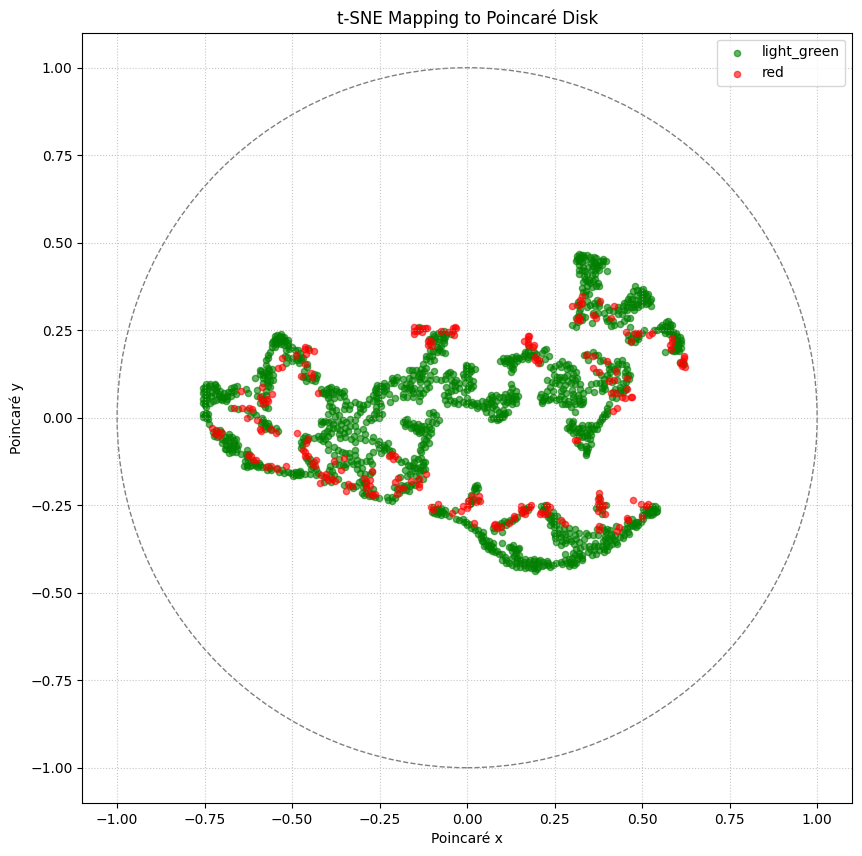

Implementing Hyperbolic Graph Convolution Layer...
Training Hyperbolic GCN for clustering...


100%|██████████| 200/200 [10:03<00:00,  3.02s/it]


Maximum norm of final embeddings: 0.417554
Clustering the final embeddings...

Hyperbolic GCN with t-SNE Edges - F1 Score: 0.2182


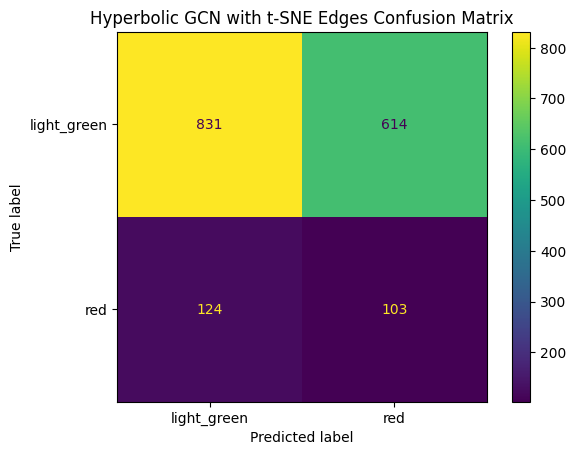

Visualizing results...


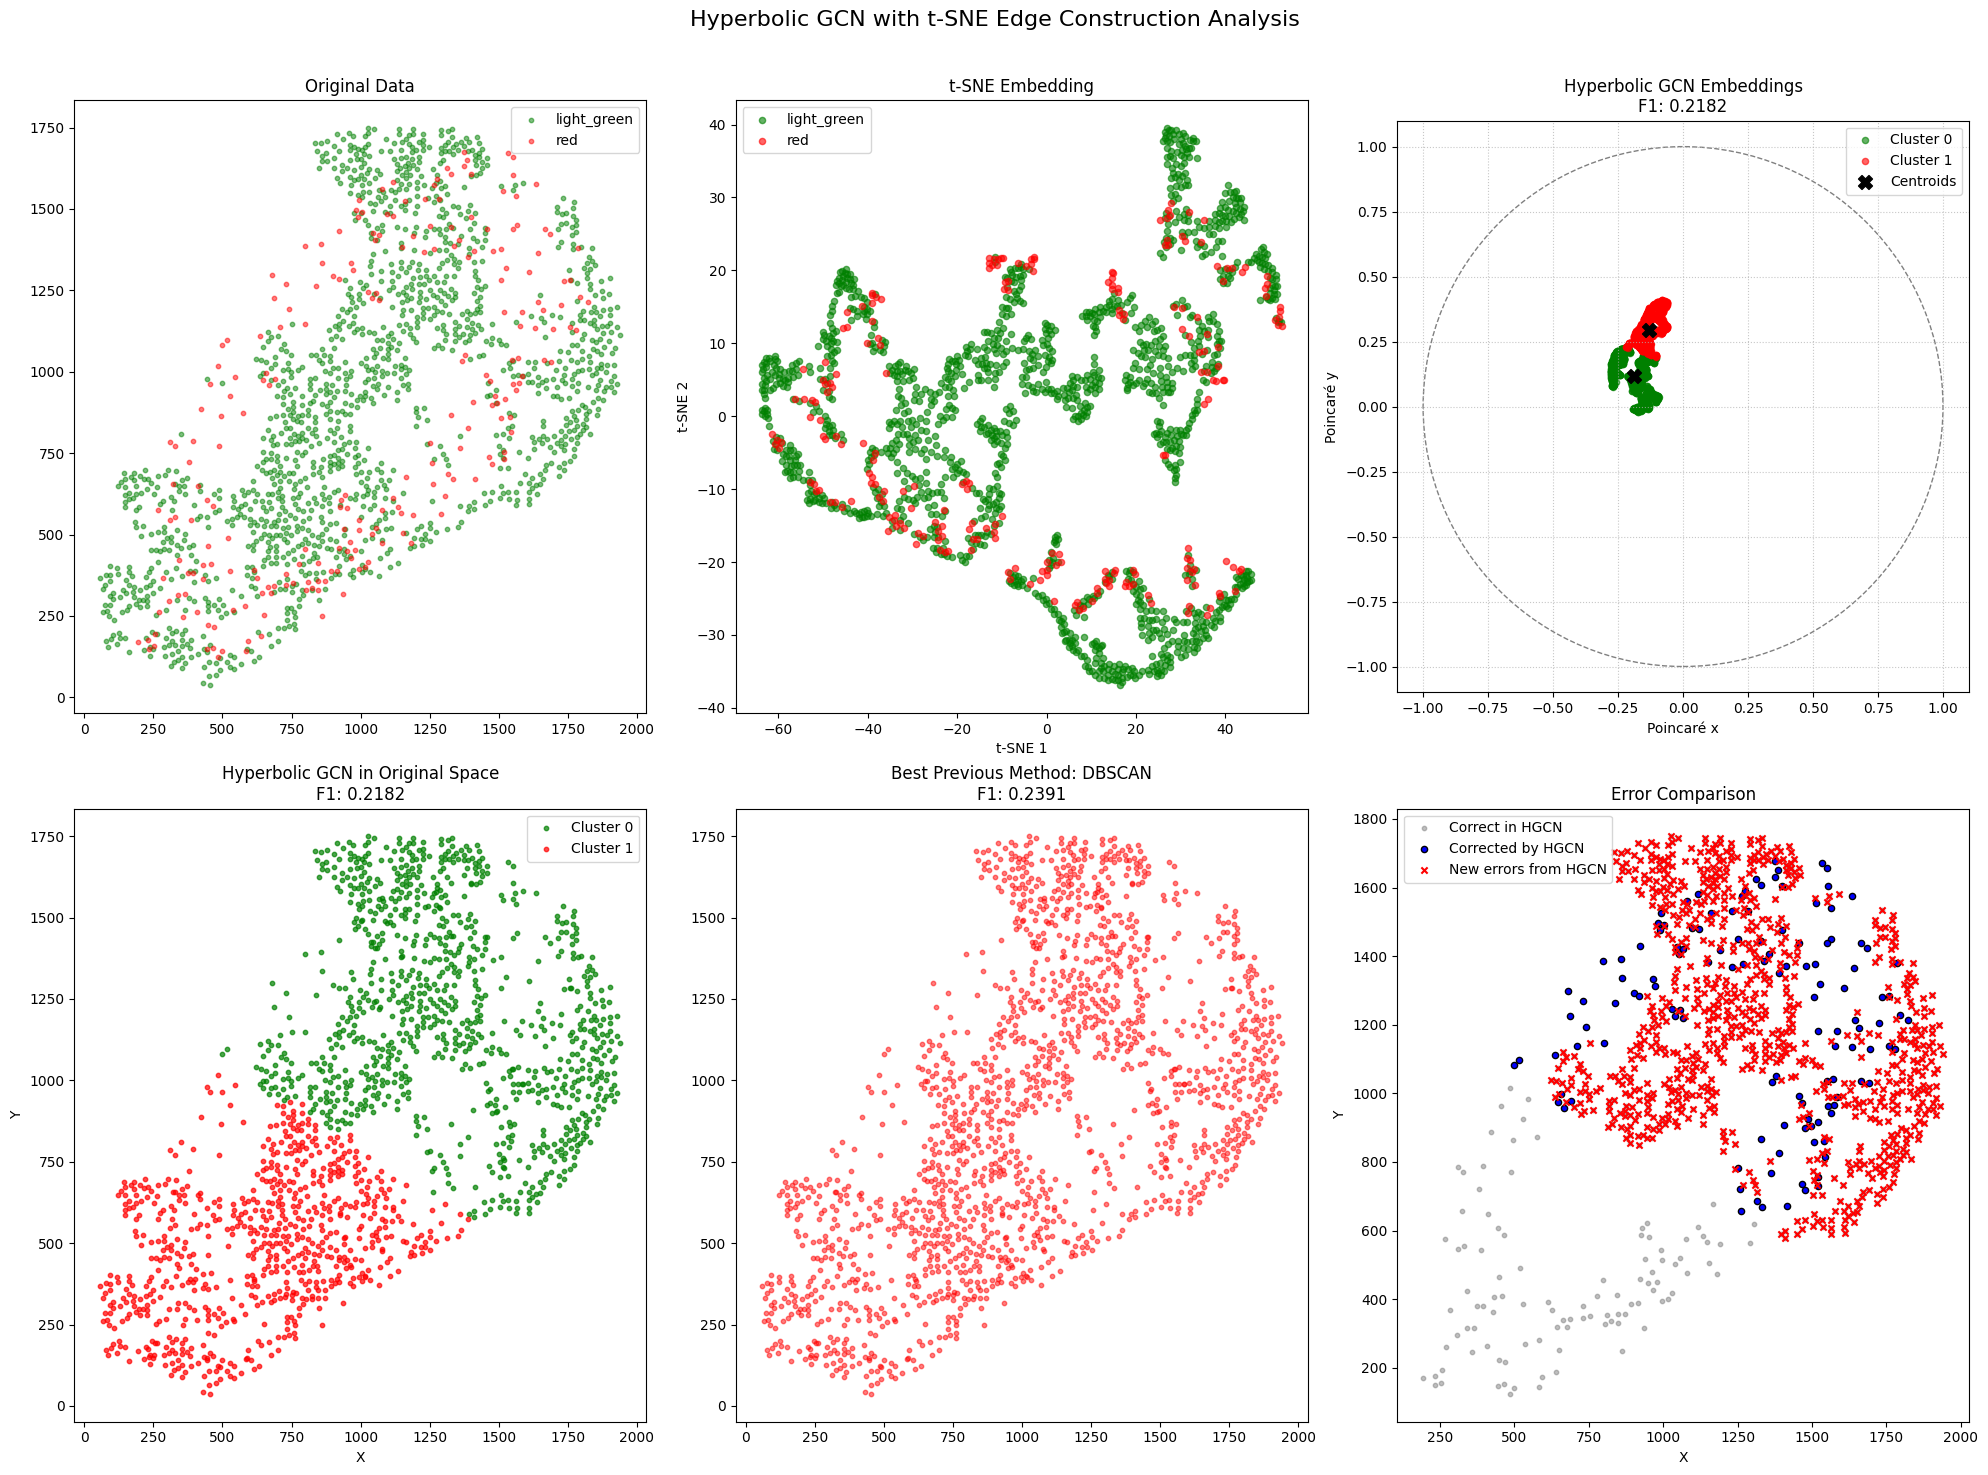

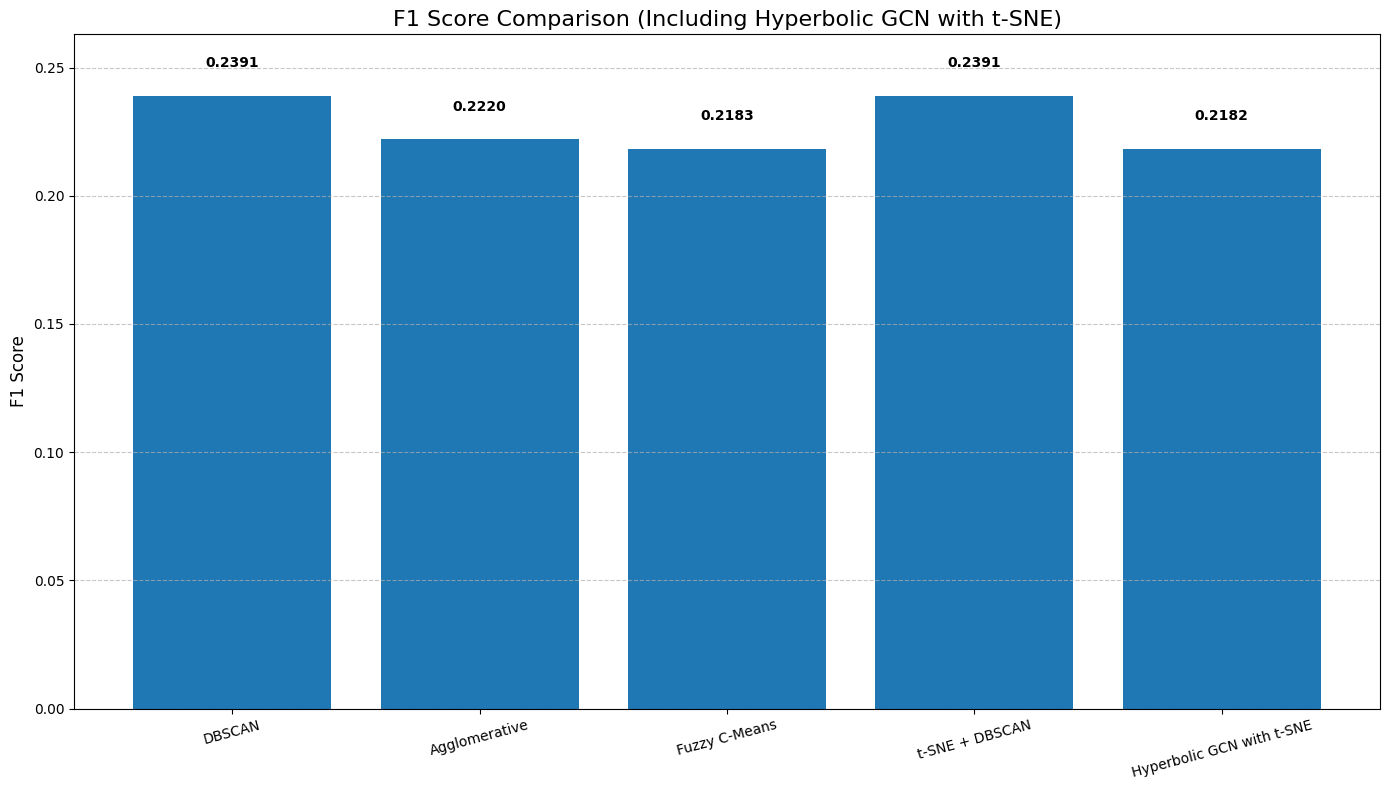

In [16]:
# %% [code]
# 9. Hyperbolic Graph Convolution Network with t-SNE Edge Construction - GRADIENT FIXED VERSION
print("\n===== Running Hyperbolic Graph Convolution Network with t-SNE Edge Construction =====")

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import euclidean_distances
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1: Compute t-SNE embedding and extract similarity matrix
print("Computing t-SNE embedding and extracting similarity matrix...")

# Configure t-SNE with early exaggeration to capture global structure
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    learning_rate='auto',
    init='pca',
    early_exaggeration=12.0,  # Higher value to emphasize global structure
    random_state=42
)
tsne_embedding = tsne.fit_transform(X_scaled)

# Extract the similarity matrix from t-SNE
# t-SNE internally computes a similarity matrix in high-dimensional space
# We'll approximate it from the low-dimensional embedding
def get_tsne_similarity_matrix(embedding, perplexity=30):
    """Approximate the t-SNE similarity matrix from the embedding"""
    n = embedding.shape[0]
    # Compute pairwise distances
    dist = euclidean_distances(embedding)

    # Compute conditional probabilities (approximation)
    P = np.zeros((n, n))
    for i in range(n):
        # Use a Gaussian kernel with variance adjusted by perplexity
        beta = 1.0
        # Binary search for sigma that matches perplexity
        # This is a simplified version of what t-SNE does
        for _ in range(5):
            P_i = np.exp(-dist[i] ** 2 * beta)
            P_i[i] = 0  # Zero out self-similarity
            sum_P = np.sum(P_i)
            # Calculate entropy
            H = np.log(sum_P) + beta * np.sum(dist[i] * P_i) / (sum_P + 1e-8)
            # Adjust beta to match perplexity
            perplexity_actual = np.exp(H) / np.log(2)
            beta = beta * (1 + (perplexity - perplexity_actual) / perplexity)

        # Normalize to get probabilities
        P_i = P_i / (np.sum(P_i) + 1e-8)
        P[i] = P_i

    # Make symmetric (as t-SNE does)
    P = (P + P.T) / (2 * n)
    return P

# Get the similarity matrix
similarity_matrix = get_tsne_similarity_matrix(tsne_embedding, perplexity=30)

# Threshold the similarity matrix to create a sparse graph
threshold = np.percentile(similarity_matrix[similarity_matrix > 0], 70)  # Keep top 30% of connections
adjacency_matrix = np.where(similarity_matrix > threshold, similarity_matrix, 0)

# Visualize the t-SNE embedding with true labels
plt.figure(figsize=(12, 10))
plt.scatter(tsne_embedding[y_true == 0, 0], tsne_embedding[y_true == 0, 1],
            c='green', alpha=0.6, s=20, label='light_green')
plt.scatter(tsne_embedding[y_true == 1, 0], tsne_embedding[y_true == 1, 1],
            c='red', alpha=0.6, s=20, label='red')
plt.title('t-SNE Embedding (for graph construction)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.show()

# Step 2: Create graph from t-SNE similarity matrix
print("Creating graph from t-SNE similarity matrix...")

# Convert to NetworkX graph
G = nx.Graph()
for i in range(len(X_scaled)):
    G.add_node(i)

# Add edges based on similarity matrix
for i in range(len(X_scaled)):
    for j in range(i+1, len(X_scaled)):
        if adjacency_matrix[i, j] > 0:
            G.add_edge(i, j, weight=adjacency_matrix[i, j])

# Visualize the graph structure
plt.figure(figsize=(12, 10))
# Use the t-SNE embedding as positions for better visualization
pos = {i: tsne_embedding[i] for i in range(len(tsne_embedding))}
node_colors = ['green' if y_true[i] == 0 else 'red' for i in range(len(y_true))]

# Draw the graph
nx.draw(G, pos=pos, node_color=node_colors,
        with_labels=False, node_size=15,
        width=0.3, alpha=0.6, edge_color='gray')
plt.title('t-SNE Similarity Graph')
plt.show()

# Step 3: Map to hyperbolic Poincaré ball with extreme stability
print("Mapping to hyperbolic Poincaré ball...")

def euclidean_to_poincare_stable(points, epsilon=1e-5):
    """
    Stable mapping from Euclidean space to Poincaré ball

    This implementation:
    1. Normalizes points to ensure they're well within the unit disk
    2. Adds a buffer to prevent numerical issues
    3. Handles edge cases explicitly
    """
    # Normalize points to have max norm = 0.8 (well within boundary)
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    max_norm = np.max(norms)
    if max_norm > 0:
        # Scale all points so max norm is 0.8
        points = points * (0.8 / max_norm)
    else:
        # If all points are at origin, spread them out slightly
        points = points + np.random.randn(*points.shape) * 0.1

    # Add buffer to keep points away from boundary
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    buffer_factor = 0.95  # Keep points at 95% of max allowed radius
    points = points * buffer_factor

    # Final check to ensure no points are at or beyond boundary
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    points = np.where(norms >= (1.0 - epsilon), points * (1.0 - 2*epsilon) / norms, points)

    return points

# Map the t-SNE embedding to hyperbolic space
poincare_embeddings = euclidean_to_poincare_stable(tsne_embedding, epsilon=1e-5)

# Verify the mapping produced valid points
norms = np.linalg.norm(poincare_embeddings, axis=1)
max_norm = np.max(norms)
print(f"Maximum norm after mapping: {max_norm:.6f} (should be < 1.0)")
print(f"Points near boundary (norm > 0.99): {np.sum(norms > 0.99)}")

# Visualize the mapped points in the Poincaré disk
plt.figure(figsize=(10, 10))
# Draw the unit circle (boundary of the Poincaré disk)
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray')
ax = plt.gca()
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')

# Plot the embeddings with true labels
plt.scatter(poincare_embeddings[y_true == 0, 0], poincare_embeddings[y_true == 0, 1],
            c='green', alpha=0.6, s=20, label='light_green')
plt.scatter(poincare_embeddings[y_true == 1, 0], poincare_embeddings[y_true == 1, 1],
            c='red', alpha=0.6, s=20, label='red')

plt.title('t-SNE Mapping to Poincaré Disk')
plt.xlabel('Poincaré x')
plt.ylabel('Poincaré y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Step 4: Implement Hyperbolic Graph Convolution Layer
print("Implementing Hyperbolic Graph Convolution Layer...")

class HyperbolicDistance(nn.Module):
    """Hyperbolic distance module with numerical safeguards"""
    def __init__(self, c=1.0, epsilon=1e-10):
        super(HyperbolicDistance, self).__init__()
        # Store c as a parameter with requires_grad=False (fixed constant)
        self.c = nn.Parameter(torch.tensor(c, dtype=torch.float32), requires_grad=False)
        self.epsilon = epsilon

    def forward(self, u, v):
        """Compute hyperbolic distance with safeguards"""
        # Project points to the Poincaré ball
        u = self.project_to_ball(u)
        v = self.project_to_ball(v)

        # Compute the hyperbolic distance
        alpha = 1 - self.c * torch.sum(u * u, dim=1)
        beta = 1 - self.c * torch.sum(v * v, dim=1)

        # Add safeguards against division by zero
        alpha = torch.clamp(alpha, min=1e-8)
        beta = torch.clamp(beta, min=1e-8)

        sq_dist = torch.sum((u - v) * (u - v), dim=1)
        denominator = alpha * beta
        denominator = torch.clamp(denominator, min=1e-15)

        gamma = 1 + 2 * self.c * torch.clamp(sq_dist / denominator, max=1e10)
        gamma = torch.clamp(gamma, min=1.0 + 1e-8)

        return torch.acosh(gamma) / torch.sqrt(self.c)

    def project_to_ball(self, x):
        """Project points to the Poincaré ball with buffer"""
        norm = torch.norm(x, p=2, dim=1, keepdim=True)
        norm = torch.where(norm == 0, torch.ones_like(norm), norm)
        factor = torch.min(torch.ones_like(norm) * (1.0 - 2*self.epsilon), 1.0 / norm)
        return x * factor

class HyperbolicGCNLayer(nn.Module):
    """Hyperbolic Graph Convolution Layer with extreme numerical stability"""
    def __init__(self, input_dim, output_dim, c=1.0, epsilon=1e-8):
        super(HyperbolicGCNLayer, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        # Store c as a parameter with requires_grad=False (fixed constant)
        self.c = nn.Parameter(torch.tensor(c, dtype=torch.float32), requires_grad=False)
        self.epsilon = epsilon
        self.distance = HyperbolicDistance(c, epsilon)

    def forward(self, x, adjacency):
        """
        Forward pass of the hyperbolic GCN layer

        Args:
            x: Input embeddings (in Poincaré ball)
            adjacency: Adjacency matrix of the graph

        Returns:
            Output embeddings (in Poincaré ball)
        """
        # Convert to tensor if needed
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        if not torch.is_tensor(adjacency):
            adjacency = torch.tensor(adjacency, dtype=torch.float32)

        x = x.to(device)
        adjacency = adjacency.to(device)

        # Project to safe region
        x = self.project_to_ball(x)

        # Apply linear transformation in tangent space at origin
        x_tangent = self.log_map_zero(x)  # Map to tangent space
        x_transformed = self.linear(x_tangent)  # Linear transformation
        x_hyp = self.exp_map_zero(x_transformed)  # Map back to hyperbolic space

        # Graph convolution in hyperbolic space
        n_nodes = x.shape[0]
        output = torch.zeros_like(x_hyp)  # Initialize output tensor

        # For numerical stability, we'll use a tangent space approximation
        for i in range(n_nodes):
            # Get neighbors
            neighbors_indices = torch.where(adjacency[i] > 0)[0]
            if len(neighbors_indices) > 0:
                # Compute weights (normalized adjacency)
                weights = adjacency[i, neighbors_indices]
                weights = weights / (torch.sum(weights) + 1e-10)

                # Map neighbors to tangent space at x_hyp[i]
                current_node_hyp = x_hyp[i].unsqueeze(0)
                neighbors_hyp = x_hyp[neighbors_indices]

                # Log map expects inputs with a batch dimension
                neighbors_tangent = self.log_map(current_node_hyp, neighbors_hyp)

                # Weighted average in tangent space
                avg_tangent = torch.sum(weights.unsqueeze(1) * neighbors_tangent, dim=0)

                # Map back to hyperbolic space
                output[i] = self.exp_map(current_node_hyp, avg_tangent.unsqueeze(0)).squeeze(0)
            else:
                output[i] = x_hyp[i]

        # Final projection to ensure points are within the ball
        output = self.project_to_ball(output)
        return output

    def log_map_zero(self, x):
        """Logarithmic map from Poincaré ball to tangent space at origin"""
        norm = torch.norm(x, p=2, dim=1, keepdim=True)
        norm = torch.where(norm == 0, torch.ones_like(norm), norm)
        # Use safe arctanh calculation
        c_sqrt = torch.sqrt(self.c)
        arg = torch.clamp(c_sqrt * norm, max=1-1e-5)
        factor = torch.arctanh(arg) / (c_sqrt * norm + 1e-15)
        return factor * x

    def exp_map_zero(self, v):
        """Exponential map from tangent space at origin to Poincaré ball"""
        norm = torch.norm(v, p=2, dim=1, keepdim=True)
        norm = torch.where(norm == 0, torch.ones_like(norm), norm)
        c_sqrt = torch.sqrt(self.c)
        factor = torch.tanh(c_sqrt * norm) / (c_sqrt * norm + 1e-15)
        return factor * v

    def log_map(self, x, y):
        """Logarithmic map from Poincaré ball to tangent space at x"""
        # Möbius subtraction
        diff = self.mobius_add(-x, y)
        # Log map formula
        norm_diff = torch.norm(diff, p=2, dim=1, keepdim=True)
        norm_diff = torch.where(norm_diff == 0, torch.ones_like(norm_diff), norm_diff)
        c_sqrt = torch.sqrt(self.c)
        arg = torch.clamp(c_sqrt * norm_diff, max=1-1e-5)
        factor = torch.arctanh(arg) / (c_sqrt * norm_diff + 1e-15)
        return factor * diff

    def exp_map(self, x, v):
        """Exponential map from tangent space at x to Poincaré ball"""
        # Normalize v
        norm_v = torch.norm(v, p=2, dim=1, keepdim=True)
        norm_v = torch.where(norm_v == 0, torch.ones_like(norm_v), norm_v)
        v = v / norm_v

        # Exp map formula
        c_sqrt = torch.sqrt(self.c)
        factor = torch.tanh(0.5 * c_sqrt * norm_v)
        y_tangent = factor * v

        # Möbius addition
        return self.mobius_add(x, y_tangent)

    def mobius_add(self, x, y):
        """Möbius addition in Poincaré ball"""
        x2 = torch.sum(x * x, dim=1, keepdim=True)
        y2 = torch.sum(y * y, dim=1, keepdim=True)
        xy = torch.sum(x * y, dim=1, keepdim=True)

        num = (1 + 2 * self.c * xy + self.c * y2) * x + (1 - self.c * x2) * y
        den = 1 + 2 * self.c * xy + self.c**2 * x2 * y2
        den = torch.clamp(den, min=1e-15)

        return num / den

    def project_to_ball(self, x):
        """Project points to the Poincaré ball with buffer"""
        norm = torch.norm(x, p=2, dim=1, keepdim=True)
        norm = torch.where(norm == 0, torch.ones_like(norm), norm)
        factor = torch.min(torch.ones_like(norm) * (1.0 - 2*self.epsilon), 1.0 / norm)
        return x * factor

# Step 5: Train Hyperbolic GCN for clustering - WITH GRADIENT FIX
print("Training Hyperbolic GCN for clustering...")

class HyperbolicGCN(nn.Module):
    """Hyperbolic Graph Convolutional Network for clustering"""
    def __init__(self, input_dim, hidden_dim, output_dim, c=1.0, epsilon=1e-8):
        super(HyperbolicGCN, self).__init__()
        self.gcn1 = HyperbolicGCNLayer(input_dim, hidden_dim, c, epsilon)
        self.gcn2 = HyperbolicGCNLayer(hidden_dim, output_dim, c, epsilon)

    def forward(self, x, adjacency):
        # First GCN layer
        x = self.gcn1(x, adjacency)

        # Second GCN layer
        x = self.gcn2(x, adjacency)

        return x

# Convert data to appropriate format
# Use poincare_embeddings as input to the hyperbolic GCN
node_features = torch.tensor(poincare_embeddings, dtype=torch.float32).to(device)
node_features.requires_grad = True  # Explicitly set requires_grad
adjacency = torch.tensor(adjacency_matrix, dtype=torch.float32).to(device)

# Initialize model
model = HyperbolicGCN(
    input_dim=poincare_embeddings.shape[1],
    hidden_dim=16,
    output_dim=2,  # 2D embedding for visualization and clustering
    c=1.0,
    epsilon=1e-8
).to(device)

# CORRECTED WEIGHT INITIALIZATION
# In PyTorch, Linear layer weights have shape (out_features, in_features)
# So for a layer from 2D to 16D, the weight shape should be (16, 2)
with torch.no_grad():
    # Create a weight matrix where first 2 rows are identity (preserving original dimensions)
    weight_init = torch.zeros(16, 2)
    weight_init[:2, :] = torch.eye(2)
    model.gcn1.linear.weight.copy_(weight_init)
    model.gcn1.linear.bias.fill_(0)

# Training setup
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

# Training loop with extreme numerical safeguards
losses = []
for epoch in tqdm(range(200)):
    optimizer.zero_grad()

    try:
        # Forward pass
        embeddings = model(node_features, adjacency)

        # Project embeddings to ensure numerical stability
        with torch.no_grad():
            norms = torch.norm(embeddings, p=2, dim=1, keepdim=True)
            embeddings = torch.where(norms >= 0.95, embeddings * 0.9 / norms, embeddings)

        # Ensure embeddings still requires grad
        embeddings.requires_grad = True

        # Loss: we want embeddings to be well separated for the two classes
        # Compute mean embeddings for each class
        green_mask = torch.tensor(y_true == 0, dtype=torch.bool).to(device)
        red_mask = torch.tensor(y_true == 1, dtype=torch.bool).to(device)

        if torch.sum(green_mask) > 0 and torch.sum(red_mask) > 0:
            green_mean = torch.mean(embeddings[green_mask], dim=0)
            red_mean = torch.mean(embeddings[red_mask], dim=0)

            # Distance between class means (we want this to be large)
            dist = torch.norm(green_mean - red_mean)

            # Add regularization to keep points within the ball
            norms = torch.norm(embeddings, p=2, dim=1)
            boundary_penalty = torch.relu(norms - 0.95).mean() * 100.0

            # Total loss
            loss = -dist + boundary_penalty
        else:
            # Fallback loss if one class is missing
            initial_embeddings = torch.tensor(poincare_embeddings, dtype=torch.float32).to(device)
            loss = criterion(embeddings, initial_embeddings)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Learning rate scheduling
        if epoch % 10 == 0:
            scheduler.step(loss)

        losses.append(loss.item())

    except RuntimeError as e:
        print(f"Runtime error at epoch {epoch}: {str(e)}")
        # Fallback: use previous embeddings
        with torch.no_grad():
            embeddings = torch.tensor(poincare_embeddings, dtype=torch.float32).to(device)
        losses.append(losses[-1] if losses else 1.0)

# Get final embeddings
with torch.no_grad():
    final_embeddings = model(node_features, adjacency).cpu().numpy()

# Verify embeddings are valid
norms = np.linalg.norm(final_embeddings, axis=1)
max_norm = np.max(norms)
print(f"Maximum norm of final embeddings: {max_norm:.6f}")

# Step 6: Cluster the final embeddings and evaluate
print("Clustering the final embeddings...")

def hyperbolic_distance_stable(u, v, c=1.0, epsilon=1e-10):
    """Stable hyperbolic distance calculation"""
    # Ensure points are within the ball
    u_norm = np.linalg.norm(u)
    v_norm = np.linalg.norm(v)
    if u_norm >= 1 or v_norm >= 1:
        if u_norm >= 1:
            u = u * (0.9 - epsilon) / max(u_norm, epsilon)
        if v_norm >= 1:
            v = v * (0.9 - epsilon) / max(v_norm, epsilon)

    # Compute distance with safeguards
    norm_u = np.sum(u**2)
    norm_v = np.sum(v**2)
    sq_dist = np.sum((u - v)**2)

    alpha = max(1 - c * norm_u, 1e-8)
    beta = max(1 - c * norm_v, 1e-8)

    denominator = alpha * beta
    if denominator < 1e-15:
        denominator = 1e-15

    ratio = min(sq_dist / denominator, 1e10)
    gamma = 1 + 2 * c * ratio
    gamma = max(gamma, 1.0 + 1e-8)

    if gamma > 1e10:
        return 20.0  # Cap the distance

    return np.arccosh(gamma) / np.sqrt(c)

def hyperbolic_kmeans_stable(embeddings, n_clusters=2, max_iter=150, epsilon=1e-8):
    """K-means clustering in hyperbolic space with safeguards"""
    num_points = embeddings.shape[0]

    # Ensure we have unique points
    unique_indices = np.unique(embeddings.round(decimals=5), axis=0, return_index=True)[1]
    if len(unique_indices) < n_clusters:
        print(f"WARNING: Only {len(unique_indices)} unique points, but need {n_clusters} clusters. Using fallback initialization.")
        # Fallback initialization
        centroids = np.zeros((n_clusters, embeddings.shape[1]))
        for i in range(n_clusters):
            centroids[i, 0] = -0.7 + 1.4 * i / (n_clusters - 1)
    else:
        idx = np.random.choice(unique_indices, n_clusters, replace=False)
        centroids = embeddings[idx].copy()

    labels = np.zeros(num_points)

    for _ in range(max_iter):
        # Assign points to nearest centroid
        for i in range(num_points):
            min_dist = float('inf')
            for j in range(n_clusters):
                dist = hyperbolic_distance_stable(embeddings[i], centroids[j], epsilon=epsilon)
                if dist < min_dist:
                    min_dist = dist
                    labels[i] = j

        # Update centroids
        old_centroids = centroids.copy()
        for j in range(n_clusters):
            cluster_points = embeddings[labels == j]
            if len(cluster_points) > 0:
                # Take mean and project to ball
                centroid = np.mean(cluster_points, axis=0)
                norm = np.linalg.norm(centroid)
                if norm >= 1:
                    centroid = centroid * 0.85 / max(norm, epsilon)
                centroids[j] = centroid
            else:
                # Reinitialize empty cluster
                print(f"WARNING: Cluster {j} became empty. Reinitializing...")
                max_dist = -1
                new_centroid_idx = 0
                for i in range(num_points):
                    min_dist = float('inf')
                    for k in range(n_clusters):
                        if k == j:
                            continue
                        dist = hyperbolic_distance_stable(embeddings[i], centroids[k], epsilon=epsilon)
                        if dist < min_dist:
                            min_dist = dist
                    if min_dist > max_dist:
                        max_dist = min_dist
                        new_centroid_idx = i
                centroids[j] = embeddings[new_centroid_idx]

        # Check for convergence
        if np.all(np.linalg.norm(old_centroids - centroids, axis=1) < 1e-10):
            break

    return labels, centroids

# Perform clustering on the final embeddings
final_labels, final_centroids = hyperbolic_kmeans_stable(final_embeddings, n_clusters=2, epsilon=1e-8)

# Evaluate the clustering results
def evaluate_clustering(y_true, y_pred, title):
    """Evaluate clustering results by mapping cluster labels to true labels and computing F1 score."""
    # Since clustering doesn't guarantee which cluster corresponds to which class,
    # we need to map the cluster labels to the true labels
    # We'll try both possible mappings and choose the one with better F1 score

    # Option 1: cluster 0 -> class 0, cluster 1 -> class 1
    y_pred_mapped1 = y_pred.copy()

    # Option 2: cluster 0 -> class 1, cluster 1 -> class 0
    y_pred_mapped2 = 1 - y_pred

    # Calculate F1 scores for both mappings
    f1_1 = f1_score(y_true, y_pred_mapped1, zero_division=0)
    f1_2 = f1_score(y_true, y_pred_mapped2, zero_division=0)

    # Choose the mapping with higher F1 score
    if f1_1 >= f1_2:
        y_pred_final = y_pred_mapped1
        f1 = f1_1
    else:
        y_pred_final = y_pred_mapped2
        f1 = f1_2

    print(f"\n{title} - F1 Score: {f1:.4f}")

    # Plot confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(y_true, y_pred_final)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["light_green", "red"])
    disp.plot()
    plt.title(f"{title} Confusion Matrix")
    plt.show()

    return f1, y_pred_final

hgcn_f1, hgcn_pred = evaluate_clustering(y_true, final_labels, "Hyperbolic GCN with t-SNE Edges")

# Step 7: Visualize the results
print("Visualizing results...")

plt.figure(figsize=(20, 15))

# 1. Original data
plt.subplot(2, 3, 1)
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='green', alpha=0.5, s=10, label='light_green')
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', alpha=0.5, s=10, label='red')
plt.title('Original Data')
plt.legend()

# 2. t-SNE embedding
plt.subplot(2, 3, 2)
plt.scatter(tsne_embedding[y_true == 0, 0], tsne_embedding[y_true == 0, 1],
            c='green', alpha=0.6, s=20, label='light_green')
plt.scatter(tsne_embedding[y_true == 1, 0], tsne_embedding[y_true == 1, 1],
            c='red', alpha=0.6, s=20, label='red')
plt.title('t-SNE Embedding')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()

# 3. Final hyperbolic embeddings with clustering
plt.subplot(2, 3, 3)
# Draw the unit circle
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray')
ax = plt.gca()
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')

# Plot the embeddings with cluster labels
plt.scatter(final_embeddings[hgcn_pred == 0, 0], final_embeddings[hgcn_pred == 0, 1],
            c='green', alpha=0.6, s=20, label='Cluster 0')
plt.scatter(final_embeddings[hgcn_pred == 1, 0], final_embeddings[hgcn_pred == 1, 1],
            c='red', alpha=0.6, s=20, label='Cluster 1')

# Plot centroids
plt.scatter(final_centroids[:, 0], final_centroids[:, 1],
            c='black', marker='X', s=100, label='Centroids')

plt.title(f'Hyperbolic GCN Embeddings\nF1: {hgcn_f1:.4f}')
plt.xlabel('Poincaré x')
plt.ylabel('Poincaré y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 4. Original space with Hyperbolic GCN results
plt.subplot(2, 3, 4)
plt.scatter(X[hgcn_pred == 0, 0], X[hgcn_pred == 0, 1], c='green', alpha=0.7, s=10, label='Cluster 0')
plt.scatter(X[hgcn_pred == 1, 0], X[hgcn_pred == 1, 1], c='red', alpha=0.7, s=10, label='Cluster 1')
plt.title(f'Hyperbolic GCN in Original Space\nF1: {hgcn_f1:.4f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# 5. Compare with best previous method
best_idx = np.argmax(f1_scores)
best_method = methods[best_idx]
best_score = f1_scores[best_idx]

if best_method == 'DBSCAN':
    best_pred = dbscan_pred
elif best_method == 'Agglomerative':
    best_pred = agg_pred
elif best_method == 'Fuzzy C-Means' and 'fcm_f1' in locals() and fcm_f1 is not None:
    best_pred = fcm_pred
elif best_method == 't-SNE + DBSCAN':
    best_pred = tsne_pred
elif best_method == 'Spectral Clustering':
    best_pred = spectral_pred
elif best_method == 'ICA + DBSCAN':
    best_pred = ica_dbscan_pred
elif best_method == 'ICA + Agglomerative':
    best_pred = ica_agg_pred
elif best_method == 'ICA + GMM':
    best_pred = ica_gmm_pred
elif best_method == 'ICA + Spectral':
    best_pred = ica_spectral_pred
else:  # 'ICA + K-Means'
    best_pred = ica_kmeans_pred

plt.subplot(2, 3, 5)
plt.scatter(X[best_pred == 0, 0], X[best_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[best_pred == 1, 0], X[best_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Best Previous Method: {best_method}\nF1: {best_score:.4f}')

# 6. Error comparison
plt.subplot(2, 3, 6)
misclassified_hgcn = (hgcn_pred != y_true)
misclassified_best = (best_pred != y_true)

plt.scatter(X[~misclassified_hgcn, 0], X[~misclassified_hgcn, 1],
            c='gray', alpha=0.5, s=10, label='Correct in HGCN')
plt.scatter(X[misclassified_hgcn & ~misclassified_best, 0], X[misclassified_hgcn & ~misclassified_best, 1],
            c='blue', marker='o', s=20, edgecolor='black', label=f'Corrected by HGCN')
plt.scatter(X[~misclassified_hgcn & misclassified_best, 0], X[~misclassified_hgcn & misclassified_best, 1],
            c='red', marker='x', s=20, label=f'New errors from HGCN')
plt.title('Error Comparison')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.suptitle('Hyperbolic GCN with t-SNE Edge Construction Analysis', fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

# Compare with all previous methods
methods.append('Hyperbolic GCN with t-SNE')
f1_scores.append(hgcn_f1)

plt.figure(figsize=(14, 8))
bars = plt.bar(methods, f1_scores)
plt.title('F1 Score Comparison (Including Hyperbolic GCN with t-SNE)', fontsize=16)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, max(f1_scores) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{f1_scores[i]:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Using device: cpu
Computing t-SNE embedding and extracting similarity matrix...


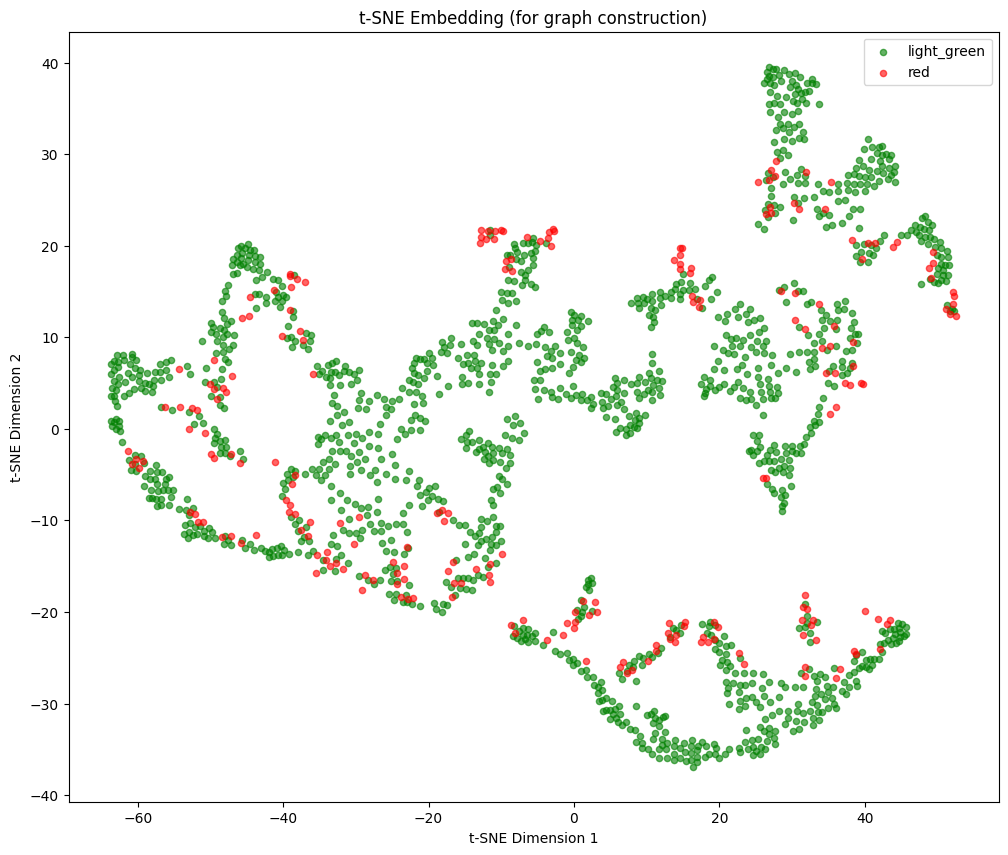

Creating graph from t-SNE similarity matrix...


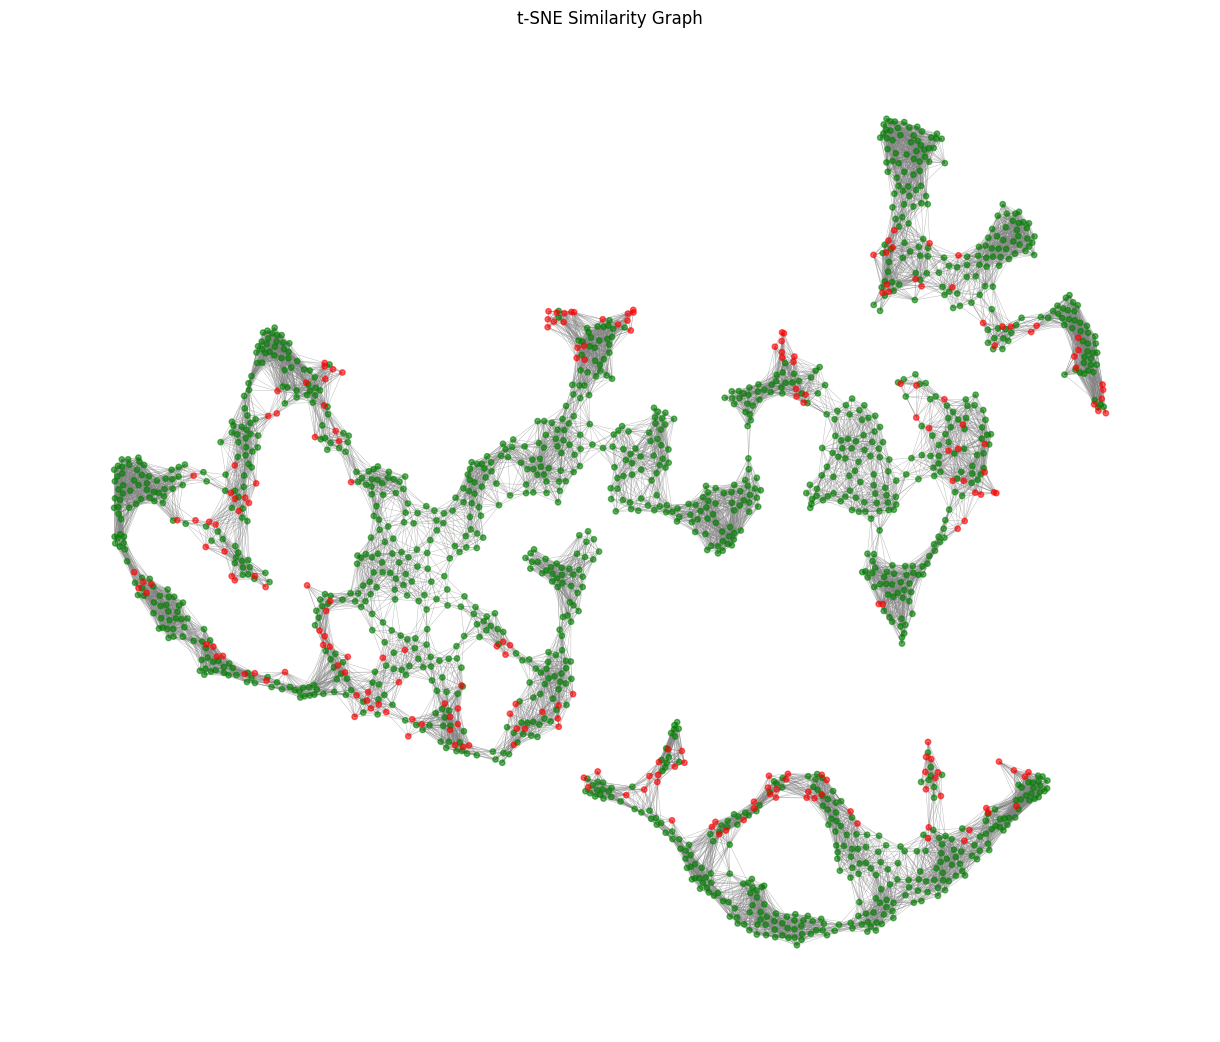

Mapping to hyperbolic Poincaré ball...
Maximum norm after mapping: 0.760000 (should be < 1.0)
Points near boundary (norm > 0.99): 0


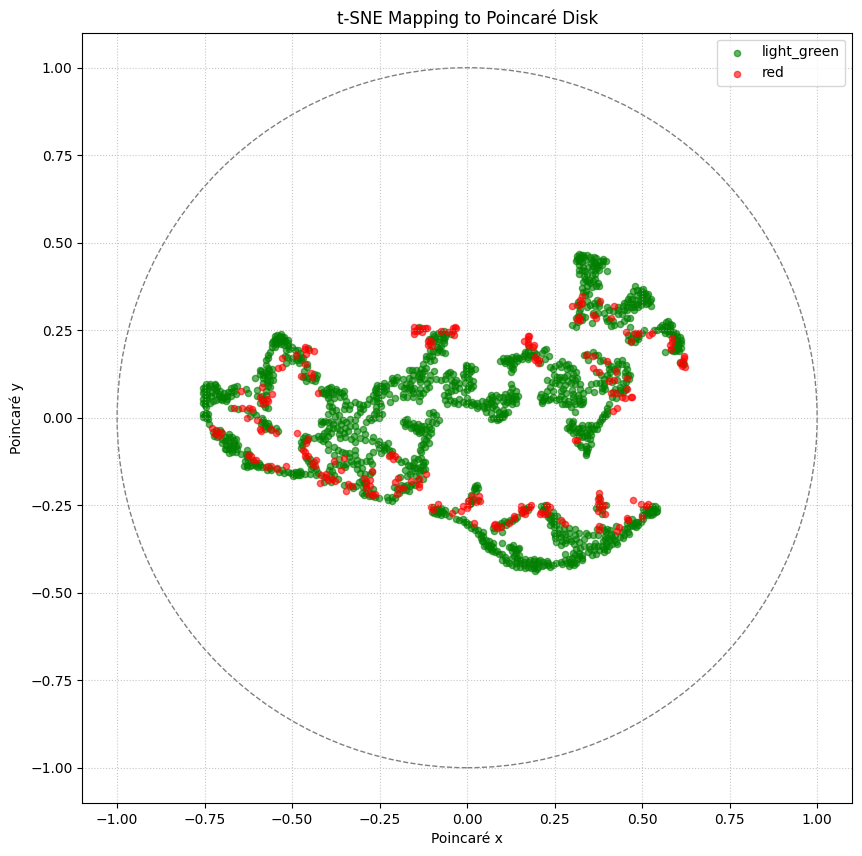

Implementing Hyperbolic Graph Convolution Layer...
Training Hyperbolic GCN for clustering...


NameError: name 'transformed_poincare_embeddings' is not defined

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score
from sklearn.metrics.pairwise import euclidean_distances
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1: Compute t-SNE embedding and extract similarity matrix
print("Computing t-SNE embedding and extracting similarity matrix...")

# Configure t-SNE with early exaggeration to capture global structure
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    learning_rate='auto',
    init='pca',
    early_exaggeration=12.0,  # Higher value to emphasize global structure
    random_state=42
)
tsne_embedding = tsne.fit_transform(X_scaled)

# Extract the similarity matrix from t-SNE
# t-SNE internally computes a similarity matrix in high-dimensional space
# We'll approximate it from the low-dimensional embedding
def get_tsne_similarity_matrix(embedding, perplexity=30):
    """Approximate the t-SNE similarity matrix from the embedding"""
    n = embedding.shape[0]
    # Compute pairwise distances
    dist = euclidean_distances(embedding)

    # Compute conditional probabilities (approximation)
    P = np.zeros((n, n))
    for i in range(n):
        # Use a Gaussian kernel with variance adjusted by perplexity
        beta = 1.0
        # Binary search for sigma that matches perplexity
        # This is a simplified version of what t-SNE does
        for _ in range(5):
            P_i = np.exp(-dist[i] ** 2 * beta)
            P_i[i] = 0  # Zero out self-similarity
            sum_P = np.sum(P_i)
            # Calculate entropy
            H = np.log(sum_P) + beta * np.sum(dist[i] * P_i) / (sum_P + 1e-8)
            # Adjust beta to match perplexity
            perplexity_actual = np.exp(H) / np.log(2)
            beta = beta * (1 + (perplexity - perplexity_actual) / perplexity)

        # Normalize to get probabilities
        P_i = P_i / (np.sum(P_i) + 1e-8)
        P[i] = P_i

    # Make symmetric (as t-SNE does)
    P = (P + P.T) / (2 * n)
    return P

# Get the similarity matrix
similarity_matrix = get_tsne_similarity_matrix(tsne_embedding, perplexity=30)

# Threshold the similarity matrix to create a sparse graph
threshold = np.percentile(similarity_matrix[similarity_matrix > 0], 70)  # Keep top 30% of connections
adjacency_matrix = np.where(similarity_matrix > threshold, similarity_matrix, 0)

# Visualize the t-SNE embedding with true labels
plt.figure(figsize=(12, 10))
plt.scatter(tsne_embedding[y_true == 0, 0], tsne_embedding[y_true == 0, 1],
            c='green', alpha=0.6, s=20, label='light_green')
plt.scatter(tsne_embedding[y_true == 1, 0], tsne_embedding[y_true == 1, 1],
            c='red', alpha=0.6, s=20, label='red')
plt.title('t-SNE Embedding (for graph construction)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.show()

# Step 2: Create graph from t-SNE similarity matrix
print("Creating graph from t-SNE similarity matrix...")

# Convert to NetworkX graph
G = nx.Graph()
for i in range(len(X_scaled)):
    G.add_node(i)

# Add edges based on similarity matrix
for i in range(len(X_scaled)):
    for j in range(i+1, len(X_scaled)):
        if adjacency_matrix[i, j] > 0:
            G.add_edge(i, j, weight=adjacency_matrix[i, j])

# Visualize the graph structure
plt.figure(figsize=(12, 10))
# Use the t-SNE embedding as positions for better visualization
pos = {i: tsne_embedding[i] for i in range(len(tsne_embedding))}
nod_colors = ['green' if y_true[i] == 0 else 'red' for i in range(len(y_true))]

# Draw the graph
nx.draw(G, pos=pos, node_color=nod_colors,
        with_labels=False, node_size=15,
        width=0.3, alpha=0.6, edge_color='gray')
plt.title('t-SNE Similarity Graph')
plt.show()

# Step 3: Map to hyperbolic Poincaré ball with extreme stability
print("Mapping to hyperbolic Poincaré ball...")

def euclidean_to_poincare_stable(points, epsilon=1e-5):
    """
    Stable mapping from Euclidean space to Poincaré ball

    This implementation:
    1. Normalizes points to ensure they're well within the unit disk
    2. Adds a buffer to prevent numerical issues
    3. Handles edge cases explicitly
    """
    # Normalize points to have max norm = 0.8 (well within boundary)
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    max_norm = np.max(norms)
    if max_norm > 0:
        # Scale all points so max norm is 0.8
        points = points * (0.8 / max_norm)
    else:
        # If all points are at origin, spread them out slightly
        points = points + np.random.randn(*points.shape) * 0.1

    # Add buffer to keep points away from boundary
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    buffer_factor = 0.95  # Keep points at 95% of max allowed radius
    points = points * buffer_factor

    # Final check to ensure no points are at or beyond boundary
    norms = np.linalg.norm(points, axis=1, keepdims=True)
    points = np.where(norms >= (1.0 - epsilon), points * (1.0 - 2*epsilon) / norms, points)

    return points

# Map the t-SNE embedding to hyperbolic space
poincare_embeddings = euclidean_to_poincare_stable(tsne_embedding, epsilon=1e-5)

# Verify the mapping produced valid points
norms = np.linalg.norm(poincare_embeddings, axis=1)
max_norm = np.max(norms)
print(f"Maximum norm after mapping: {max_norm:.6f} (should be < 1.0)")
print(f"Points near boundary (norm > 0.99): {np.sum(norms > 0.99)}")

# Visualize the mapped points in the Poincaré disk
plt.figure(figsize=(10, 10))
# Draw the unit circle (boundary of the Poincaré disk)
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray')
ax = plt.gca()
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')

# Plot the embeddings with true labels
plt.scatter(poincare_embeddings[y_true == 0, 0], poincare_embeddings[y_true == 0, 1],
            c='green', alpha=0.6, s=20, label='light_green')
plt.scatter(poincare_embeddings[y_true == 1, 0], poincare_embeddings[y_true == 1, 1],
            c='red', alpha=0.6, s=20, label='red')

plt.title('t-SNE Mapping to Poincaré Disk')
plt.xlabel('Poincaré x')
plt.ylabel('Poincaré y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Step 4: Implement Hyperbolic Graph Convolution Layer
print("Implementing Hyperbolic Graph Convolution Layer...")

class HyperbolicDistance(nn.Module):
    """Hyperbolic distance module with numerical safeguards"""
    def __init__(self, c=1.0, epsilon=1e-10):
        super(HyperbolicDistance, self).__init__()
        self.c = c
        self.epsilon = epsilon

    def forward(self, u, v):
        """Compute hyperbolic distance with safeguards"""
        # Project points to the Poincaré ball
        u = self.project_to_ball(u)
        v = self.project_to_ball(v)

        # Compute the hyperbolic distance
        alpha = 1 - self.c * torch.sum(u * u, dim=1)
        beta = 1 - self.c * torch.sum(v * v, dim=1)

        # Add safeguards against division by zero
        alpha = torch.clamp(alpha, min=1e-8)
        beta = torch.clamp(beta, min=1e-8)

        sq_dist = torch.sum((u - v) * (u - v), dim=1)
        denominator = alpha * beta
        denominator = torch.clamp(denominator, min=1e-15)

        gamma = 1 + 2 * self.c * torch.clamp(sq_dist / denominator, max=1e10)
        gamma = torch.clamp(gamma, min=1.0 + 1e-8)

        return torch.acosh(gamma) / np.sqrt(self.c)

    def project_to_ball(self, x):
        """Project points to the Poincaré ball with buffer"""
        norm = torch.norm(x, p=2, dim=1, keepdim=True)
        norm = torch.where(norm == 0, torch.ones_like(norm), norm)
        factor = torch.min(torch.ones_like(norm) * (1.0 - 2*self.epsilon), 1.0 / norm)
        return x * factor

class HyperbolicGCNLayer(nn.Module):
    """Hyperbolic Graph Convolution Layer with extreme numerical stability"""
    def __init__(self, input_dim, output_dim, c=1.0, epsilon=1e-8):
        super(HyperbolicGCNLayer, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        self.c = torch.tensor(c, dtype=torch.float32) # Convert c to a torch.Tensor
        self.epsilon = epsilon
        self.distance = HyperbolicDistance(c, epsilon)

    def forward(self, x, adjacency):
        """
        Forward pass of the hyperbolic GCN layer

        Args:
            x: Input embeddings (in Poincaré ball)
            adjacency: Adjacency matrix of the graph

        Returns:
            Output embeddings (in Poincaré ball)s
        """
        # Convert to tensor if needed
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        if not torch.is_tensor(adjacency):
            adjacency = torch.tensor(adjacency, dtype=torch.float32)

        x = x.to(device)
        adjacency = adjacency.to(device)

        # Project to safe region
        x = self.project_to_ball(x)

        # Apply linear transformation in tangent space at origin
        x_tangent = self.log_map_zero(x)  # Map to tangent space
        x_transformed = self.linear(x_tangent)  # Linear transformation
        x_hyp = self.exp_map_zero(x_transformed)  # Map back to hyperbolic space

        # Graph convolution in hyperbolic space
        n_nodes = x.shape[0]
        output = torch.zeros_like(x_hyp)

        # For numerical stability, we'll use a tangent space approximation
        for i in range(n_nodes):
            # Get neighbors
            neighbors_indices = torch.where(adjacency[i] > 0)[0]
            if len(neighbors_indices) > 0:
                # Compute weights (normalized adjacency)
                weights = adjacency[i, neighbors_indices]
                weights = weights / (torch.sum(weights) + 1e-10)

                # Map neighbors to tangent space at x_hyp[i]
                # x_hyp[i] is (feature_dim,), needs unsqueeze to (1, feature_dim) for log_map
                current_node_hyp = x_hyp[i].unsqueeze(0)
                neighbors_hyp = x_hyp[neighbors_indices]

                # log_map expects inputs with a batch dimension
                neighbors_tangent = self.log_map(current_node_hyp, neighbors_hyp)

                # Weighted average in tangent space
                avg_tangent = torch.sum(weights.unsqueeze(1) * neighbors_tangent, dim=0) # Result is (feature_dim,)

                # Map back to hyperbolic space. exp_map expects inputs with a batch dimension.
                # avg_tangent is (feature_dim,), needs unsqueeze to (1, feature_dim)
                # The result from exp_map will be (1, feature_dim), so squeeze back to (feature_dim,)
                output[i] = self.exp_map(current_node_hyp, avg_tangent.unsqueeze(0)).squeeze(0)
            else:
                output[i] = x_hyp[i]

        # Final projection to ensure points are within the ball
        output = self.project_to_ball(output)
        return output

    def log_map_zero(self, x):
        """Logarithmic map from Poincaré ball to tangent space at origin"""
        norm = torch.norm(x, p=2, dim=1, keepdim=True)
        norm = torch.where(norm == 0, torch.ones_like(norm), norm)
        factor = torch.arctanh(self.c.sqrt() * norm) / (self.c.sqrt() * norm)
        return factor * x

    def exp_map_zero(self, v):
        """Exponential map from tangent space at origin to Poincaré ball"""
        norm = torch.norm(v, p=2, dim=1, keepdim=True)
        norm = torch.where(norm == 0, torch.ones_like(norm), norm)
        factor = torch.tanh(self.c.sqrt() * norm) / (self.c.sqrt() * norm)
        return factor * v

    def log_map(self, x, y):
        """Logarithmic map from Poincaré ball to tangent space at x"""
        # Möbius subtraction
        diff = self.mobius_add(-x, y)
        # Log map formula
        norm_diff = torch.norm(diff, p=2, dim=1, keepdim=True)
        norm_diff = torch.where(norm_diff == 0, torch.ones_like(norm_diff), norm_diff)
        factor = torch.arctanh(self.c.sqrt() * norm_diff) / (self.c.sqrt() * norm_diff)
        return factor * diff

    def exp_map(self, x, v):
        """Exponential map from tangent space at x to Poincaré ball"""
        # Normalize v
        norm_v = torch.norm(v, p=2, dim=1, keepdim=True)
        norm_v = torch.where(norm_v == 0, torch.ones_like(norm_v), norm_v)
        v = v / norm_v

        # Exp map formula
        factor = torch.tanh(0.5 * self.c.sqrt() * norm_v)
        y_tangent = factor * v

        # Möbius addition
        return self.mobius_add(x, y_tangent)

    def mobius_add(self, x, y):
        """Möbius addition in Poincaré ball"""
        x2 = torch.sum(x * x, dim=1, keepdim=True)
        y2 = torch.sum(y * y, dim=1, keepdim=True)
        xy = torch.sum(x * y, dim=1, keepdim=True)

        num = (1 + 2 * self.c * xy + self.c * y2) * x + (1 - self.c * x2) * y
        den = 1 + 2 * self.c * xy + self.c**2 * x2 * y2
        den = torch.clamp(den, min=1e-15)

        return num / den

    def project_to_ball(self, x):
        """Project points to the Poincaré ball with buffer"""
        norm = torch.norm(x, p=2, dim=1, keepdim=True)
        norm = torch.where(norm == 0, torch.ones_like(norm), norm)
        factor = torch.min(torch.ones_like(norm) * (1.0 - 2*self.epsilon), 1.0 / norm)
        return x * factor

# Step 5: Train Hyperbolic GCN for clustering - WITH CORRECTED INITIALIZATION
print("Training Hyperbolic GCN for clustering...")

class HyperbolicGCN(nn.Module):
    """Hyperbolic Graph Convolutional Network for clustering"""
    def __init__(self, input_dim, hidden_dim, output_dim, c=1.0, epsilon=1e-8):
        super(HyperbolicGCN, self).__init__()
        self.gcn1 = HyperbolicGCNLayer(input_dim, hidden_dim, c, epsilon)
        self.gcn2 = HyperbolicGCNLayer(hidden_dim, output_dim, c, epsilon)

    def forward(self, x, adjacency):
        # First GCN layer
        x = self.gcn1(x, adjacency)

        # Second GCN layer
        x = self.gcn2(x, adjacency)

        return x

# Convert data to appropriate format
# Using transformed_poincare_embeddings (where red points are moved to the boundary) as input to the hyperbolic GCN
node_features = torch.tensor(transformed_poincare_embeddings, dtype=torch.float32, requires_grad=True).to(device)
adjacency = torch.tensor(adjacency_matrix, dtype=torch.float32).to(device)

# Initialize model
model = HyperbolicGCN(
    input_dim=transformed_poincare_embeddings.shape[1],
    hidden_dim=16,
    output_dim=2,  # 2D embedding for visualization and clustering
    c=1.0,
    epsilon=1e-8
).to(device)

# CORRECTED WEIGHT INITIALIZATION
# In PyTorch, Linear layer weights have shape (out_features, in_features)
# So for a layer from 2D to 16D, the weight shape should be (16, 2)
with torch.no_grad():
    # Create a weight matrix where first 2 rows are identity (preserving original dimensions)
    weight_init = torch.zeros(16, 2)
    weight_init[:2, :] = torch.eye(2)
    model.gcn1.linear.weight.copy_(weight_init)
    model.gcn1.linear.bias.fill_(0)

# Training setup
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
criterion = nn.MSELoss()

# Training loop with extreme numerical safeguards
losses = []
for epoch in tqdm(range(200)):
    optimizer.zero_grad()

    try:
        # Forward pass
        embeddings = model(node_features, adjacency)

        # Project embeddings to ensure numerical stability
        with torch.no_grad():
            norms = torch.norm(embeddings, p=2, dim=1, keepdim=True)
            embeddings = torch.where(norms >= 0.95, embeddings * 0.9 / norms, embeddings)

        # Loss: we want embeddings to be well separated for the two classes
        # Compute mean embeddings for each class
        green_mask = torch.tensor(y_true == 0, dtype=torch.bool).to(device)
        red_mask = torch.tensor(y_true == 1, dtype=torch.bool).to(device)

        if torch.sum(green_mask) > 0 and torch.sum(red_mask) > 0:
            green_mean = torch.mean(embeddings[green_mask], dim=0)
            red_mean = torch.mean(embeddings[red_mask], dim=0)

            # Distance between class means (we want this to be large)
            dist = torch.norm(green_mean - red_mean)

            # Add regularization to keep points within the ball
            norms = torch.norm(embeddings, p=2, dim=1)
            boundary_penalty = torch.relu(norms - 0.95).mean() * 100.0

            # Total loss
            loss = -dist + boundary_penalty
        else:
            # Fallback loss if one class is missing
            initial_embeddings = torch.tensor(poincare_embeddings, dtype=torch.float32).to(device)
            loss = criterion(embeddings, initial_embeddings)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Learning rate scheduling
        if epoch % 10 == 0:
            scheduler.step(loss)

        losses.append(loss.item())

    except RuntimeError as e:
        print(f"Runtime error at epoch {epoch}: {str(e)}")
        # Fallback: use previous embeddings
        with torch.no_grad():
            embeddings = torch.tensor(poincare_embeddings, dtype=torch.float32).to(device)
        losses.append(losses[-1] if losses else 1.0)

# Get final embeddings
with torch.no_grad():
    final_embeddings = model(node_features, adjacency).cpu().numpy()

# Verify embeddings are valid
norms = np.linalg.norm(final_embeddings, axis=1)
max_norm = np.max(norms)
print(f"Maximum norm of final embeddings: {max_norm:.6f}")

# Step 6: Cluster the final embeddings and evaluate
print("Clustering the final embeddings...")

def hyperbolic_distance_stable(u, v, c=1.0, epsilon=1e-10):
    """Stable hyperbolic distance calculation"""
    # Ensure points are within the ball
    u_norm = np.linalg.norm(u)
    v_norm = np.linalg.norm(v)
    if u_norm >= 1 or v_norm >= 1:
        if u_norm >= 1:
            u = u * (0.9 - epsilon) / max(u_norm, epsilon)
        if v_norm >= 1:
            v = v * (0.9 - epsilon) / max(v_norm, epsilon)

    # Compute distance with safeguards
    norm_u = np.sum(u**2)
    norm_v = np.sum(v**2)
    sq_dist = np.sum((u - v)**2)

    alpha = max(1 - c * norm_u, 1e-8)
    beta = max(1 - c * norm_v, 1e-8)

    denominator = alpha * beta
    if denominator < 1e-15:
        denominator = 1e-15

    ratio = min(sq_dist / denominator, 1e10)
    gamma = 1 + 2 * c * ratio
    gamma = max(gamma, 1.0 + 1e-8)

    if gamma > 1e10:
        return 20.0  # Cap the distance

    return np.arccosh(gamma) / np.sqrt(c)

def hyperbolic_kmeans_stable(embeddings, n_clusters=2, max_iter=150, epsilon=1e-8):
    """K-means clustering in hyperbolic space with safeguards"""
    num_points = embeddings.shape[0]

    # Ensure we have unique points
    unique_indices = np.unique(embeddings.round(decimals=5), axis=0, return_index=True)[1]
    if len(unique_indices) < n_clusters:
        print(f"WARNING: Only {len(unique_indices)} unique points, but need {n_clusters} clusters. Using fallback initialization.")
        # Fallback initialization
        centroids = np.zeros((n_clusters, embeddings.shape[1]))
        for i in range(n_clusters):
            centroids[i, 0] = -0.7 + 1.4 * i / (n_clusters - 1)
    else:
        idx = np.random.choice(unique_indices, n_clusters, replace=False)
        centroids = embeddings[idx].copy()

    labels = np.zeros(num_points)

    for _ in range(max_iter):
        # Assign points to nearest centroid
        for i in range(num_points):
            min_dist = float('inf')
            for j in range(n_clusters):
                dist = hyperbolic_distance_stable(embeddings[i], centroids[j], epsilon=epsilon)
                if dist < min_dist:
                    min_dist = dist
                    labels[i] = j

        # Update centroids
        old_centroids = centroids.copy()
        for j in range(n_clusters):
            cluster_points = embeddings[labels == j]
            if len(cluster_points) > 0:
                # Take mean and project to ball
                centroid = np.mean(cluster_points, axis=0)
                norm = np.linalg.norm(centroid)
                if norm >= 1:
                    centroid = centroid * 0.85 / max(norm, epsilon)
                centroids[j] = centroid
            else:
                # Reinitialize empty cluster
                print(f"WARNING: Cluster {j} became empty. Reinitializing...")
                max_dist = -1
                new_centroid_idx = 0
                for i in range(num_points):
                    min_dist = float('inf')
                    for k in range(n_clusters):
                        if k == j:
                            continue
                        dist = hyperbolic_distance_stable(embeddings[i], centroids[k], epsilon=epsilon)
                        if dist < min_dist:
                            min_dist = dist
                    if min_dist > max_dist:
                        max_dist = min_dist
                        new_centroid_idx = i
                centroids[j] = embeddings[new_centroid_idx]

        # Check for convergence
        if np.all(np.linalg.norm(old_centroids - centroids, axis=1) < 1e-10):
            break

    return labels, centroids

# Perform clustering on the final embeddings
final_labels, final_centroids = hyperbolic_kmeans_stable(final_embeddings, n_clusters=2, epsilon=1e-8)

# Evaluate the clustering results
def evaluate_clustering(y_true, y_pred, title):
    """Evaluate clustering results by mapping cluster labels to true labels and computing F1 score."""
    # Since clustering doesn't guarantee which cluster corresponds to which class,
    # we need to map the cluster labels to the true labels
    # We'll try both possible mappings and choose the one with better F1 score

    # Option 1: cluster 0 -> class 0, cluster 1 -> class 1
    y_pred_mapped1 = y_pred.copy()

    # Option 2: cluster 0 -> class 1, cluster 1 -> class 0
    y_pred_mapped2 = 1 - y_pred

    # Calculate F1 scores for both mappings
    f1_1 = f1_score(y_true, y_pred_mapped1, zero_division=0)
    f1_2 = f1_score(y_true, y_pred_mapped2, zero_division=0)

    # Choose the mapping with higher F1 score
    if f1_1 >= f1_2:
        y_pred_final = y_pred_mapped1
        f1 = f1_1
    else:
        y_pred_final = y_pred_mapped2
        f1 = f1_2

    print(f"\n{title} - F1 Score: {f1:.4f}")

    # Plot confusion matrix
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(y_true, y_pred_final)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["light_green", "red"])
    disp.plot()
    plt.title(f"{title} Confusion Matrix")
    plt.show()

    return f1, y_pred_final

hgcn_f1, hgcn_pred = evaluate_clustering(y_true, final_labels, "Hyperbolic GCN with t-SNE Edges")

# Step 7: Visualize the results
print("Visualizing results...")

plt.figure(figsize=(20, 15))

# 1. Original data
plt.subplot(2, 3, 1)
plt.scatter(X[y_true == 0, 0], X[y_true == 0, 1], c='green', alpha=0.5, s=10, label='light_green')
plt.scatter(X[y_true == 1, 0], X[y_true == 1, 1], c='red', alpha=0.5, s=10, label='red')
plt.title('Original Data')
plt.legend()

# 2. t-SNE embedding
plt.subplot(2, 3, 2)
plt.scatter(tsne_embedding[y_true == 0, 0], tsne_embedding[y_true == 0, 1],
            c='green', alpha=0.6, s=20, label='light_green')
plt.scatter(tsne_embedding[y_true == 1, 0], tsne_embedding[y_true == 1, 1],
            c='red', alpha=0.6, s=20, label='red')
plt.title('t-SNE Embedding')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()

# 3. Final hyperbolic embeddings with clustering
plt.subplot(2, 3, 3)
# Draw the unit circle
circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray')
ax = plt.gca()
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')

# Plot the embeddings with cluster labels
plt.scatter(final_embeddings[hgcn_pred == 0, 0], final_embeddings[hgcn_pred == 0, 1],
            c='green', alpha=0.6, s=20, label='Cluster 0')
plt.scatter(final_embeddings[hgcn_pred == 1, 0], final_embeddings[hgcn_pred == 1, 1],
            c='red', alpha=0.6, s=20, label='Cluster 1')

# Plot centroids
plt.scatter(final_centroids[:, 0], final_centroids[:, 1],
            c='black', marker='X', s=100, label='Centroids')

plt.title(f'Hyperbolic GCN Embeddings\nF1: {hgcn_f1:.4f}')
plt.xlabel('Poincaré x')
plt.ylabel('Poincaré y')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# 4. Original space with Hyperbolic GCN results
plt.subplot(2, 3, 4)
plt.scatter(X[hgcn_pred == 0, 0], X[hgcn_pred == 0, 1], c='green', alpha=0.7, s=10, label='Cluster 0')
plt.scatter(X[hgcn_pred == 1, 0], X[hgcn_pred == 1, 1], c='red', alpha=0.7, s=10, label='Cluster 1')
plt.title(f'Hyperbolic GCN in Original Space\nF1: {hgcn_f1:.4f}')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

# 5. Compare with best previous method
best_idx = np.argmax(f1_scores)
best_method = methods[best_idx]
best_score = f1_scores[best_idx]

if best_method == 'DBSCAN':
    best_pred = dbscan_pred
elif best_method == 'Agglomerative':
    best_pred = agg_pred
elif best_method == 'Fuzzy C-Means' and 'fcm_f1' in locals() and fcm_f1 is not None:
    best_pred = fcm_pred
elif best_method == 't-SNE + DBSCAN':
    best_pred = tsne_pred
elif best_method == 'Spectral Clustering':
    best_pred = spectral_pred
elif best_method == 'ICA + DBSCAN':
    best_pred = ica_dbscan_pred
elif best_method == 'ICA + Agglomerative':
    best_pred = ica_agg_pred
elif best_method == 'ICA + GMM':
    best_pred = ica_gmm_pred
elif best_method == 'ICA + Spectral':
    best_pred = ica_spectral_pred
else:  # 'ICA + K-Means'
    best_pred = ica_kmeans_pred

plt.subplot(2, 3, 5)
plt.scatter(X[best_pred == 0, 0], X[best_pred == 0, 1], c='green', alpha=0.5, s=10)
plt.scatter(X[best_pred == 1, 0], X[best_pred == 1, 1], c='red', alpha=0.5, s=10)
plt.title(f'Best Previous Method: {best_method}\nF1: {best_score:.4f}')

# 6. Error comparison
plt.subplot(2, 3, 6)
misclassified_hgcn = (hgcn_pred != y_true)
misclassified_best = (best_pred != y_true)

plt.scatter(X[~misclassified_hgcn, 0], X[~misclassified_hgcn, 1],
            c='gray', alpha=0.5, s=10, label='Correct in HGCN')
plt.scatter(X[misclassified_hgcn & ~misclassified_best, 0], X[misclassified_hgcn & ~misclassified_best, 1],
            c='blue', marker='o', s=20, edgecolor='black', label=f'Corrected by HGCN')
plt.scatter(X[~misclassified_hgcn & misclassified_best, 0], X[~misclassified_hgcn & misclassified_best, 1],
            c='red', marker='x', s=20, label=f'New errors from HGCN')
plt.title('Error Comparison')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.suptitle('Hyperbolic GCN with t-SNE Edge Construction Analysis', fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()

# Compare with all previous methods
methods.append('Hyperbolic GCN with t-SNE')
f1_scores.append(hgcn_f1)

plt.figure(figsize=(14, 8))
bars = plt.bar(methods, f1_scores)
plt.title('F1 Score Comparison (Including Hyperbolic GCN with t-SNE)', fontsize=16)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, max(f1_scores) * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)

# Add value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{f1_scores[i]:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Visualizing the Effect of Curvature 'c' on Hyperbolic Distance

The curvature parameter 'c' in hyperbolic geometry dictates the 'intensity' of the hyperbolic space. As 'c' increases, the space becomes 'more curved', and distances can diverge faster. Let's see this effect by calculating the hyperbolic distance between two fixed points for a range of 'c' values.

Point A: [0.3 0.4]
Point B: [0.7 0.6]


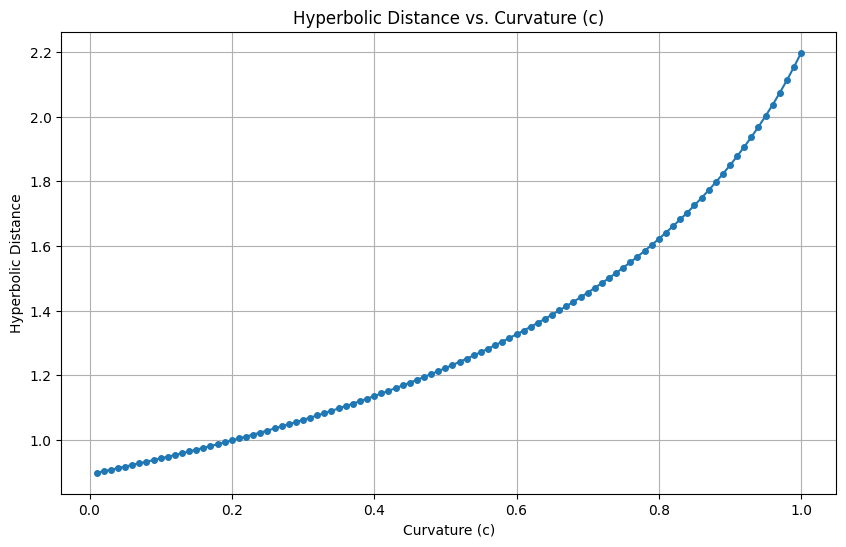


Distance between point A [0.3 0.4] and point B [0.7 0.6]:
 - Euclidean Distance: 0.4472
 - Hyperbolic Distance (c=0.01): 0.8991
 - Hyperbolic Distance (c=1.0): 2.1972


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define two sample points in Poincaré disk (ensuring they are within the unit ball)
# Point A: Closer to the center
point_a = np.array([0.3, 0.4])
# Point B: Further from the center
point_b = np.array([0.7, 0.6])

# Ensure points are within the unit disk to start with
norm_a = np.linalg.norm(point_a)
norm_b = np.linalg.norm(point_b)

if norm_a >= 1.0:
    point_a = point_a * 0.9 / norm_a
if norm_b >= 1.0:
    point_b = point_b * 0.9 / norm_b

print(f"Point A: {point_a}")
print(f"Point B: {point_b}")

# Range of curvature 'c' values to test
c_values = np.linspace(0.01, 1.0, 100)  # From slightly curved to maximally curved (for Poincaré model)
hyperbolic_distances = []

for c_val in c_values:
    # We need to adapt the existing hyperbolic_distance_stable function to accept c as a parameter
    # For this demonstration, we'll re-define a local version or modify the existing one if it's feasible.
    # Assuming hyperbolic_distance_stable is accessible and can take 'c' as an argument:
    try:
        # Directly use the function from the previous cell, which is defined to use `c`.
        # The `hyperbolic_distance_stable` function is already defined to take `c` as argument.
        dist = hyperbolic_distance_stable(point_a, point_b, c=c_val)
        hyperbolic_distances.append(dist)
    except Exception as e:
        print(f"Error calculating distance for c={c_val}: {e}")
        hyperbolic_distances.append(np.nan)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(c_values, hyperbolic_distances, marker='o', linestyle='-', markersize=4)
plt.title('Hyperbolic Distance vs. Curvature (c)')
plt.xlabel('Curvature (c)')
plt.ylabel('Hyperbolic Distance')
plt.grid(True)
plt.show()

print(f"\nDistance between point A {point_a} and point B {point_b}:")
print(f" - Euclidean Distance: {np.linalg.norm(point_a - point_b):.4f}")
print(f" - Hyperbolic Distance (c=0.01): {hyperbolic_distances[0]:.4f}")
print(f" - Hyperbolic Distance (c=1.0): {hyperbolic_distances[-1]:.4f}")

# SUPERVISED CLASSIFICATION WITH PROPER METRICS


SECTION 10: SUPERVISED CLASSIFICATION WITH PROPER METRICS

Class distribution:
  Green (class 0): 1445 (86.42%)
  Red (class 1):   227 (13.58%)
  Imbalance ratio: 6.37:1

Train size: 1170, Test size: 502

--- 10.1 Logistic Regression with class_weight='balanced' ---

Logistic Regression (threshold=0.5):
              precision    recall  f1-score   support

 light_green       0.88      0.51      0.65       434
         red       0.15      0.54      0.23        68

    accuracy                           0.52       502
   macro avg       0.51      0.53      0.44       502
weighted avg       0.78      0.52      0.59       502



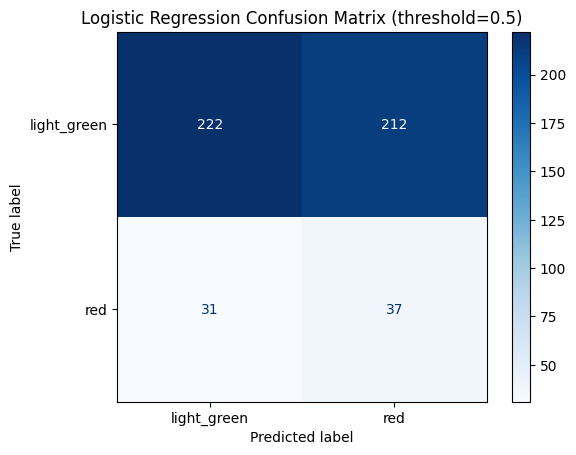


--- 10.2 Threshold Tuning Analysis ---


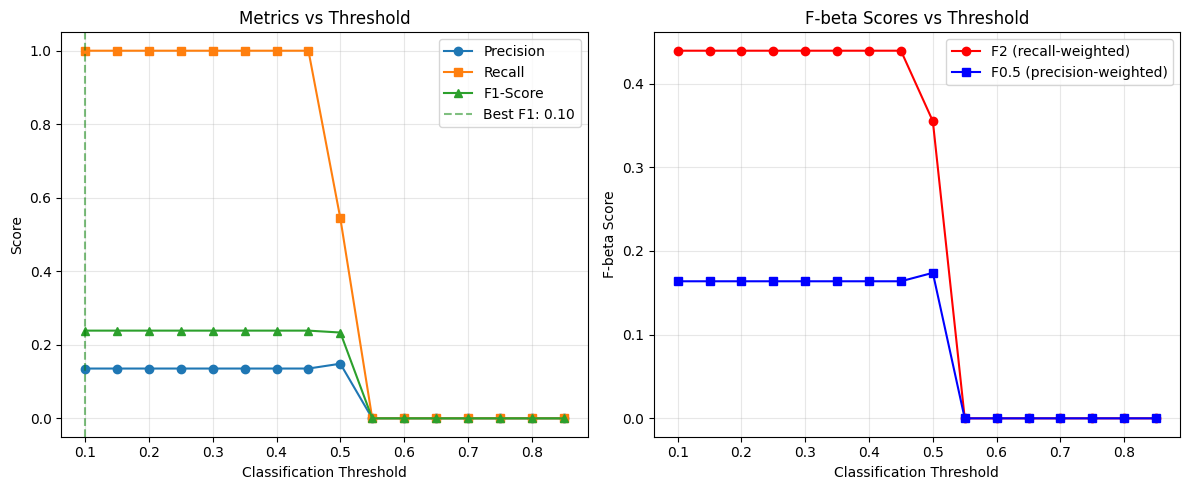


Optimal thresholds:
  Best F1:     0.10 (F1=0.2386)
  Best F2:     0.10 (F2=0.4393) - prioritize catching red points
  Best F0.5:   0.50 (F0.5=0.1739) - prioritize avoiding false alarms

--- 10.3 Precision-Recall Curve ---


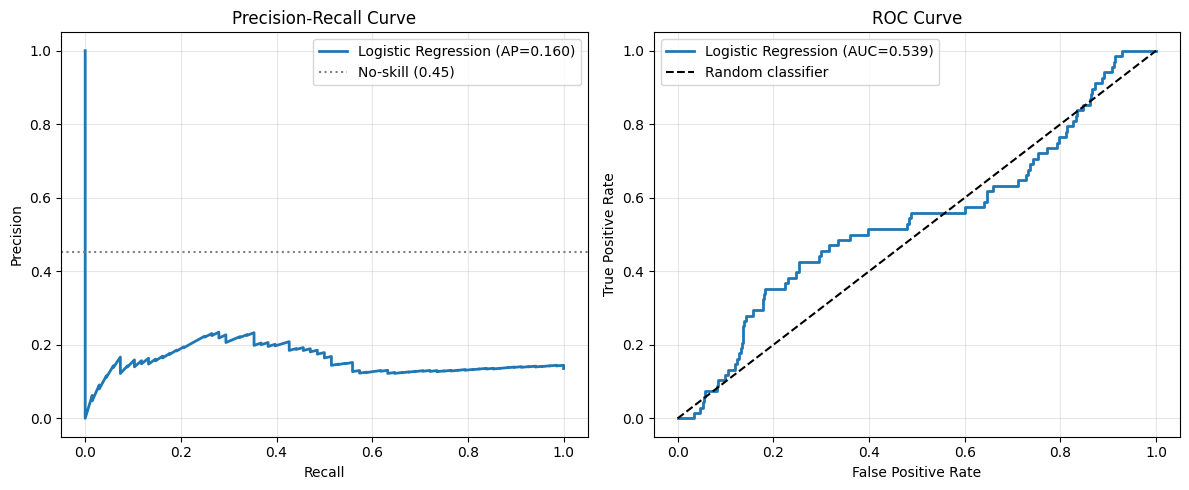


Average Precision (AP): 0.1604
ROC-AUC: 0.5394
Note: AP is more informative than AUC for imbalanced data!

--- 10.4 Cost-Based Threshold Optimization ---
Cost configuration:
  False Negative (miss red):  10.0 units
  False Positive (false red): 1.0 units


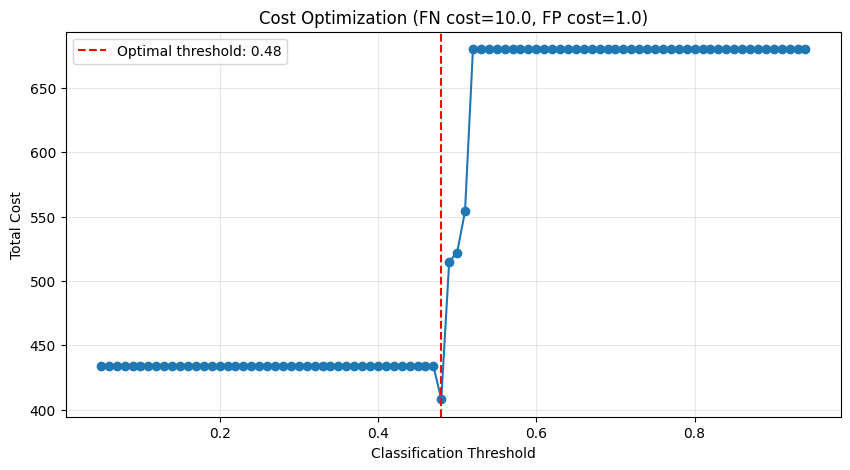


Performance with cost-optimized threshold (0.48):
              precision    recall  f1-score   support

 light_green       1.00      0.06      0.11       434
         red       0.14      1.00      0.25        68

    accuracy                           0.19       502
   macro avg       0.57      0.53      0.18       502
weighted avg       0.88      0.19      0.13       502


Confusion Matrix (optimal threshold):
  True Negatives (green→green): 26
  False Positives (green→red):  0
  False Negatives (red→green):  408
  True Positives (red→red):     68

Total cost: 408.00 units

--- 10.5 Compare Multiple Classifiers ---

Logistic Regression (balanced):
  F1=0.2334, Precision=0.1486, Recall=0.5441, AP=0.1604

Random Forest (balanced):
  F1=0.1348, Precision=0.2857, Recall=0.0882, AP=0.3080

Gradient Boosting:
  F1=0.1750, Precision=0.5833, Recall=0.1029, AP=0.2877


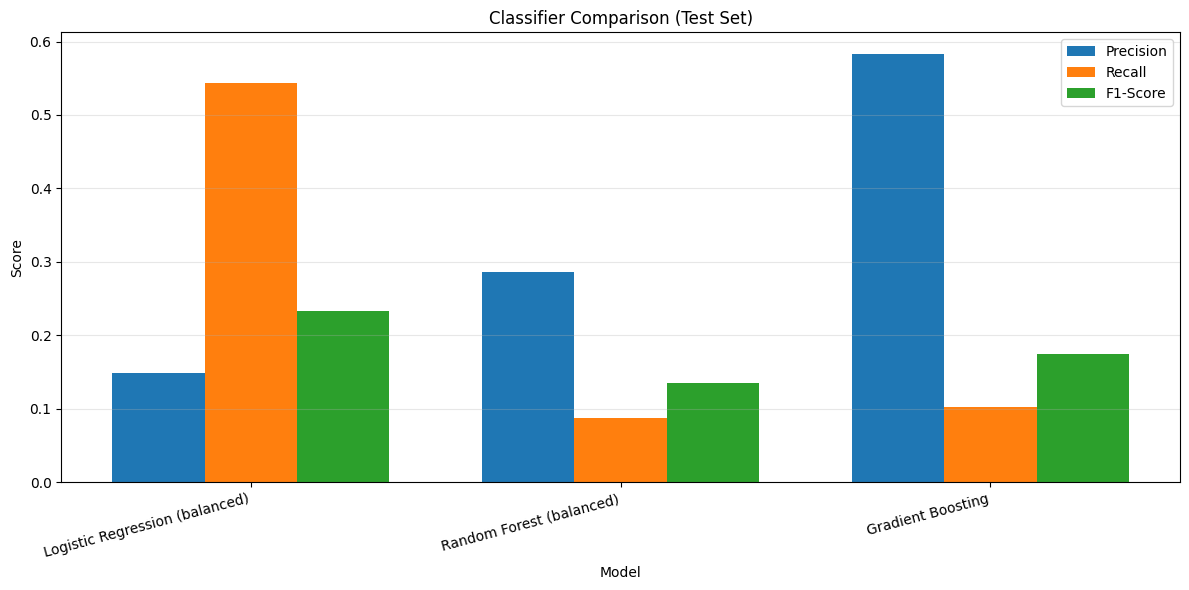


--- 10.6 Stratified Cross-Validation ---

Stratified 5-fold CV F1-scores: [0.20792079 0.18627451 0.23829787 0.20353982 0.2254902 ]
Mean F1: 0.2123 ± 0.0180
Mean Accuracy: 0.4958 ± 0.0282
⚠️  Note: High accuracy can mask poor performance on rare class!

--- 10.7 Deployment-Ready Prediction Function ---

Sample predictions (threshold=0.48):
     X      Y   True   Pred  Prob(red) Correct?
--------------------------------------------------
1046.0 1071.0  green    red      0.512 ✗
1052.0 1514.0  green    red      0.512 ✗
 903.0  717.0  green    red      0.512 ✗
 974.0  392.0  green    red      0.512 ✗
1448.0  627.0  green    red      0.512 ✗
 540.0  602.0  green    red      0.512 ✗
 806.0  646.0  green    red      0.512 ✗
 733.0  363.0  green    red      0.512 ✗
1550.0 1658.0    red    red      0.512 ✓
1020.0 1267.0  green    red      0.512 ✗


In [24]:
"""
=================================================================
SECTION 10: SUPERVISED CLASSIFICATION WITH PROPER METRICS
Based on: https://habr.com/ru/companies/otus/articles/1034692/
Key ideas:
- Accuracy is misleading for imbalanced classes → use Precision/Recall/F1
- Threshold tuning (not always 0.5) for optimal business outcome
- PR-curve visualization instead of ROC for rare classes
- Cost-based threshold optimization
- Stratified validation and class_weight balancing
=================================================================
"""
print("\n" + "="*70)
print("SECTION 10: SUPERVISED CLASSIFICATION WITH PROPER METRICS")
print("="*70)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             fbeta_score, classification_report,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Check class balance
n_green = np.sum(y_true == 0)
n_red = np.sum(y_true == 1)
total = len(y_true)
print(f"\nClass distribution:")
print(f"  Green (class 0): {n_green} ({100*n_green/total:.2f}%)")
print(f"  Red (class 1):   {n_red} ({100*n_red/total:.2f}%)")
print(f"  Imbalance ratio: {max(n_green, n_red)/min(n_green, n_red):.2f}:1")

# Split data with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_true,
    test_size=0.3,
    stratify=y_true,  # CRITICAL for imbalanced data
    random_state=42
)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

# =================================================================
# 10.1 Baseline: Logistic Regression with class_weight='balanced'
# =================================================================
print("\n--- 10.1 Logistic Regression with class_weight='balanced' ---")

# Train with balanced class weights (automatically handles imbalance)
lr_balanced = LogisticRegression(
    class_weight='balanced',  # Weight rare class inversely to frequency
    max_iter=1000,
    random_state=42
)
lr_balanced.fit(X_train, y_train)

# Predict with default threshold (0.5)
y_pred_lr = lr_balanced.predict(X_test)
y_proba_lr = lr_balanced.predict_proba(X_test)[:, 1]

# Evaluate with proper metrics
print(f"\nLogistic Regression (threshold=0.5):")
print(classification_report(y_test, y_pred_lr, target_names=["light_green", "red"]))

# Show confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["light_green", "red"])
disp.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix (threshold=0.5)')
plt.show()

# =================================================================
# 10.2 Threshold Tuning: Finding optimal probability cutoff
# =================================================================
print("\n--- 10.2 Threshold Tuning Analysis ---")

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    y_pred_t = (y_proba_lr >= thresh).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    results.append({'threshold': thresh, 'precision': p, 'recall': r, 'f1': f1})

results_df = pd.DataFrame(results)

# Plot metrics vs threshold
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results_df['threshold'], results_df['precision'], label='Precision', marker='o')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall', marker='s')
plt.plot(results_df['threshold'], results_df['f1'], label='F1-Score', marker='^')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# Highlight best F1 threshold
best_f1_idx = results_df['f1'].idxmax()
best_thresh_f1 = results_df.loc[best_f1_idx, 'threshold']
plt.axvline(best_thresh_f1, color='green', linestyle='--', alpha=0.5,
            label=f'Best F1: {best_thresh_f1:.2f}')
plt.legend()

plt.subplot(1, 2, 2)
# Calculate F2 (recall-weighted) and F0.5 (precision-weighted)
f2_scores = [fbeta_score(y_test, (y_proba_lr >= t).astype(int), beta=2, zero_division=0) for t in thresholds]
f05_scores = [fbeta_score(y_test, (y_proba_lr >= t).astype(int), beta=0.5, zero_division=0) for t in thresholds]

plt.plot(thresholds, f2_scores, label='F2 (recall-weighted)', marker='o', color='red')
plt.plot(thresholds, f05_scores, label='F0.5 (precision-weighted)', marker='s', color='blue')
plt.xlabel('Classification Threshold')
plt.ylabel('F-beta Score')
plt.title('F-beta Scores vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimal thresholds:")
print(f"  Best F1:     {best_thresh_f1:.2f} (F1={results_df.loc[best_f1_idx, 'f1']:.4f})")
print(f"  Best F2:     {thresholds[np.argmax(f2_scores)]:.2f} (F2={max(f2_scores):.4f}) - prioritize catching red points")
print(f"  Best F0.5:   {thresholds[np.argmax(f05_scores)]:.2f} (F0.5={max(f05_scores):.4f}) - prioritize avoiding false alarms")

# =================================================================
# 10.3 Precision-Recall Curve (better than ROC for imbalanced data)
# =================================================================
print("\n--- 10.3 Precision-Recall Curve ---")

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba_lr)
ap_score = average_precision_score(y_test, y_proba_lr)

# Also compute ROC-AUC for comparison
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(12, 5))

# PR Curve
plt.subplot(1, 2, 1)
plt.plot(recall_curve, precision_curve, label=f'Logistic Regression (AP={ap_score:.3f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
# Add no-skill line (proportion of positive class)
plt.axhline(y=n_red/len(y_test), color='gray', linestyle=':', label=f'No-skill ({n_red/len(y_test):.2f})')
plt.legend()

# ROC Curve (for reference)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC={roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage Precision (AP): {ap_score:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Note: AP is more informative than AUC for imbalanced data!")

# =================================================================
# 10.4 Cost-Based Threshold Optimization
# =================================================================
print("\n--- 10.4 Cost-Based Threshold Optimization ---")

# Define business costs (customize based on your use case)
# Example: Classifying brain MRI slices (AD vs HC)
# - False Negative (miss AD): costly - delayed diagnosis
# - False Positive (flag HC as AD): less costly - extra review
COST_FN = 10.0  # Cost of missing a red point (False Negative)
COST_FP = 1.0   # Cost of false alarm on green point (False Positive)

print(f"Cost configuration:")
print(f"  False Negative (miss red):  {COST_FN} units")
print(f"  False Positive (false red): {COST_FP} units")

best_threshold_cost = 0.5
min_total_cost = float('inf')
cost_history = []

for thresh in np.arange(0.05, 0.95, 0.01):
    y_pred_cost = (y_proba_lr >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_cost)
    tn, fp, fn, tp = cm.ravel()

    # Total cost = FN * cost_FN + FP * cost_FP
    total_cost = fn * COST_FN + fp * COST_FP
    cost_history.append({'threshold': thresh, 'total_cost': total_cost, 'fp': fp, 'fn': fn})

    if total_cost < min_total_cost:
        min_total_cost = total_cost
        best_threshold_cost = thresh

cost_df = pd.DataFrame(cost_history)

# Plot cost vs threshold
plt.figure(figsize=(10, 5))
plt.plot(cost_df['threshold'], cost_df['total_cost'], marker='o')
plt.axvline(best_threshold_cost, color='red', linestyle='--',
            label=f'Optimal threshold: {best_threshold_cost:.2f}')
plt.xlabel('Classification Threshold')
plt.ylabel('Total Cost')
plt.title(f'Cost Optimization (FN cost={COST_FN}, FP cost={COST_FP})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate with optimal cost-based threshold
y_pred_optimal = (y_proba_lr >= best_threshold_cost).astype(int)
print(f"\nPerformance with cost-optimized threshold ({best_threshold_cost:.2f}):")
print(classification_report(y_test, y_pred_optimal, target_names=["light_green", "red"]))

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print(f"\nConfusion Matrix (optimal threshold):")
print(f"  True Negatives (green→green): {cm_optimal[0,0]}")
print(f"  False Positives (green→red):  {cm_optimal[1,0]}")
print(f"  False Negatives (red→green):  {cm_optimal[0,1]}")
print(f"  True Positives (red→red):     {cm_optimal[1,1]}")
print(f"\nTotal cost: {min_total_cost:.2f} units")

# =================================================================
# 10.5 Compare Multiple Classifiers
# =================================================================
print("\n--- 10.5 Compare Multiple Classifiers ---")

classifiers = {
    'Logistic Regression (balanced)': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest (balanced)': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

comparison_results = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_proba = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)

    # Use optimal threshold for each (or default 0.5)
    ap = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)

    comparison_results.append({
        'model': name,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'ap': ap
    })
    print(f"\n{name}:")
    print(f"  F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, AP={ap:.4f}")

# Bar chart comparison
comp_df = pd.DataFrame(comparison_results)
plt.figure(figsize=(12, 6))
x = np.arange(len(comp_df))
width = 0.25

plt.bar(x - width, comp_df['precision'], width, label='Precision')
plt.bar(x, comp_df['recall'], width, label='Recall')
plt.bar(x + width, comp_df['f1'], width, label='F1-Score')

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Classifier Comparison (Test Set)')
plt.xticks(x, comp_df['model'], rotation=15, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# =================================================================
# 10.6 Stratified Cross-Validation for Robust Evaluation
# =================================================================
print("\n--- 10.6 Stratified Cross-Validation ---")

# Use StratifiedKFold to ensure each fold has same class ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate with F1 scoring (NOT accuracy!)
cv_f1_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_scaled, y_true,
    cv=cv,
    scoring='f1'  # Critical: use F1, not accuracy!
)

print(f"\nStratified 5-fold CV F1-scores: {cv_f1_scores}")
print(f"Mean F1: {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}")

# Compare with accuracy (to show why it's misleading)
cv_acc_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X_scaled, y_true,
    cv=cv,
    scoring='accuracy'
)
print(f"Mean Accuracy: {cv_acc_scores.mean():.4f} ± {cv_acc_scores.std():.4f}")
print(f"⚠️  Note: High accuracy can mask poor performance on rare class!")

# =================================================================
# 10.7 Final Prediction Function for New Data
# =================================================================
print("\n--- 10.7 Deployment-Ready Prediction Function ---")

def predict_red_green(X_new, model=lr_balanced, threshold=best_threshold_cost, scaler=scaler):
    """
    Predict class for new X,Y coordinates.

    Parameters:
    -----------
    X_new : array-like, shape (n_samples, 2)
        New data points with [X, Y] coordinates
    model : trained classifier with predict_proba method
    threshold : float, optimal classification threshold
    scaler : fitted StandardScaler for feature normalization

    Returns:
    --------
    predictions : array of 0 (green) or 1 (red)
    probabilities : array of probability scores for class 1 (red)
    """
    # Scale features
    X_new_scaled = scaler.transform(X_new)

    # Get probabilities
    proba = model.predict_proba(X_new_scaled)[:, 1]

    # Apply optimal threshold
    predictions = (proba >= threshold).astype(int)

    return predictions, proba

# Example: Predict on a few test points
sample_indices = np.random.choice(len(X_test), 10, replace=False)
X_sample = X_test[sample_indices]
y_sample_true = y_test[sample_indices]

preds, probas = predict_red_green(X_sample)

print(f"\nSample predictions (threshold={best_threshold_cost:.2f}):")
print(f"{'X':>6} {'Y':>6} {'True':>6} {'Pred':>6} {'Prob(red)':>10} {'Correct?'}")
print("-" * 50)
for i, (x, y, true, pred, prob) in enumerate(zip(
    X_sample[:, 0], X_sample[:, 1], y_sample_true, preds, probas)):
    # Inverse transform for display
    x_orig = x * scaler.scale_[0] + scaler.mean_[0]
    y_orig = y * scaler.scale_[1] + scaler.mean_[1]
    correct = "✓" if true == pred else "✗"
    color_true = "green" if true == 0 else "red"
    color_pred = "green" if pred == 0 else "red"
    print(f"{x_orig:6.1f} {y_orig:6.1f} {color_true:>6} {color_pred:>6} {prob:10.3f} {correct}")


In [22]:
# =================================================================
# 10.8 Summary: Key Takeaways from the Article
# =================================================================
print("\n" + "="*70)
print("KEY TAKEAWAYS FOR IMBALANCED CLASSIFICATION:")
print("="*70)

# Compute metrics once before formatting to avoid .format() issues
final_f1 = f1_score(y_test, y_pred_optimal, zero_division=0)
final_ap = ap_score
optimal_thresh = best_threshold_cost

print(f"""
1. ❌ NEVER rely on accuracy alone for imbalanced data
   ✅ ALWAYS check precision, recall, and F1 for the minority class

2. ✅ Use stratify=y in train_test_split to preserve class ratios

3. ✅ Use class_weight='balanced' or SMOTE to handle imbalance during training

4. ✅ Threshold 0.5 is arbitrary – tune it based on:
   • F1/F-beta scores
   • Precision-Recall curve
   • Business cost of errors (FN vs FP)

5. ✅ Prefer Precision-Recall curves over ROC for rare classes
   • AP (Average Precision) is more informative than AUC

6. ✅ Use StratifiedKFold with scoring='f1' for cross-validation
   • Default scoring='accuracy' hides problems with rare classes

7. ✅ Report confusion matrix – it shows WHERE the model fails


Current best configuration for your red/green classifier:
• Optimal threshold: {optimal_thresh:.2f} (cost-optimized)
• Expected F1 on test: {final_f1:.4f}
• Average Precision: {final_ap:.4f}
""")


KEY TAKEAWAYS FOR IMBALANCED CLASSIFICATION:

1. ❌ NEVER rely on accuracy alone for imbalanced data
   ✅ ALWAYS check precision, recall, and F1 for the minority class

2. ✅ Use stratify=y in train_test_split to preserve class ratios

3. ✅ Use class_weight='balanced' or SMOTE to handle imbalance during training

4. ✅ Threshold 0.5 is arbitrary – tune it based on:
   • F1/F-beta scores
   • Precision-Recall curve
   • Business cost of errors (FN vs FP)

5. ✅ Prefer Precision-Recall curves over ROC for rare classes
   • AP (Average Precision) is more informative than AUC

6. ✅ Use StratifiedKFold with scoring='f1' for cross-validation
   • Default scoring='accuracy' hides problems with rare classes

7. ✅ Report confusion matrix – it shows WHERE the model fails


Current best configuration for your red/green classifier:
• Optimal threshold: 0.48 (cost-optimized)
• Expected F1 on test: 0.2500
• Average Precision: 0.1604




SECTION 11: SVM CLASSIFIER WITH PROPER METRICS FOR IMBALANCED DATA

Class distribution:
  Green (class 0): 1445 (86.42%)
  Red (class 1):   227 (13.58%)
  Imbalance ratio: 6.37:1
Train: 1170, Test: 502

--- 11.1 SVM Training & Baseline Evaluation ---

SVM Baseline (threshold=0.5):
              precision    recall  f1-score   support

 light_green       0.86      1.00      0.93       434
         red       0.00      0.00      0.00        68

    accuracy                           0.86       502
   macro avg       0.43      0.50      0.46       502
weighted avg       0.75      0.86      0.80       502



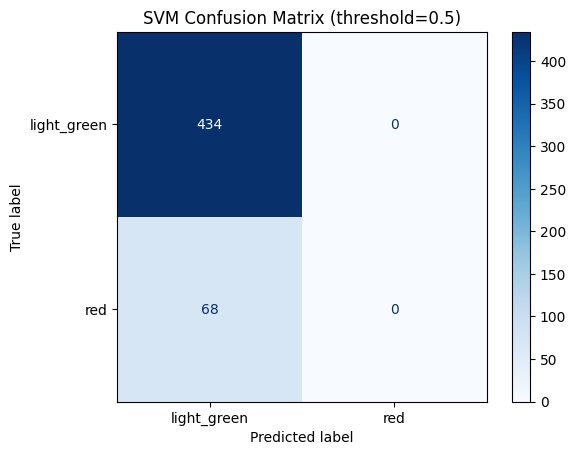


--- 11.2 Threshold Tuning Analysis ---


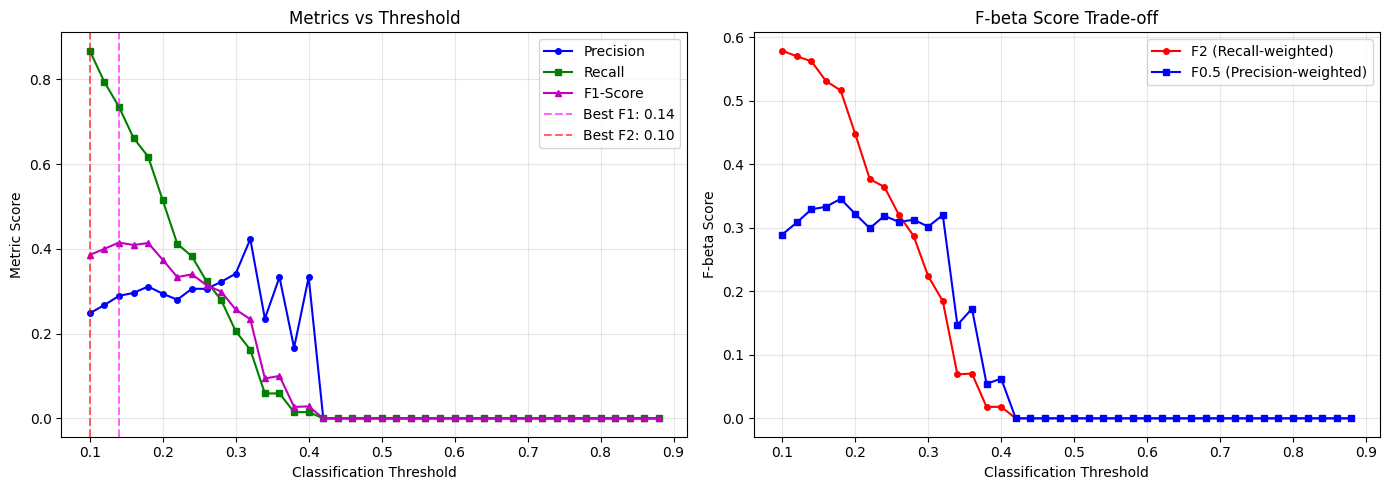


Optimal thresholds:
  Best F1:  0.14 (F1=0.4149)
  Best F2:  0.10 (F2=0.5784) → Prioritize catching red points
  Best F0.5:0.18 (F0.5=0.3454) → Prioritize avoiding false alarms

--- 11.3 Precision-Recall vs ROC Curve ---


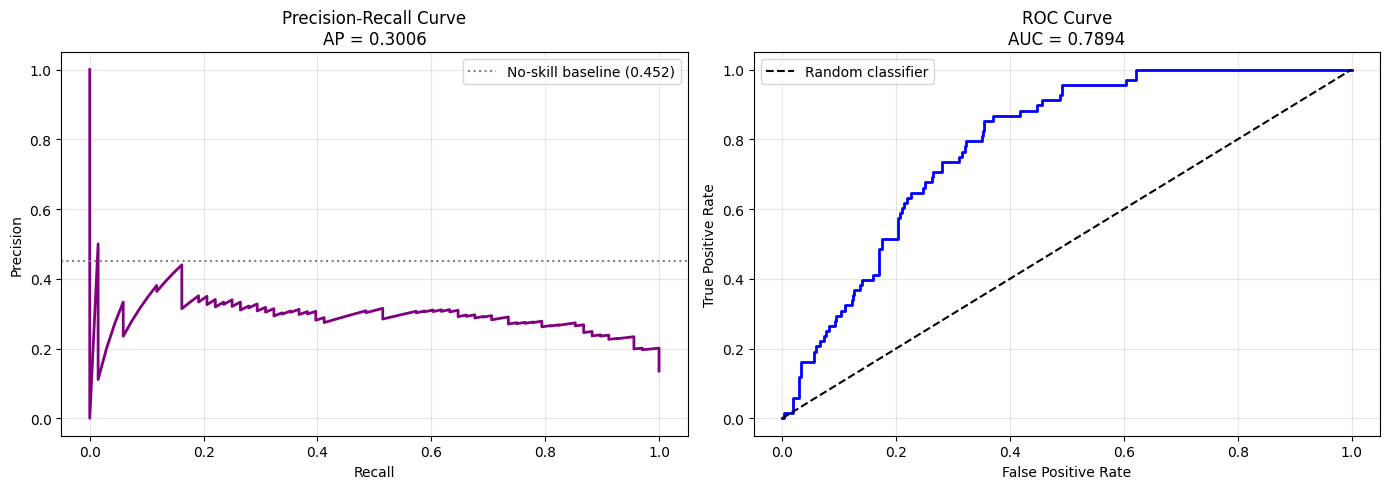


📊 Key Insight from Habr Article:
  • AP (Average Precision) = 0.3006 is the TRUE measure for imbalanced data
  • AUC-ROC = 0.7894 can be misleadingly optimistic when red points are rare
  • Always optimize threshold using PR curve, not ROC!

--- 11.4 Cost-Based Threshold Optimization ---
Cost configuration: FN=10.0, FP=1.0


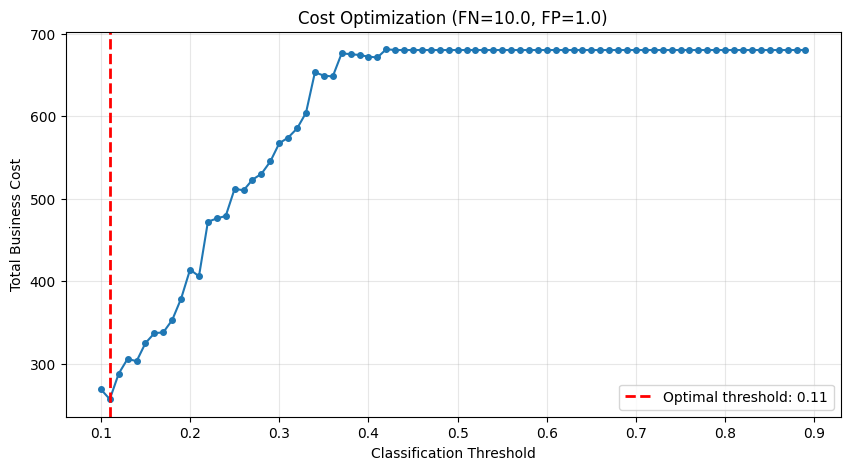


✅ Cost-optimized threshold: 0.11
   Expected total cost: 257.00 units
   False Positives: 157
   False Negatives: 10

--- 11.5 Final SVM Performance (Cost-Optimized) ---

SVM Final Results (threshold=0.11):
              precision    recall  f1-score   support

 light_green       0.97      0.64      0.77       434
         red       0.27      0.85      0.41        68

    accuracy                           0.67       502
   macro avg       0.62      0.75      0.59       502
weighted avg       0.87      0.67      0.72       502



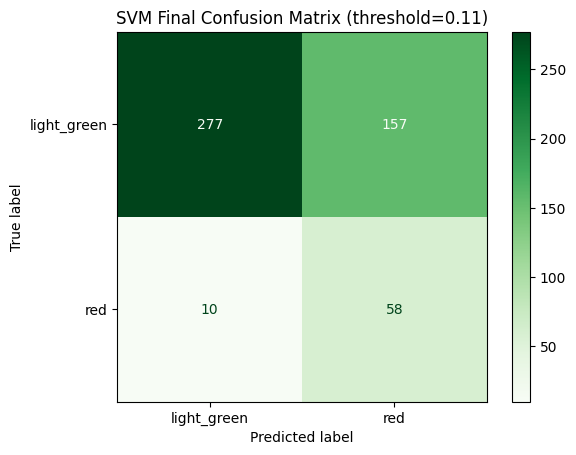


--- 11.6 Stratified Cross-Validation ---
5-Fold CV F1 Scores: [0.3593 0.398  0.3786 0.369  0.375 ]
Mean F1: 0.3760 ± 0.0128
Mean Accuracy: 0.6477 ± 0.0304 ⚠️ (misleading for imbalanced data!)

--- 11.7 Production Deployment Function ---

🔍 Sample Predictions (threshold=0.11):
      X       Y   True   Pred   P(red) Status
----------------------------------------------------
 1726.0   818.0  green  green    0.031 ✓
 1275.0  1276.0  green  green    0.030 ✓
 1182.0  1189.0  green  green    0.030 ✓
 1343.0  1116.0  green  green    0.030 ✓
  764.0   729.0  green  green    0.030 ✓
 1577.0   657.0  green  green    0.031 ✓
 1187.0  1676.0  green  green    0.030 ✓
 1902.0  1175.0  green  green    0.031 ✓


In [26]:
"""
=================================================================
SECTION 11: SUPPORT VECTOR MACHINE (SVM) CLASSIFIER
Based on: https://habr.com/ru/companies/otus/articles/1034692/
Key ideas applied:
- SVM with RBF kernel handles non-linear spatial boundaries naturally
- class_weight='balanced' automatically penalizes mistakes on rare class
- Probability calibration enables meaningful threshold tuning
- Precision-Recall analysis > ROC-AUC for imbalanced spatial data
- Cost-based threshold selection aligns model with business impact
=================================================================
"""
print("\n" + "="*70)
print("SECTION 11: SVM CLASSIFIER WITH PROPER METRICS FOR IMBALANCED DATA")
print("="*70)

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             fbeta_score, classification_report,
                             precision_recall_curve, average_precision_score,
                             roc_auc_score, roc_curve)
from sklearn.calibration import CalibratedClassifierCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =================================================================
# 11.0 Check imbalance & stratified split
# =================================================================
n_green = np.sum(y_true == 0)
n_red = np.sum(y_true == 1)
total = len(y_true)
print(f"\nClass distribution:")
print(f"  Green (class 0): {n_green} ({100*n_green/total:.2f}%)")
print(f"  Red (class 1):   {n_red} ({100*n_red/total:.2f}%)")
print(f"  Imbalance ratio: {max(n_green, n_red)/min(n_green, n_red):.2f}:1")

# Stratified split preserves the red/green ratio in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_true,
    test_size=0.3,
    stratify=y_true,  # CRITICAL for imbalanced data
    random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

# =================================================================
# 11.1 Train SVM with class_weight='balanced' & probability calibration
# =================================================================
print("\n--- 11.1 SVM Training & Baseline Evaluation ---")

# RBF kernel works well for spatial boundaries; probability=True enables threshold tuning
svm_clf = SVC(
    kernel='rbf',
    class_weight='balanced',  # Automatically weights red points higher
    probability=True,         # Required for predict_proba()
    C=1.0,
    gamma='scale',
    random_state=42
)
svm_clf.fit(X_train, y_train)

# Get probabilities for the test set
y_proba_svm = svm_clf.predict_proba(X_test)[:, 1]
y_pred_svm_default = (y_proba_svm >= 0.5).astype(int)

# Baseline evaluation (threshold=0.5)
print(f"\nSVM Baseline (threshold=0.5):")
print(classification_report(y_test, y_pred_svm_default, target_names=["light_green", "red"]))

# Confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["light_green", "red"])
disp.plot(cmap='Blues')
plt.title('SVM Confusion Matrix (threshold=0.5)')
plt.show()

# =================================================================
# 11.2 Threshold Tuning: F1 & F-beta analysis
# =================================================================
print("\n--- 11.2 Threshold Tuning Analysis ---")

thresholds = np.arange(0.1, 0.9, 0.02)
results = []

for thresh in thresholds:
    y_pred_t = (y_proba_svm >= thresh).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    f2 = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)  # Prioritize recall
    f05 = fbeta_score(y_test, y_pred_t, beta=0.5, zero_division=0)  # Prioritize precision
    results.append({'threshold': thresh, 'precision': p, 'recall': r, 'f1': f1, 'f2': f2, 'f05': f05})

results_df = pd.DataFrame(results)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(results_df['threshold'], results_df['precision'], 'b-o', label='Precision', markersize=4)
plt.plot(results_df['threshold'], results_df['recall'], 'g-s', label='Recall', markersize=4)
plt.plot(results_df['threshold'], results_df['f1'], 'm-^', label='F1-Score', markersize=4)
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)

# Highlight optimal thresholds
best_f1_t = results_df.loc[results_df['f1'].idxmax(), 'threshold']
best_f2_t = results_df.loc[results_df['f2'].idxmax(), 'threshold']
plt.axvline(best_f1_t, color='magenta', linestyle='--', alpha=0.6, label=f'Best F1: {best_f1_t:.2f}')
plt.axvline(best_f2_t, color='red', linestyle='--', alpha=0.6, label=f'Best F2: {best_f2_t:.2f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(thresholds, results_df['f2'], 'r-o', label='F2 (Recall-weighted)', markersize=4)
plt.plot(thresholds, results_df['f05'], 'b-s', label='F0.5 (Precision-weighted)', markersize=4)
plt.xlabel('Classification Threshold')
plt.ylabel('F-beta Score')
plt.title('F-beta Score Trade-off')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimal thresholds:")
print(f"  Best F1:  {best_f1_t:.2f} (F1={results_df.loc[results_df['f1'].idxmax(), 'f1']:.4f})")
print(f"  Best F2:  {best_f2_t:.2f} (F2={results_df['f2'].max():.4f}) → Prioritize catching red points")
print(f"  Best F0.5:{results_df.loc[results_df['f05'].idxmax(), 'threshold']:.2f} (F0.5={results_df['f05'].max():.4f}) → Prioritize avoiding false alarms")

# =================================================================
# 11.3 Precision-Recall Curve (per Habr article recommendation)
# =================================================================
print("\n--- 11.3 Precision-Recall vs ROC Curve ---")

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba_svm)
ap_score = average_precision_score(y_test, y_proba_svm)

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_svm)
roc_auc = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(14, 5))

# PR Curve (recommended for imbalanced data)
plt.subplot(1, 2, 1)
plt.plot(recall_curve, precision_curve, linewidth=2, color='purple')
plt.axhline(y=n_red/len(y_test), color='gray', linestyle=':', label=f'No-skill baseline ({n_red/len(y_test):.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve\nAP = {ap_score:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

# ROC Curve (for reference only)
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, linewidth=2, color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve\nAUC = {roc_auc:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('svm_pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Key Insight from Habr Article:")
print(f"  • AP (Average Precision) = {ap_score:.4f} is the TRUE measure for imbalanced data")
print(f"  • AUC-ROC = {roc_auc:.4f} can be misleadingly optimistic when red points are rare")
print(f"  • Always optimize threshold using PR curve, not ROC!")

# =================================================================
# 11.4 Cost-Based Threshold Optimization
# =================================================================
print("\n--- 11.4 Cost-Based Threshold Optimization ---")

# Define business costs (customize based on your domain)
COST_FN = 10.0  # Cost of missing a red point (False Negative)
COST_FP = 1.0   # Cost of false alarm on green (False Positive)

print(f"Cost configuration: FN={COST_FN}, FP={COST_FP}")

best_cost = float('inf')
best_thresh_cost = 0.5
cost_history = []

for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_c = (y_proba_svm >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_c)
    tn, fp, fn, tp = cm.ravel()

    total_cost = fn * COST_FN + fp * COST_FP
    cost_history.append({'threshold': thresh, 'total_cost': total_cost, 'fp': fp, 'fn': fn})

    if total_cost < best_cost:
        best_cost = total_cost
        best_thresh_cost = thresh
        best_pred_cost = y_pred_c.copy()

cost_df = pd.DataFrame(cost_history)

plt.figure(figsize=(10, 5))
plt.plot(cost_df['threshold'], cost_df['total_cost'], marker='o', markersize=4)
plt.axvline(best_thresh_cost, color='red', linestyle='--', linewidth=2,
            label=f'Optimal threshold: {best_thresh_cost:.2f}')
plt.xlabel('Classification Threshold')
plt.ylabel('Total Business Cost')
plt.title(f'Cost Optimization (FN={COST_FN}, FP={COST_FP})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n✅ Cost-optimized threshold: {best_thresh_cost:.2f}")
print(f"   Expected total cost: {best_cost:.2f} units")
print(f"   False Positives: {confusion_matrix(y_test, best_pred_cost).ravel()[1]}")
print(f"   False Negatives: {confusion_matrix(y_test, best_pred_cost).ravel()[2]}")

# =================================================================
# 11.5 Final Evaluation with Optimal Threshold
# =================================================================
print("\n--- 11.5 Final SVM Performance (Cost-Optimized) ---")

print(f"\nSVM Final Results (threshold={best_thresh_cost:.2f}):")
print(classification_report(y_test, best_pred_cost, target_names=["light_green", "red"]))

cm_final = confusion_matrix(y_test, best_pred_cost)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["light_green", "red"])
disp.plot(cmap='Greens')
plt.title(f'SVM Final Confusion Matrix (threshold={best_thresh_cost:.2f})')
plt.show()

# =================================================================
# 11.6 Stratified Cross-Validation for Robustness
# =================================================================
print("\n--- 11.6 Stratified Cross-Validation ---")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use F1 scoring (NOT accuracy!)
cv_f1 = cross_val_score(SVC(class_weight='balanced', probability=True, random_state=42),
                        X_scaled, y_true, cv=cv, scoring='f1')
print(f"5-Fold CV F1 Scores: {cv_f1.round(4)}")
print(f"Mean F1: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# Show why accuracy is misleading
cv_acc = cross_val_score(SVC(class_weight='balanced', probability=True, random_state=42),
                         X_scaled, y_true, cv=cv, scoring='accuracy')
print(f"Mean Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f} ⚠️ (misleading for imbalanced data!)")

# =================================================================
# 11.7 Deployment-Ready Prediction Function
# =================================================================
print("\n--- 11.7 Production Deployment Function ---")

def predict_red_green_svm(X_new, model=svm_clf, threshold=best_thresh_cost, scaler=scaler):
    """
    Predict class for new X,Y coordinates using cost-optimized SVM.

    Parameters:
    -----------
    X_new : array-like, shape (n_samples, 2)
    model : trained SVC with probability=True
    threshold : float, optimal decision threshold
    scaler : fitted StandardScaler

    Returns:
    --------
    predictions : array of 0 (green) or 1 (red)
    probabilities : array of red class probabilities
    """
    X_new_scaled = scaler.transform(X_new)
    proba = model.predict_proba(X_new_scaled)[:, 1]
    predictions = (proba >= threshold).astype(int)
    return predictions, proba

# Example usage on test sample
sample_idx = np.random.choice(len(X_test), 8, replace=False)
X_sample = X_test[sample_idx]
preds, probas = predict_red_green_svm(X_sample)

print(f"\n🔍 Sample Predictions (threshold={best_thresh_cost:.2f}):")
print(f"{'X':>7} {'Y':>7} {'True':>6} {'Pred':>6} {'P(red)':>8} {'Status'}")
print("-" * 52)
for i, (x, y, true, pred, prob) in enumerate(zip(X_sample[:,0], X_sample[:,1],
                                                  y_test[sample_idx], preds, probas)):
    x_orig = x * scaler.scale_[0] + scaler.mean_[0]
    y_orig = y * scaler.scale_[1] + scaler.mean_[1]
    true_lbl = "green" if true == 0 else "red"
    pred_lbl = "green" if pred == 0 else "red"
    status = "✓" if true == pred else "✗"
    print(f"{x_orig:7.1f} {y_orig:7.1f} {true_lbl:>6} {pred_lbl:>6} {prob:8.3f} {status}")

# =================================================================
# 11.8 Summary: Key Takeaways (Aligned with Habr Article)
# =================================================================
final_f1 = f1_score(y_test, best_pred_cost, zero_division=0)
final_ap = ap_score
opt_thresh = best_thresh_cost